# Exploited Vulnerabilities in a Software Ecosystem

A compartment model of vulnerability flow from discovery through exploitation to removal, in **days**, with
parameters measured from NVD, CISA KEV and MITRE for two populations: the global software ecosystem and
Microsoft SharePoint as an instance of enterprise server software.

The notebook proceeds in three parts, matching `ODEtoVuln_daily.md`: the system and its calibration (cells
below), the data those parameters come from, and twelve visualizations, each establishing one result. Figures
are ordered by the weight of the conclusion they carry rather than by derivation order. Each section closes
with a justification of the parameters that figure uses.

In [1]:
import datetime as dt
import json
from dataclasses import dataclass, fields, replace
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq, curve_fit

%config InlineBackend.figure_formats = ['retina']

DERIVED = json.loads(Path("data/derived_params.json").read_text())
HISTORY = json.loads(Path("data/global_history.json").read_text())
SHAREPOINT_CVES = json.loads(Path("data/sharepoint_union.json").read_text())["vulnerabilities"]
MEAS = DERIVED["measured"]

# Every date-pinned quantity below derives from the parameter file's own snapshot, so the
# notebook cannot silently disagree with the data it was built from.
SNAPSHOT_DATE = dt.date.fromisoformat(DERIVED["as_of"])
SNAPSHOT_DOY = SNAPSHOT_DATE.timetuple().tm_yday

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SURFACE, INK, SECONDARY, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
ORD_BLUE = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10, "text.color": INK,
    "axes.labelcolor": SECONDARY, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": SECONDARY, "ytick.labelcolor": SECONDARY,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.titlelocation": "left", "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlepad": 8, "lines.linewidth": 2.0, "legend.frameon": False, "figure.dpi": 120,
})
DAYS_PER_YEAR = 365.25


def label_end(ax, x, y, text, color, dy=0):
    ax.annotate(text, xy=(x, y), xytext=(6, dy), textcoords="offset points", va="center",
                ha="left", fontsize=9, color=color, fontweight="bold", annotation_clip=False)


def headline(fig, title, subtitle, y=0.995, y2=None):
    fig.text(0.005, y, title, ha="left", va="top", fontsize=13, fontweight="bold", color=INK)
    fig.text(0.005, y2 if y2 else y - 0.042, subtitle, ha="left", va="top", fontsize=9,
             color=SECONDARY, linespacing=1.5)


# ---- sourced constants (provenance in ODEtoVuln_daily.md) -----------------------------
EVER_PATCHED = 0.26          # Verizon 2026 DBIR: share of known-exploited flaws ever fully patched
# f routes influx to the remediable compartment, from which a small share still exits by
# decommissioning rather than patching. f is calibrated below so the REALIZED ever-patched share
# equals EVER_PATCHED; using 0.26 directly would realize only 0.244.
TAU_DAYS = 43.0              # Verizon 2026 DBIR: median days to fix known-exploited
ZERO_DAY_SHARE = 0.42        # CrowdStrike 2026: exploited before disclosure
NDAY_FAST_SHARE = 0.28       # exploited within one day of disclosure
SATURATION = 2.0             # supply / throughput ratio today (implies C from realized rate)
V1_ESTIMATE = 45.4           # uncorrected daily edition, global


@dataclass(frozen=True)
class Eco:
    """Per-day parameters for one ecosystem, corrected five-stock structure."""

    label: str
    gamma: float             # measured publication rate
    realized: float          # measured exploitation influx (KEV)
    zero_day: float          # share exploited by publication day
    phi: float               # retirement of the known backlog
    lam: float               # decommissioning of exploited software
    corpus: int              # observed CVE count, for the backlog check
    disclose: float = 1 / 45
    mu: float = 1 / 30
    tau: float = TAU_DAYS
    rho: float = 0.20
    delta: float = 0.003
    f_fix: float = 0.0       # set by calibrate() from EVER_PATCHED

    @property
    def patch_rate(self):
        return self.delta + self.rho / (1 + self.tau)

    @property
    def C(self):
        """Throughput calibrated so realized = C·P/(C+P) at today's supply."""
        return self.realized * (SATURATION + 1) / SATURATION

    @property
    def supply0(self):
        return SATURATION * self.C

    # Hazards are frozen at calibration. If they were recomputed from the current gamma/phi,
    # perturbing those parameters would rescale the hazards with them and the elasticities of
    # discovery and retirement would be identically zero.
    b_h: float = 0.0
    b_n: float = 0.0
    b_x: float = 0.0

    def calibrate(self):
        """Hazards reproducing the measured supply split, and f reproducing EVER_PATCHED."""
        H, N, X = self.gamma / self.disclose, self.gamma / self.mu, self.gamma / self.phi
        slow = 1 - self.zero_day - NDAY_FAST_SHARE * (1 - self.zero_day)
        patched_share = self.patch_rate / (self.patch_rate + self.lam)
        return replace(self, f_fix=EVER_PATCHED / patched_share,
                       b_h=self.zero_day * self.supply0 / H,
                       b_n=NDAY_FAST_SHARE * (1 - self.zero_day) * self.supply0 / N,
                       b_x=slow * self.supply0 / X)

    @property
    def hazards(self):
        return self.b_h, self.b_n, self.b_x

    def fixed_point(self, gmult=1.0, wmult=1.0, cmult=1.0, f_fix=None, lam=None, tau=None,
                    eps=1.0, phi=None, iters=200, tol=1e-14):
        """Solved self-consistently: the share of weaponizable supply attackers convert,
        conv = I/P, is also the share that actually leaves the vulnerability pools. Opportunities
        attackers do not convert stay where they are, so vulnerabilities are conserved."""
        f = self.f_fix if f_fix is None else f_fix
        lm = self.lam if lam is None else lam
        pr = (self.delta + self.rho / (1 + (self.tau if tau is None else tau)))
        ph = self.phi if phi is None else phi
        b_h, b_n, b_x = (b * eps * wmult for b in self.hazards)
        C = self.C * cmult
        conv = 1.0
        for _ in range(iters):
            H = self.gamma * gmult / (self.disclose + conv * b_h)
            N = self.disclose * H / (self.mu + conv * b_n)
            X = self.mu * N / (ph + conv * b_x)
            P = b_h * H + b_n * N + b_x * X
            I = C * P / (C + P)
            nxt = I / P
            if abs(nxt - conv) < tol:
                conv = nxt
                break
            conv = nxt
        Ep = f * I / (pr + lm)
        Er = (1 - f) * I / lm
        return {"H": H, "N": N, "X": X, "supply": P, "influx": I, "converted": conv,
                "Ep": Ep, "Er": Er, "E": Ep + Er}

    def rhs(self, t, y, gamma_fn=None, wmult=1.0, cmult=1.0):
        H, N, X, Ep, Er = y
        b_h, b_n, b_x = (b * wmult for b in self.hazards)
        g = self.gamma if gamma_fn is None else gamma_fn(t)
        P = b_h * H + b_n * N + b_x * X            # gross weaponizable opportunity rate
        C = self.C * cmult
        I = C * P / (C + P) if P > 0 else 0.0      # realized, capped by throughput
        conv = I / P if P > 0 else 0.0             # unconverted opportunities stay in their pools
        return [g - self.disclose * H - conv * b_h * H,
                self.disclose * H - self.mu * N - conv * b_n * N,
                self.mu * N - self.phi * X - conv * b_x * X,
                self.f_fix * I - (self.patch_rate + self.lam) * Ep,
                (1 - self.f_fix) * I - self.lam * Er]

    def integrate(self, t_end, y0=None, n=4000, gamma_fn=None, wmult=1.0, cmult=1.0):
        y0 = [0.0] * 5 if y0 is None else list(y0)
        te = np.linspace(0.0, t_end, n)
        sol = solve_ivp(self.rhs, (0.0, t_end), y0, args=(gamma_fn, wmult, cmult), t_eval=te,
                        method="LSODA", rtol=1e-9, atol=1e-9, max_step=t_end / 250)
        return sol.t, dict(zip(("H", "N", "X", "Ep", "Er"), sol.y))


GLOBAL = Eco(label="global ecosystem", gamma=MEAS["cve_per_day_364"],
             realized=MEAS["kev_influx_per_day"],
             zero_day=ZERO_DAY_SHARE, phi=1 / 1825, lam=1 / 2000,
             corpus=MEAS["corpus_total"]).calibrate()
# SharePoint's decommissioning horizon is set to the global 5.5 yr rather than its 10-yr
# support horizon: at 1/3650 the model returns E* = 30 against a KEV-derived anchor of 15, and
# the anchor is the tighter constraint. The 10-yr figure governs patch availability (phi).
SHAREPOINT = Eco(label="Microsoft SharePoint", gamma=MEAS["sharepoint_per_day_1095"],
                 realized=MEAS["sharepoint_kev"] / (5 * 365), zero_day=3 / 20,
                 phi=1 / 3650, lam=1 / 1825, corpus=MEAS["sharepoint_cves"]).calibrate()
ECOS = [GLOBAL, SHAREPOINT]
# ---- KEV-derived anchors, on the model's own accounting --------------------------------
# The naive anchor, KEV size x (1 - ever-patched), applies the COMPLETED limit for patching and
# the ZERO limit for decommissioning at the same instant. KEV opened 2021-11-03 and was
# backfilled to 2002, so by publication date 43% of its entries are older than one E_r
# residence time and the model has already decommissioned them. The kernel anchor runs the
# observed onset history through the exit kernel E integrates,
#     implied = SUM_i [ f exp(-(pr+lam) a_i) + (1-f) exp(-lam a_i) ]
# so both sides count over the same window. Onset is not observed: it is bracketed by NVD
# publication (earliest, so most decay) and CISA's dateAdded (latest, so least decay), with the
# measured median disclosure->KEV lag as the middle case.
KEV_ADDED = {e["cveID"]: dt.date.fromisoformat(e["dateAdded"])
             for e in json.loads(Path(f"data/cisa_kev_{SNAPSHOT_DATE}.json").read_text())["vulnerabilities"]}
KEV_PUB = {r["cve"]["id"]: dt.date.fromisoformat(r["cve"]["published"][:10]) for r in
           json.loads(Path(f"data/nvd_kev_{SNAPSHOT_DATE}.json").read_text())["vulnerabilities"]}
SP_IDS = {v["cve"]["id"] for v in SHAREPOINT_CVES}


def onset_ages(ids, proxy="mid"):
    """Days from exploitation onset to the snapshot, for each KEV entry in `ids`."""
    out = []
    for cid in ids:
        added, pub = KEV_ADDED[cid], KEV_PUB.get(cid)
        if pub is None:
            continue
        onset = {"added": added, "published": pub,
                 "mid": min(added, pub + dt.timedelta(days=MEAS["kev_lag_median_days"]))}[proxy]
        out.append((SNAPSHOT_DATE - onset).days)
    return np.array(out, dtype=float)


def kernel_anchor(eco, ids, proxy="mid"):
    """Standing stock the observed onsets imply under the model's own exit kernel."""
    a = onset_ages(ids, proxy)
    return float(np.sum(eco.f_fix * np.exp(-(eco.patch_rate + eco.lam) * a)
                        + (1 - eco.f_fix) * np.exp(-eco.lam * a)))


KEV_IDS = {GLOBAL.label: list(KEV_ADDED),
           SHAREPOINT.label: [c for c in KEV_ADDED if c in SP_IDS]}
ANCHOR_NAIVE = {GLOBAL.label: MEAS["kev_entries"] * (1 - EVER_PATCHED),
                SHAREPOINT.label: MEAS["sharepoint_kev"] * (1 - EVER_PATCHED)}
ANCHOR = {e.label: kernel_anchor(e, KEV_IDS[e.label]) for e in ECOS}
ANCHOR_BRACKET = {e.label: (kernel_anchor(e, KEV_IDS[e.label], "published"),
                            kernel_anchor(e, KEV_IDS[e.label], "added")) for e in ECOS}
for _e in ECOS:
    _lo, _hi = ANCHOR_BRACKET[_e.label]
    print(f"{_e.label:<22} KEV entries {len(KEV_IDS[_e.label]):>5,}   "
          f"naive anchor {ANCHOR_NAIVE[_e.label]:>8,.1f}   "
          f"kernel anchor {ANCHOR[_e.label]:>8,.1f}  [{_lo:,.1f}, {_hi:,.1f}]")

print(f"{'':<22}{'gamma/day':>10}{'realized':>10}{'C':>8}{'conv':>7}{'f':>7}{'E*':>10}"
      f"{'anchor':>9}{'ratio':>7}{'backlog X*':>12}{'observed':>10}")
for e in ECOS:
    fp = e.fixed_point()
    print(f"{e.label:<22}{e.gamma:>10.3f}{e.realized:>10.4f}{e.C:>8.3f}{fp['converted']:>7.2f}"
          f"{e.f_fix:>7.3f}{fp['E']:>10,.1f}{ANCHOR[e.label]:>9,.0f}"
          f"{fp['E'] / ANCHOR[e.label]:>7.2f}{fp['X']:>12,.0f}{e.corpus:>10,}")
    y = [fp[k] for k in ("H", "N", "X", "Ep", "Er")]
    r = e.rhs(0.0, y)
    # every vulnerability leaves either by retirement from the backlog or through the
    # exploited compartments; I is the flow into E, so it must not be subtracted twice
    inflow_out = (e.gamma - e.phi * fp["X"]
                  - (e.patch_rate + e.lam) * fp["Ep"] - e.lam * fp["Er"])
    print(f"{'':<22}residual max {max(abs(v) for v in r):.2e}   "
          f"gamma - (retired + patched + decommissioned) = {inflow_out:+.2e}")

# ---------------------------------------------------------------------------------------
# Transient state: the equilibria above are targets. Discovery has risen for two decades,
# and states whose residence time is long compared with that rise sit well below target.
# Driving each ecosystem with its measured publication history locates where it is now.
# ---------------------------------------------------------------------------------------
HISTORY_START = 2008
SNAPSHOT_YEAR = SNAPSHOT_DATE.year + SNAPSHOT_DOY / 365.25

_sp_year = {}
for _v in SHAREPOINT_CVES:
    _y = int(_v["cve"]["published"][:4])
    _sp_year[_y] = _sp_year.get(_y, 0) + 1
GLOBAL_RATE = {int(y): HISTORY[y]["total"] / HISTORY[y]["days"] for y in HISTORY}
SP_RATE = {y: _sp_year.get(y, 0) / (365.25 if y < SNAPSHOT_DATE.year else SNAPSHOT_DOY)
           for y in range(HISTORY_START, SNAPSHOT_DATE.year + 1)}
ANNUAL_RATE = {GLOBAL.label: GLOBAL_RATE, SHAREPOINT.label: SP_RATE}


def history_gamma(eco):
    """Measured publication rate as a function of days since HISTORY_START."""
    table = ANNUAL_RATE[eco.label]
    years = sorted(table)

    def gamma(t):
        y = HISTORY_START + t / 365.25
        if y <= years[0]:
            return table[years[0]]
        if y >= years[-1]:
            return table[years[-1]]
        lo = int(np.floor(y))
        frac = y - lo
        return table.get(lo, table[years[0]]) * (1 - frac) + table.get(lo + 1, table[years[-1]]) * frac

    return gamma


def drive_history(eco, n=3000):
    """Integrate from the equilibrium implied by the first year's rate up to the snapshot."""
    table = ANNUAL_RATE[eco.label]
    seed = replace(eco, gamma=max(table[HISTORY_START], 1e-9)).fixed_point()
    T = (SNAPSHOT_YEAR - HISTORY_START) * 365.25
    t, traj = eco.integrate(T, y0=[seed[k] for k in ("H", "N", "X", "Ep", "Er")], n=n,
                            gamma_fn=history_gamma(eco))
    state = {k: traj[k][-1] for k in traj}
    state["E"] = state["Ep"] + state["Er"]
    return {"t": t, "traj": traj, "state": state, "seed": seed, "T": T,
            "year": HISTORY_START + t / 365.25}


TRANSIENT = {e.label: drive_history(e) for e in ECOS}


def from_today(eco, years, gamma_fn=None, wmult=1.0, cmult=1.0, n=2500, **overrides):
    """Evolve from today's history-driven state, optionally with parameters changed."""
    ee = replace(eco, **overrides) if overrides else eco
    y0 = [TRANSIENT[eco.label]["state"][k] for k in ("H", "N", "X", "Ep", "Er")]
    t, traj = ee.integrate(years * DAYS_PER_YEAR, y0=y0, n=n, gamma_fn=gamma_fn,
                           wmult=wmult, cmult=cmult)
    return t, traj, traj["Ep"] + traj["Er"]


HORIZON = 5.0            # years; comparable to the shortest slow timescale, 1/lambda = 5.5 yr

print(f"\n{'':<22}{'state':>6}{'today (driven by':>18}{'target at':>12}{'ratio':>8}")
print(f"{'':<22}{'':>6}{'measured history)':>18}{"today's gamma":>12}")
for e in ECOS:
    tr, eq = TRANSIENT[e.label]["state"], e.fixed_point()
    for k in ("H", "N", "X", "Ep", "Er"):
        print(f"{e.label if k == 'H' else '':<22}{k:>6}{tr[k]:>18,.1f}{eq[k]:>12,.1f}"
              f"{tr[k] / eq[k]:>8.2f}")
    print(f"{'':<22}{'E':>6}{tr['E']:>18,.1f}{eq['E']:>12,.1f}{tr['E'] / eq['E']:>8.2f}"
          f"   anchor {ANCHOR[e.label]:,.0f}: transient {tr['E'] / ANCHOR[e.label]:.2f}, "
          f"target {eq['E'] / ANCHOR[e.label]:.2f}")

# the fast states track their manifolds; the slow ones do not
for e in ECOS:
    d = TRANSIENT[e.label]
    b_h, b_n, b_x = e.hazards
    man_N = e.disclose * d["traj"]["H"] / (e.mu + b_n)
    man_X = e.mu * d["traj"]["N"] / (e.phi + b_x)
    print(f"{e.label:<22} N deviation from its manifold "
          f"{np.min(d['traj']['N'] / man_N - 1):+.1%} to {np.max(d['traj']['N'] / man_N - 1):+.1%}"
          f"   X deviation {np.min(d['traj']['X'] / man_X - 1):+.1%} to "
          f"{np.max(d['traj']['X'] / man_X - 1):+.1%}")

global ecosystem       KEV entries 1,682   naive anchor  1,244.7   kernel anchor    607.2  [572.4, 749.8]
Microsoft SharePoint   KEV entries    21   naive anchor     15.5   kernel anchor     10.1  [9.6, 11.5]
                       gamma/day  realized       C   conv      f        E*   anchor  ratio  backlog X*  observed
global ecosystem         211.981    0.8069   1.210   0.33  0.277   1,193.2      607   1.97     385,394   383,528
                      residual max 2.86e-14   gamma - (retired + patched + decommissioned) = -1.51e-14
Microsoft SharePoint       0.178    0.0115   0.017   0.34  0.279      15.3       10   1.52         609       693
                      residual max 2.19e-17   gamma - (retired + patched + decommissioned) = +2.08e-17

                       state  today (driven by   target at   ratio
                             measured history)today's gamma
global ecosystem           H          10,945.7     9,523.9    1.15
                           N           7,288.4     

## The structure, without numbers

A symbolic view of the five stocks and every flow between them, labelled with the terms as they appear in the
equations. It carries no measured values; it is placed early in `ODEtoVuln_daily.md` to introduce the shape of
the system before any parameter is discussed. The same diagram with measured rates on every arrow is
Visualization 6.

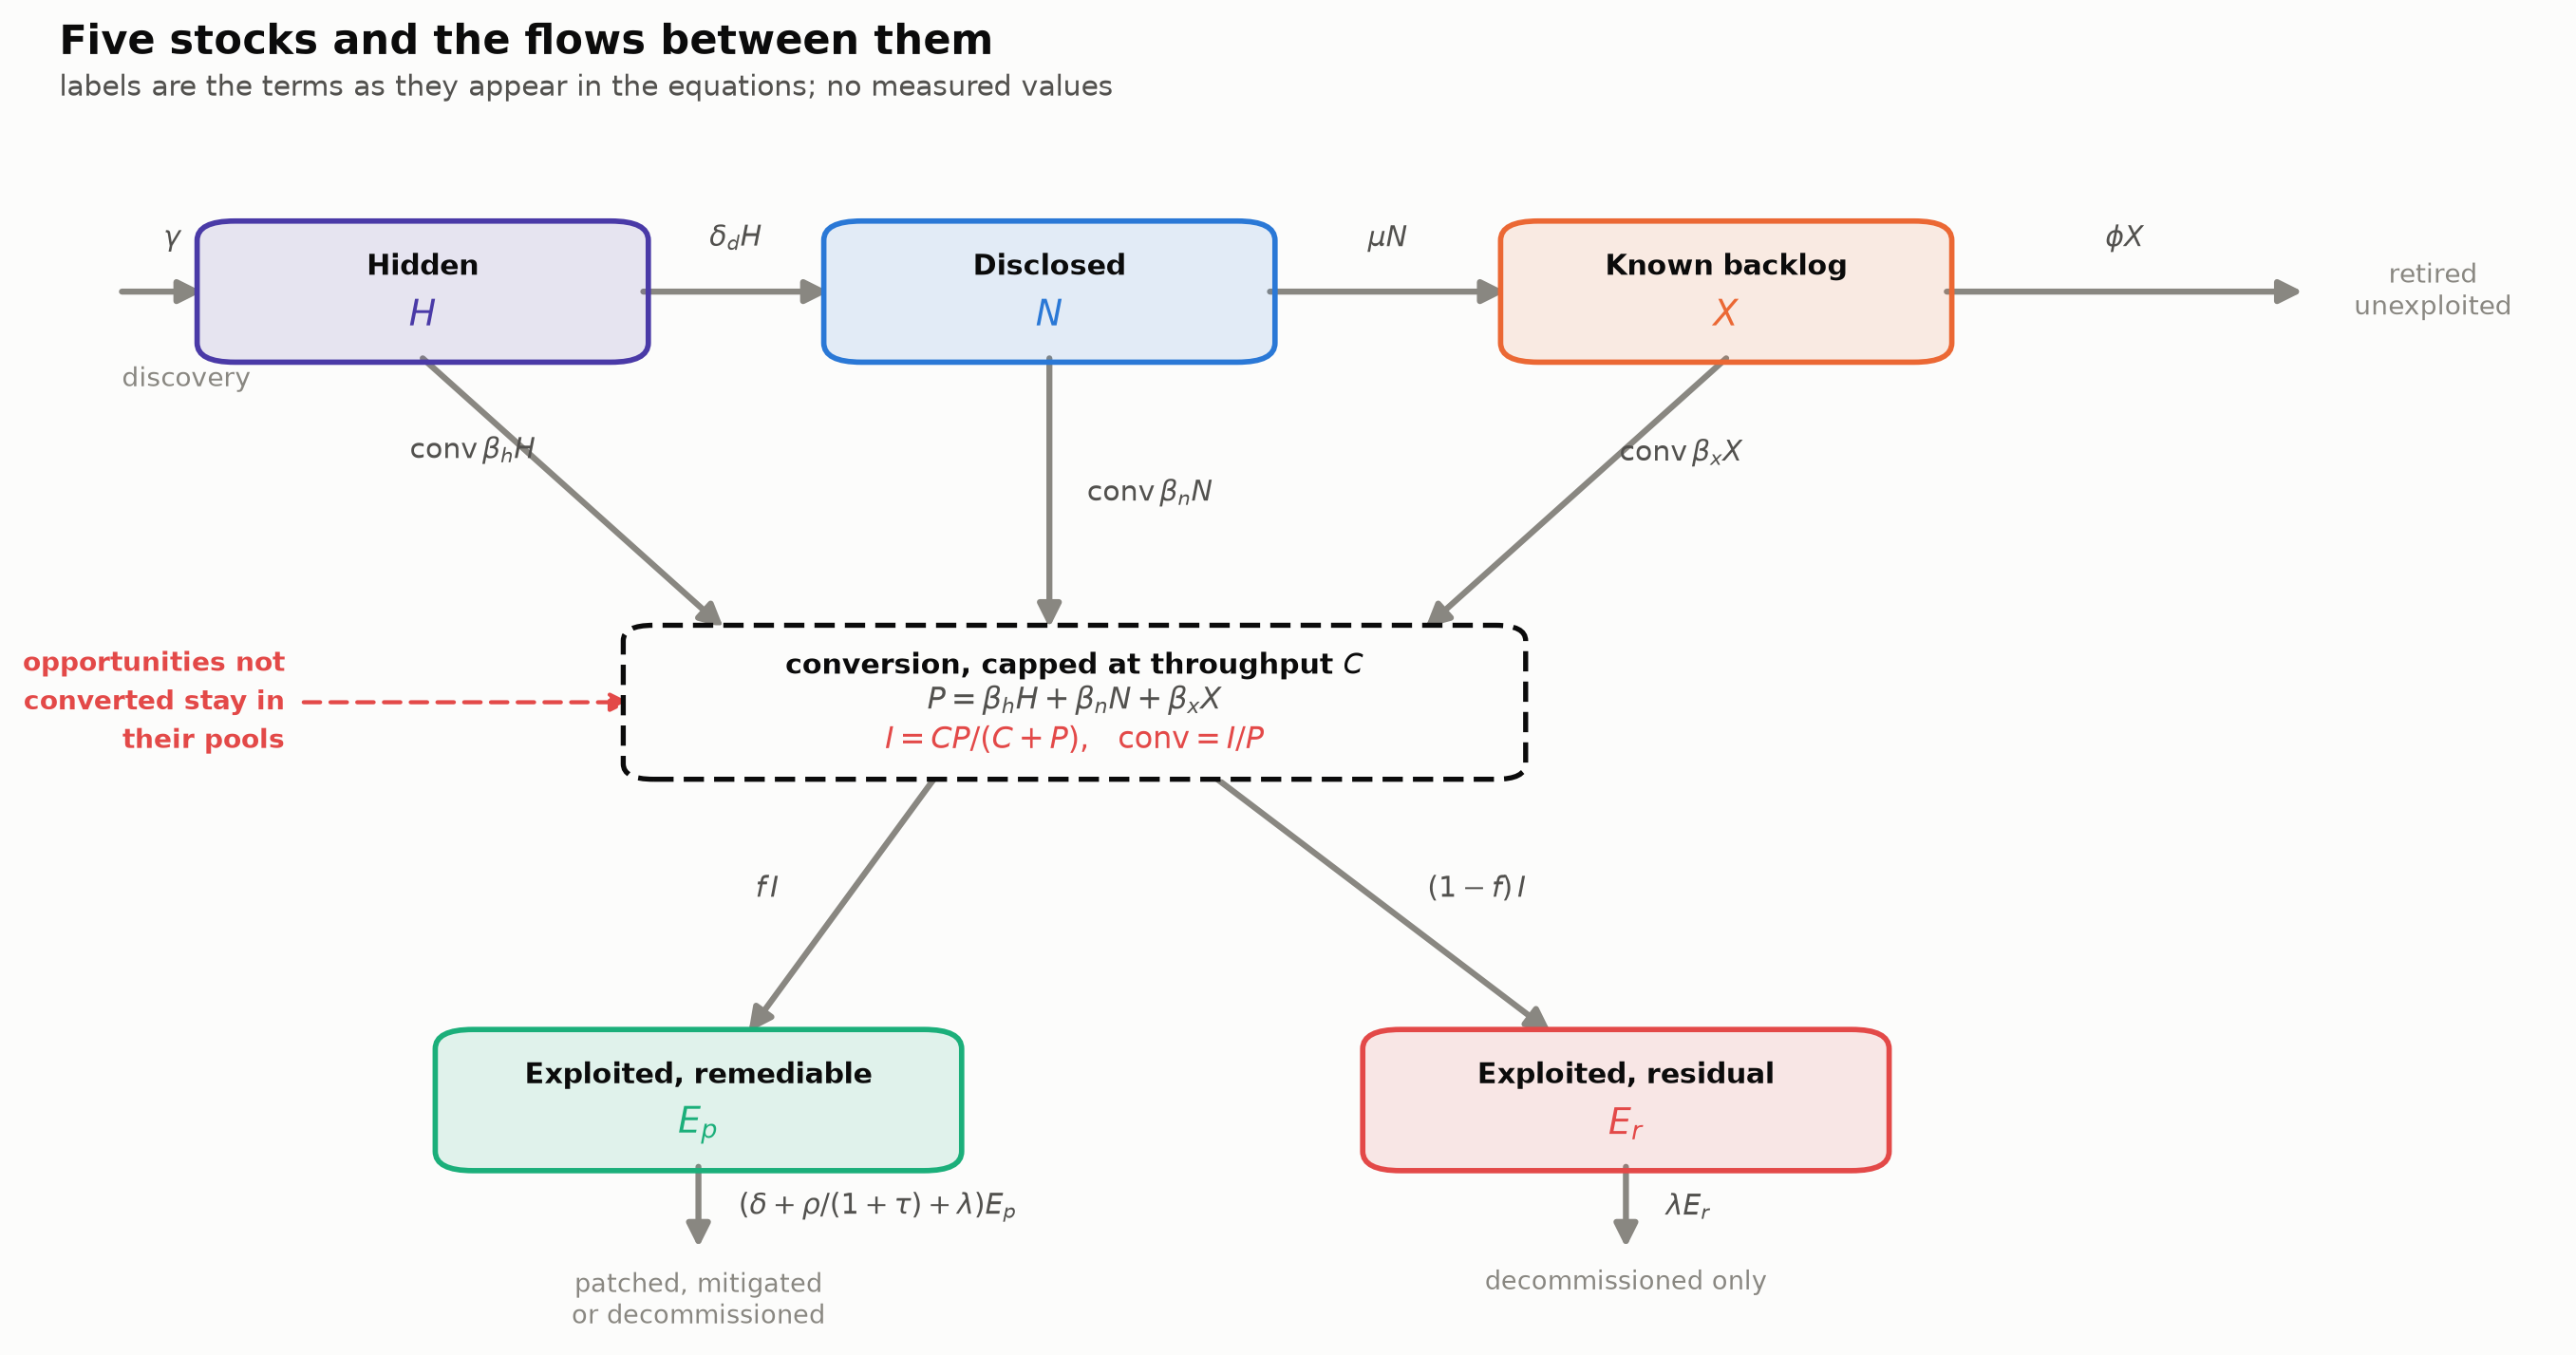

In [2]:
FIGURE_NAME = "structure"        # inlined into ODEtoVuln_daily.md at the "figure:structure" marker
from matplotlib.patches import FancyBboxPatch


def _box(ax, xy, title, sym, color, w=0.17, h=0.10, dashed=False):
    x, y = xy
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                boxstyle="round,pad=0.005,rounding_size=0.015", linewidth=1.7,
                                edgecolor=color, linestyle=(0, (4, 2)) if dashed else "-",
                                facecolor=SURFACE if dashed else mpl.colors.to_rgba(color, 0.12),
                                zorder=3))
    ax.text(x, y + 0.019, title, ha="center", va="center", fontsize=9, fontweight="bold",
            color=INK, zorder=4)
    ax.text(x, y - 0.019, sym, ha="center", va="center", fontsize=11.5, color=color, zorder=4)


def _arrow(ax, a, b, label, off=(0, 0), ha="center", va="bottom", fs=9, color=MUTED, rad=0.0):
    ax.annotate("", xy=b, xytext=a,
                arrowprops=dict(arrowstyle="-|>", lw=1.9, color=color, mutation_scale=15,
                                shrinkA=0, shrinkB=0,
                                connectionstyle=f"arc3,rad={rad}"), zorder=2)
    ax.text((a[0] + b[0]) / 2 + off[0], (a[1] + b[1]) / 2 + off[1], label, ha=ha, va=va,
            fontsize=fs, color=SECONDARY, zorder=5)


fig, ax = plt.subplots(figsize=(11.0, 5.6))
ax.set_xlim(0, 1)
ax.set_ylim(0.05, 0.95)
ax.axis("off")

H, N, X = (0.15, 0.82), (0.40, 0.82), (0.67, 0.82)
JN, EP, ER = (0.41, 0.50), (0.26, 0.19), (0.63, 0.19)
_box(ax, H, "Hidden", "$H$", SERIES[6])
_box(ax, N, "Disclosed", "$N$", SERIES[0])
_box(ax, X, "Known backlog", "$X$", SERIES[1])
_box(ax, EP, "Exploited, remediable", "$E_p$", SERIES[2], w=0.20)
_box(ax, ER, "Exploited, residual", "$E_r$", SERIES[7], w=0.20)

# the conversion step, drawn as a gate rather than a stock
ax.add_patch(FancyBboxPatch((JN[0] - 0.175, JN[1] - 0.055), 0.35, 0.11,
                            boxstyle="round,pad=0.005,rounding_size=0.012", linewidth=1.6,
                            edgecolor=INK, facecolor=SURFACE, linestyle=(0, (4, 2)), zorder=3))
ax.text(JN[0], JN[1] + 0.028, "conversion, capped at throughput $C$", ha="center", va="center",
        fontsize=9, fontweight="bold", color=INK, zorder=4)
ax.text(JN[0], JN[1] + 0.001, r"$P = \beta_h H + \beta_n N + \beta_x X$", ha="center", va="center",
        fontsize=9.5, color=SECONDARY, zorder=4)
ax.text(JN[0], JN[1] - 0.030, r"$I = CP/(C+P)$,   $\mathrm{conv} = I/P$", ha="center", va="center",
        fontsize=9.5, color=SERIES[7], zorder=4)

_arrow(ax, (0.030, 0.82), (0.062, 0.82), r"$\gamma$", (0.004, 0.030))
ax.text(0.030, 0.762, "discovery", ha="left", va="top", fontsize=8.4, color=MUTED)
_arrow(ax, (0.238, 0.82), (0.312, 0.82), r"$\delta_d H$", (0, 0.030))
_arrow(ax, (0.488, 0.82), (0.582, 0.82), r"$\mu N$", (0, 0.030))
_arrow(ax, (0.758, 0.82), (0.900, 0.82), r"$\phi X$", (0, 0.030))
ax.text(0.952, 0.82, "retired\nunexploited", ha="center", va="center", fontsize=8.4, color=MUTED)

_arrow(ax, (0.15, 0.768), (0.27, 0.558), r"$\mathrm{conv}\,\beta_h H$", (-0.040, 0.022), ha="center")
_arrow(ax, (0.40, 0.768), (0.40, 0.558), r"$\mathrm{conv}\,\beta_n N$", (0.015, 0), ha="left",
       va="center")
_arrow(ax, (0.67, 0.768), (0.55, 0.558), r"$\mathrm{conv}\,\beta_x X$", (0.042, 0.020), ha="center")

_arrow(ax, (0.355, 0.443), (0.28, 0.243), r"$f\,I$", (-0.030, 0), ha="center")
_arrow(ax, (0.465, 0.443), (0.60, 0.243), r"$(1-f)\,I$", (0.038, 0), ha="center")
_arrow(ax, (0.26, 0.138), (0.26, 0.075), r"$\left(\delta + \rho/(1+\tau) + \lambda\right) E_p$",
       (0.016, 0), ha="left", va="center")
_arrow(ax, (0.63, 0.138), (0.63, 0.075), r"$\lambda E_r$", (0.016, 0), ha="left", va="center")
ax.text(0.26, 0.058, "patched, mitigated\nor decommissioned", ha="center", va="top", fontsize=8.2,
        color=MUTED)
ax.text(0.63, 0.058, "decommissioned only", ha="center", va="top", fontsize=8.2, color=MUTED)

# the coupling that makes conv appear in the pool equations
ax.annotate("", xy=(0.235, 0.50), xytext=(0.10, 0.50),
            arrowprops=dict(arrowstyle="-|>", lw=1.3, color=SERIES[7], ls=(0, (4, 2.5)),
                            mutation_scale=12), zorder=2)
ax.text(0.095, 0.50, "opportunities not\nconverted stay in\ntheir pools", ha="right", va="center",
        fontsize=8.4, color=SERIES[7], linespacing=1.45, fontweight="bold")

fig.text(0.005, 0.985, "Five stocks and the flows between them",
         ha="left", va="top", fontsize=13, fontweight="bold", color=INK)
fig.text(0.005, 0.945, "labels are the terms as they appear in the equations; no measured values",
         ha="left", va="top", fontsize=9, color=SECONDARY)
fig.subplots_adjust(left=0.0, right=1.0, top=0.905, bottom=0.0)
plt.show()

## Visualization 1 — what sets the level, and a test against unused data

Two independently measured facts determine the standing exploited population: how little exploitation is ever
fully remediated, and how little weaponizable supply is converted. The left panel isolates each by
counterfactual. If every exploited vulnerability were eventually patched, the equilibrium would be **100**. At
the measured 26% ever-patched share with conversion unconstrained, it would be **3,573** — the residual
compartment drains only by decommissioning, on a 5.5-year clock rather than a 124-day one. With the throughput
ceiling applied, it is **1,193**.

Those three figures are **targets**: equilibria the system moves toward. Discovery has risen for two decades,
and compartments whose residence time is measured in years cannot keep up with a rising inflow, so the present
state sits below its target. Driving the model with the measured 2008–2026 publication history puts today's
global exploited population at **704**, about 59% of the 1,193 target; the dashed line marks it.

The right panel tests both readings against the KEV catalogue. The obvious anchor — 1,682 entries, 26% ever
fully patched, so roughly 1,245 unremediated — is not one: it applies the *completed* limit for patching and the
*zero* limit for decommissioning at the same instant. KEV opened 2021-11-03 and was backfilled to 2002, so 43%
of its entries are older by publication date than one residual residence time and the model has already
decommissioned them. Running the catalogue's onset history through the exit kernel $E$ integrates puts both
sides on one clock: **607 [572, 750]** globally, bracketed by the two defensible onset proxies, against today's
**704** — ratio **1.16**, inside the bracket but at its upper end, with the 1,193 target giving 1.97. The
transient is the correct comparison, since the anchor is itself an accumulated quantity. The red tick marks the
1,245 the kernel replaces.

What this does *not* establish is the level: $C$ is calibrated from the recent KEV rate, and 80% of the
corrected anchor comes from onsets after the catalogue opened. The independent content is the onset history's
shape, which runs 0.34, 0.74, 1.17 and 0.80 times the model's realized conversion across 2008–2015, 2016–2020,
2021–2023 and 2024–2026 — the 0.80 being the same 16% overshoot seen as a rate — and the exit kernel, which the
anchor constrains only loosely: it cannot separate $1/\lambda$ = 3 years from 5.5 from 8, though it excludes 12.

**Parameter justification.** The transient path is driven by measured annual publication rates from 2008,
seeded from the equilibrium implied by the 2008 rate; the seed choice matters little because the fast states
re-equilibrate in weeks and the slow ones are dominated by the subsequent two decades of inflow. The measured
inputs are Verizon 2026 DBIR's 26% ever-patched share and its
43-day median delay for the flaws that are patched. Because a small part of the remediable compartment still
exits by decommissioning rather than patching, the routing fraction is calibrated to $f$ = 0.277 so the
realized ever-patched share equals the measured 26%. $1/\lambda$ = 5.5 years follows from a mean open-source
vulnerability age of 2.5+ years with a quarter of codebases carrying decade-old flaws; it is the most
load-bearing assumption in the model and is swept in Visualization 5. The anchors use the KEV catalogue's
onset dates and the ever-patched share.

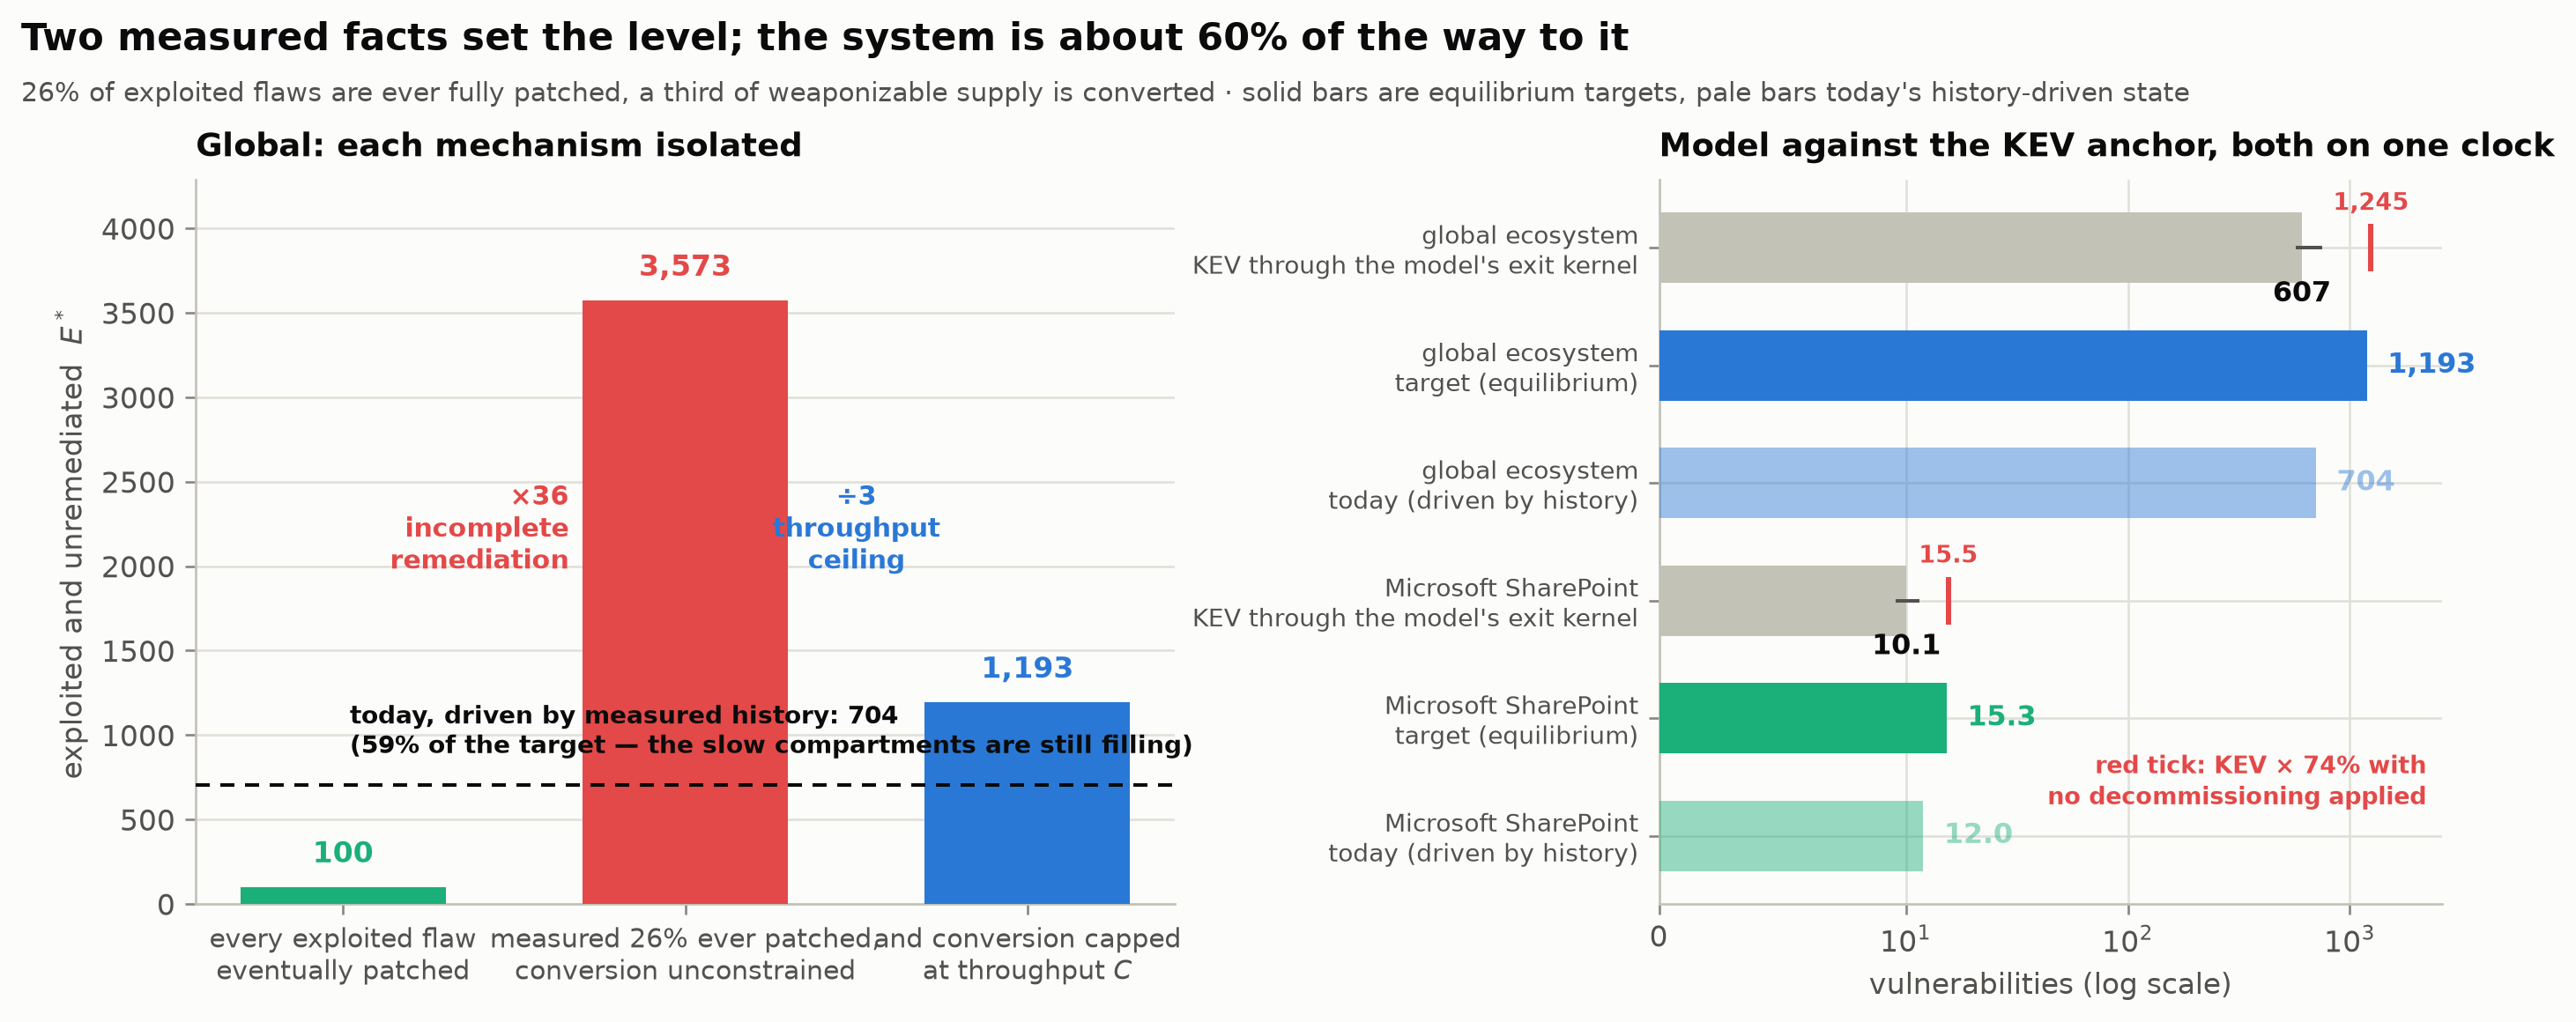

every exploited flaw eventually patched              E* =       100
measured 26% ever patched, conversion unconstrained  E* =     3,573
and conversion capped at throughput $C$              E* =     1,193
global ecosystem       E*   1,193.2  (Ep   27.8 + Er   1,165.5)   anchor     607   ratio 1.97
Microsoft SharePoint   E*      15.3  (Ep    0.4 + Er      14.9)   anchor      10   ratio 1.52
global ecosystem       today    704.5   target  1,193.2     59% of target   anchor ratio: today 1.16, target 1.97   (against the naive anchor, today 0.57)
Microsoft SharePoint   today     12.0   target     15.3     78% of target   anchor ratio: today 1.19, target 1.52   (against the naive anchor, today 0.77)


In [3]:
# Counterfactuals isolating each mechanism, both computed from the same model
FULL_REMEDIATION = replace(GLOBAL, f_fix=1.0).fixed_point()["E"]
uncapped = replace(GLOBAL, realized=1e9).calibrate()          # C -> huge: conversion unconstrained
fp_unc = GLOBAL.fixed_point()
UNCAPPED = (GLOBAL.f_fix * fp_unc["supply"] / (GLOBAL.patch_rate + GLOBAL.lam)
            + (1 - GLOBAL.f_fix) * fp_unc["supply"] / GLOBAL.lam)
MEASURED = GLOBAL.fixed_point()["E"]
steps = [("every exploited flaw\neventually patched", FULL_REMEDIATION, SERIES[2]),
         (f"measured {EVER_PATCHED:.0%} ever patched,\nconversion unconstrained", UNCAPPED, SERIES[7]),
         ("and conversion capped\nat throughput $C$", MEASURED, SERIES[0])]

fig, (ax_w, ax_a) = plt.subplots(1, 2, figsize=(11.8, 5.0), gridspec_kw={"width_ratios": [1.25, 1]})
xs = np.arange(len(steps))
ax_w.bar(xs, [s[1] for s in steps], color=[s[2] for s in steps], width=0.6, zorder=3)
for x, (lab, val, col) in zip(xs, steps):
    ax_w.annotate(f"{val:,.0f}", xy=(x, val), xytext=(0, 6), textcoords="offset points",
                  ha="center", va="bottom", fontsize=10, fontweight="bold", color=col, zorder=4)
ax_w.annotate(f"×{steps[1][1] / steps[0][1]:.0f}\nincomplete\nremediation", xy=(0.66, steps[1][1] * 0.62),
              ha="right", va="center", fontsize=9, color=SERIES[7], fontweight="bold")
ax_w.annotate(f"÷{steps[1][1] / steps[2][1]:.0f}\nthroughput\nceiling", xy=(1.5, steps[1][1] * 0.62),
              ha="center", va="center", fontsize=9, color=SERIES[0], fontweight="bold")
ax_w.set_xticks(xs)
ax_w.set_xticklabels([s[0] for s in steps], fontsize=9)
ax_w.set_ylabel("exploited and unremediated  $E^*$")
ax_w.set_title("Global: each mechanism isolated")
ax_w.set_ylim(0, max(s[1] for s in steps) * 1.2)
today_E = TRANSIENT[GLOBAL.label]["state"]["E"]
ax_w.axhline(today_E, color=INK, lw=1.2, ls=(0, (4, 3)), zorder=5)
ax_w.annotate(f"today, driven by measured history: {today_E:,.0f}\n"
              f"({today_E / MEASURED:.0%} of the target — the slow compartments are still filling)",
              xy=(0.02, today_E), xytext=(0, 8), textcoords="offset points", ha="left", va="bottom",
              fontsize=8.4, color=INK, fontweight="bold", zorder=6)

rows = []
for e in ECOS:
    col = SERIES[0] if e is GLOBAL else SERIES[2]
    lo, hi = ANCHOR_BRACKET[e.label]
    rows += [(f"{e.label}\nKEV through the model's exit kernel", ANCHOR[e.label], BASELINE,
              (ANCHOR[e.label] - lo, hi - ANCHOR[e.label])),
             (f"{e.label}\ntarget (equilibrium)", e.fixed_point()["E"], col, None),
             (f"{e.label}\ntoday (driven by history)", TRANSIENT[e.label]["state"]["E"],
              mpl.colors.to_rgba(col, 0.45), None)]
ys = np.arange(len(rows))[::-1]
# the bracket is the onset proxy: NVD publication at the low end, CISA's dateAdded at the high
err = np.array([[r[3][0] if r[3] else 0.0 for r in rows],
                [r[3][1] if r[3] else 0.0 for r in rows]])
ax_a.barh(ys, [r[1] for r in rows], color=[r[2] for r in rows], height=0.6, zorder=3, xerr=err,
          error_kw=dict(ecolor=SECONDARY, elinewidth=1.2, capsize=0, zorder=6))
for y, (lab, val, col, e_) in zip(ys, rows):
    # anchor rows label below the bar, clear of the bracket whisker and the naive marker
    kw = (dict(xytext=(0, -11), ha="center", va="top", color=INK) if e_ else
          dict(xytext=(7, 0), ha="left", va="center", color=col))
    ax_a.annotate(f"{val:,.1f}" if val < 100 else f"{val:,.0f}", xy=(val, y),
                  textcoords="offset points", fontsize=9.5, fontweight="bold", zorder=8, **kw)
# what the kernel replaces: the same catalogue with no decommissioning applied at all
for y, e in zip((ys[0], ys[3]), ECOS):
    ax_a.plot([ANCHOR_NAIVE[e.label]], [y], marker="|", ms=16, mew=1.8, color=SERIES[7], zorder=7)
for y, e in zip((ys[0], ys[3]), ECOS):
    v = ANCHOR_NAIVE[e.label]
    ax_a.annotate(f"{v:,.1f}" if v < 100 else f"{v:,.0f}", xy=(v, y), xytext=(0, 11),
                  textcoords="offset points", ha="center", va="bottom", fontsize=8.2,
                  color=SERIES[7], fontweight="bold", zorder=7)
# the gloss goes in the empty lower-right of the panel, clear of the bars and the title
ax_a.text(0.98, 0.17, "red tick: KEV × 74% with\nno decommissioning applied",
          transform=ax_a.transAxes, ha="right", va="center", fontsize=8.2, color=SERIES[7],
          fontweight="bold", linespacing=1.4, zorder=7)
ax_a.set_yticks(ys)
ax_a.set_yticklabels([r[0] for r in rows], fontsize=8.5)
ax_a.set_xscale("symlog", linthresh=10)
ax_a.set_xlabel("vulnerabilities (log scale)")
ax_a.set_title("Model against the KEV anchor, both on one clock")
ax_a.set_xlim(0, 2600)          # room for the naive marker right of the bars
ax_a.grid(axis="x")
ax_a.set_axisbelow(True)

headline(fig, "Two measured facts set the level; the system is about 60% of the way to it",
         "26% of exploited flaws are ever fully patched, a third of weaponizable supply is converted · "
         "solid bars are equilibrium targets, pale bars today's history-driven state", y=0.995, y2=0.945)
fig.subplots_adjust(left=0.075, right=0.975, top=0.845, bottom=0.16, wspace=0.55)
plt.show()

for lab, val, _ in steps:
    print(f"{lab.replace(chr(10), ' '):<52} E* = {val:>9,.0f}")
for e in ECOS:
    fp = e.fixed_point()
    print(f"{e.label:<22} E* {fp['E']:>9,.1f}  (Ep {fp['Ep']:>6.1f} + Er {fp['Er']:>9,.1f})   "
          f"anchor {ANCHOR[e.label]:>7,.0f}   ratio {fp['E'] / ANCHOR[e.label]:.2f}")
for e in ECOS:
    tr, eq = TRANSIENT[e.label]["state"]["E"], e.fixed_point()["E"]
    print(f"{e.label:<22} today {tr:>8,.1f}   target {eq:>8,.1f}   {tr / eq:>5.0%} of target   "
          f"anchor ratio: today {tr / ANCHOR[e.label]:.2f}, target {eq / ANCHOR[e.label]:.2f}"
          f"   (against the naive anchor, today {tr / ANCHOR_NAIVE[e.label]:.2f})")

## Visualization 2 — discovery volume against attacker throughput

$E^*$ over a discovery multiplier (x) and an attacker-throughput multiplier (y), with observed operating
points marked. The two axes are the quantities an increase in automated vulnerability research would move.

The contours asymptote to horizontal: past a few multiples of today's discovery rate, $E^*$ depends on
throughput and not on volume. Scaling discovery 10× moves global $E^*$ **+43%**; tripling throughput alone
moves it **+80%**. Microsoft's July 2026 release is the natural experiment — **621 CVEs shipped, 2 under
active exploit** (ZDI), 6.6× its 2025 monthly volume with exploitation flat. That observation is what a capacity-limited
conversion step predicts, and is incompatible with exploitation being proportional to supply.

The measurable consequence: CVE counts track the saturating axis. Throughput — demonstrated by
machine-generated exploits landing under an hour after a patch ships, at costs from a few dollars to a few
thousand per vulnerability — has no published index.

The right panel pairs each scenario's eventual target with the value reached five years from today's
state. Because the system is still climbing toward its present target, a scenario's five-year value combines
that climb with the scenario's own effect, and no scenario delivers more than a fraction of its eventual level
within a planning horizon.

**Parameter justification.** Discovery spans 1–20× (measured 2026 surge 1.56×; Microsoft's own volume 6.6×;
20× exceeds any published projection). Throughput spans 1–10×, bounded above by the observation that per-unit
exploit cost is already low enough that compute is not the constraint; the residual constraint is target
selection and review. $C$ is calibrated so realized exploitation reproduces the measured KEV rate at today's
supply, with supply/$C$ = 2 assumed for both ecosystems — the one free structural ratio, and the reason $C$ is
a floor rather than an estimate.

global ecosystem       10x discovery 1.43x   3x throughput 1.80x   3x both 2.99x   all three 4.29x
Microsoft SharePoint   10x discovery 1.45x   3x throughput 1.74x   3x both 2.90x   all three 4.35x


  today           target   1,193   5-yr     966   54% of the way
  discovery 10×   target   1,706   5-yr   1,292   59% of the way
  throughput 3×   target   2,144   5-yr   1,478   54% of the way
  both            target   4,673   5-yr   2,985   57% of the way


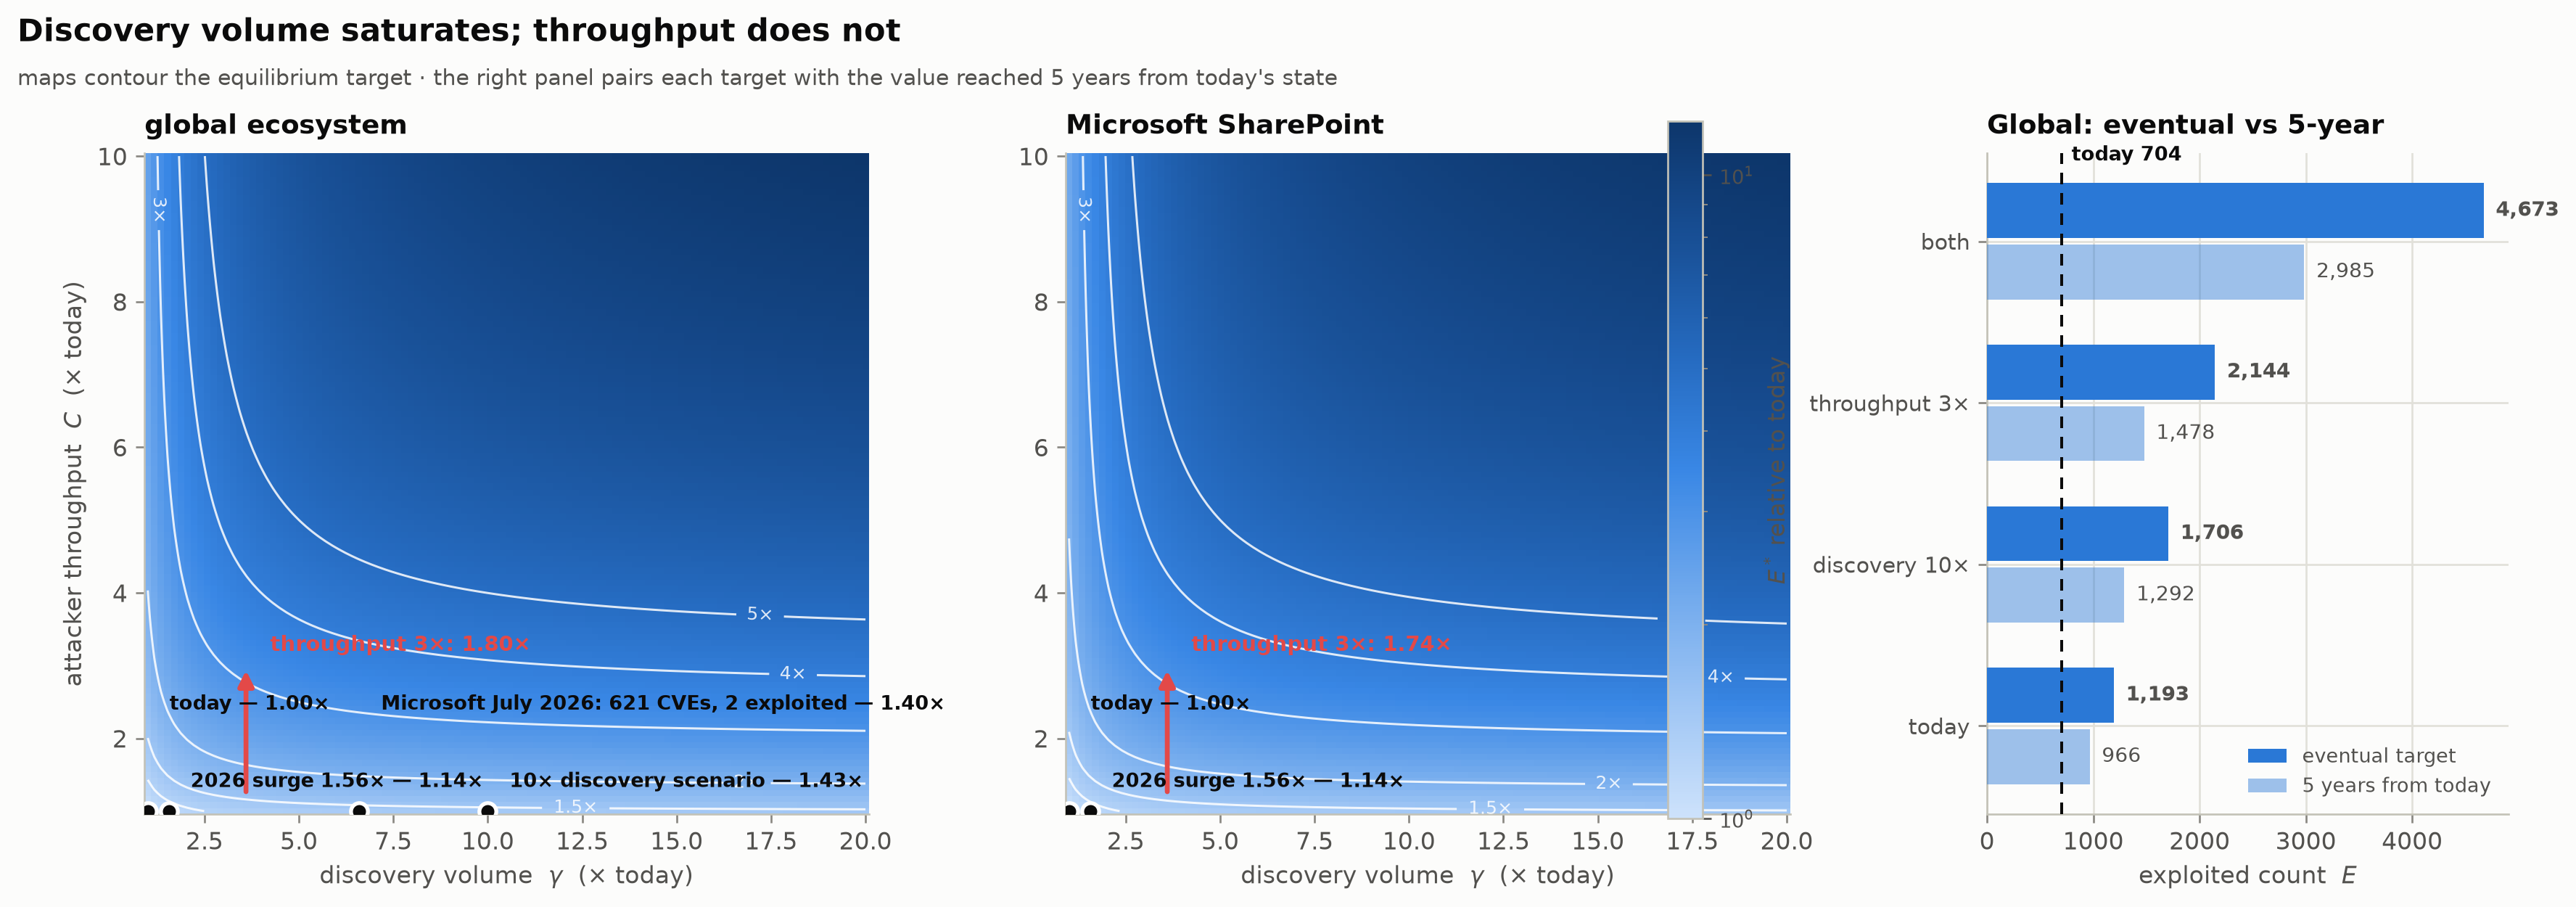

In [4]:
G_GRID, C_GRID = np.linspace(1, 20, 110), np.linspace(1, 10, 110)
GG, CC = np.meshgrid(G_GRID, C_GRID)
cmap = mpl.colors.LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

SURGE_NOW = MEAS["cve_per_day_91"] / MEAS["cve_per_day_364"]

fig, axes = plt.subplots(1, 3, figsize=(14.6, 5.2),
                         gridspec_kw={"width_ratios": [1, 1, 0.72]})
for ax, e in zip(axes[:2], ECOS):
    base = e.fixed_point()["E"]
    field = np.vectorize(lambda g, c: e.fixed_point(gmult=g, cmult=c)["E"])(GG, CC) / base
    mesh = ax.pcolormesh(GG, CC, field, cmap=cmap,
                         norm=mpl.colors.LogNorm(vmin=1, vmax=field.max()), shading="auto")
    cs = ax.contour(GG, CC, field, levels=[1.25, 1.5, 2, 3, 4, 5], colors="white",
                    linewidths=0.9, alpha=0.85)
    ax.clabel(cs, fmt=lambda v: f"{v:g}×", fontsize=7.5, colors="white")
    marks = [("today", 1.0, 1.0, (9, 40)),
             (f"{SNAPSHOT_DATE.year} surge {SURGE_NOW:.2f}×", SURGE_NOW, 1.0, (9, 8))]
    if e is GLOBAL:
        marks += [("Microsoft July 2026: 621 CVEs, 2 exploited", 6.6, 1.0, (9, 40)),
                  ("10× discovery scenario", 10.0, 1.0, (9, 8))]
    for lab, g, c, off in marks:
        ax.plot(g, c, "o", ms=7, color=INK, mec="white", mew=1.6, zorder=5)
        ax.annotate(f"{lab} — {e.fixed_point(gmult=g, cmult=c)['E'] / base:.2f}×", xy=(g, c),
                    xytext=off, textcoords="offset points", ha="left", va="bottom", fontsize=8.2,
                    color=INK, fontweight="bold", zorder=6)
    ax.annotate("", xy=(3.6, 3.0), xytext=(3.6, 1.2),
                arrowprops=dict(arrowstyle="-|>", color=SERIES[7], lw=2.0, mutation_scale=13),
                zorder=5)
    ax.annotate(f"throughput 3×: {e.fixed_point(cmult=3)['E'] / base:.2f}×",
                xy=(3.6, 3.0), xytext=(10, 4), textcoords="offset points", ha="left", va="bottom",
                fontsize=8.6, color=SERIES[7], fontweight="bold", zorder=6)
    ax.set_title(e.label)
    ax.set_xlabel("discovery volume  $\\gamma$  (× today)")
    ax.grid(False)
    print(f"{e.label:<22} 10x discovery {e.fixed_point(gmult=10)['E'] / base:.2f}x   "
          f"3x throughput {e.fixed_point(cmult=3)['E'] / base:.2f}x   "
          f"3x both {e.fixed_point(cmult=3, wmult=3)['E'] / base:.2f}x   "
          f"all three {e.fixed_point(gmult=10, wmult=3, cmult=3)['E'] / base:.2f}x")
axes[0].set_ylabel("attacker throughput  $C$  (× today)")
axes[1].set_ylabel("")

# how much of each scenario's eventual effect arrives within a planning horizon?
ax_h = axes[2]
CASES = [("today", 1.0, 1.0), ("discovery 10×", 10.0, 1.0),
         ("throughput 3×", 1.0, 3.0), ("both", 10.0, 3.0)]
base_now = TRANSIENT[GLOBAL.label]["state"]["E"]
ys = np.arange(len(CASES))
for k, (lab, g, c) in enumerate(CASES):
    tgt = replace(GLOBAL, gamma=GLOBAL.gamma * g).fixed_point(cmult=c)["E"]
    _, _, path = from_today(GLOBAL, HORIZON, cmult=c, gamma=GLOBAL.gamma * g)
    ax_h.barh(k + 0.19, tgt, height=0.34, color=SERIES[0], zorder=3,
              label="eventual target" if k == 0 else None)
    ax_h.barh(k - 0.19, path[-1], height=0.34, color=mpl.colors.to_rgba(SERIES[0], 0.45), zorder=3,
              label=f"{HORIZON:.0f} years from today" if k == 0 else None)
    ax_h.annotate(f"{tgt:,.0f}", xy=(tgt, k + 0.19), xytext=(5, 0), textcoords="offset points",
                  va="center", fontsize=8.4, color=SECONDARY, fontweight="bold")
    ax_h.annotate(f"{path[-1]:,.0f}", xy=(path[-1], k - 0.19), xytext=(5, 0),
                  textcoords="offset points", va="center", fontsize=8.4, color=SECONDARY)
    print(f"  {lab:<15} target {tgt:>7,.0f}   {HORIZON:.0f}-yr {path[-1]:>7,.0f}   "
          f"{(path[-1] - base_now) / (tgt - base_now) if abs(tgt - base_now) > 1e-9 else float('nan'):.0%}"
          f" of the way")
ax_h.axvline(base_now, color=INK, lw=1.2, ls=(0, (4, 3)), zorder=4)
ax_h.annotate(f"today {base_now:,.0f}", xy=(base_now, len(CASES) - 0.5), xytext=(4, 0),
              textcoords="offset points", fontsize=8.2, color=INK, fontweight="bold")
ax_h.set_yticks(ys)
ax_h.set_yticklabels([c[0] for c in CASES], fontsize=9)
ax_h.set_xlabel("exploited count  $E$")
ax_h.set_title("Global: eventual vs 5-year")
ax_h.grid(axis="x")
ax_h.set_axisbelow(True)
ax_h.legend(fontsize=8, labelcolor=SECONDARY, loc="lower right")

cbar = fig.colorbar(mesh, ax=axes[:2], fraction=0.035, pad=0.015)
cbar.set_label("$E^*$ relative to today", fontsize=9.5, color=SECONDARY)
cbar.ax.tick_params(labelsize=8, colors=SECONDARY)
cbar.outline.set_edgecolor(BASELINE)

headline(fig, "Discovery volume saturates; throughput does not",
         "maps contour the equilibrium target · the right panel pairs each target with the value "
         f"reached {HORIZON:.0f} years from today's state", y=0.995, y2=0.945)
fig.subplots_adjust(left=0.055, right=0.985, top=0.845, bottom=0.115, wspace=0.30)
plt.show()

## Visualization 3 — is finite vulnerability supply the binding constraint?

A codebase contains finitely many vulnerabilities, so discovery should in principle deplete a reservoir $U$,
making $\gamma = \psi U$ endogenous rather than a free parameter. That matters because $\gamma$ is the
quantity most often cited in discussions of automated vulnerability research. This figure tests whether the
reservoir binds.

Depletion requires the cumulative discovery curve to decelerate. Measured over 19 years it accelerates:
second differences are positive in every year 2021–2026, and the 2021–2026 growth rate is **+32%/yr**. Fitting
saturating curves to the global cumulative series drives the Gompertz form's **$U$ to 4.3 billion** — four
orders of magnitude past the observed corpus — against the fit's upper bound, where the reported uncertainty
collapses to zero. That zero is the signature of a parameter the data cannot constrain, not of one it pins
down. A logistic returns **1,975,556 ± 691,875**, 35% relative, but only by imposing symmetry, and it is
dominated by the 2017 CNA-expansion step change, which is a bookkeeping artifact rather than a property of
code.

SharePoint shows the failure mode directly: fitting through 2022, 2023 or 2024 yields asymptotes of
**13,720 / 1,828 / 958**. The estimate tracks the recent slope, not a stock. Those fits read the 2022–24 trough
as exhaustion; 2026 then annualizes to **188 CVEs, the highest year on record**.

A rising inflow is also why the model's stocks are below their targets: the annotation gives the backlog
today against the equilibrium this discovery rate implies.

$U$ is therefore retained in the structure, and no result depends on its value. The prediction it supplies is
falsifiable: **per-product discovery must bend where code is not churning**, and mature enterprise products
are where that would appear first. It has not appeared.

**Parameter justification.** Global history is NVD publication counts in 110-day windows, 2008–2026 (2026
partial, through the snapshot, annualized where shown). SharePoint history is the publication dates of the 693
CVEs in its CPE family. Curve fits are unweighted least squares with $U$ bounded below by the observed count;
reported uncertainties are the fit covariance, which understates the real uncertainty because the residuals
are strongly autocorrelated.

global Gompertz  U =   4,323,373,369 +/-               0  (   0% relative)
global logistic  U =       1,975,556 +/-         691,875  (  35% relative)


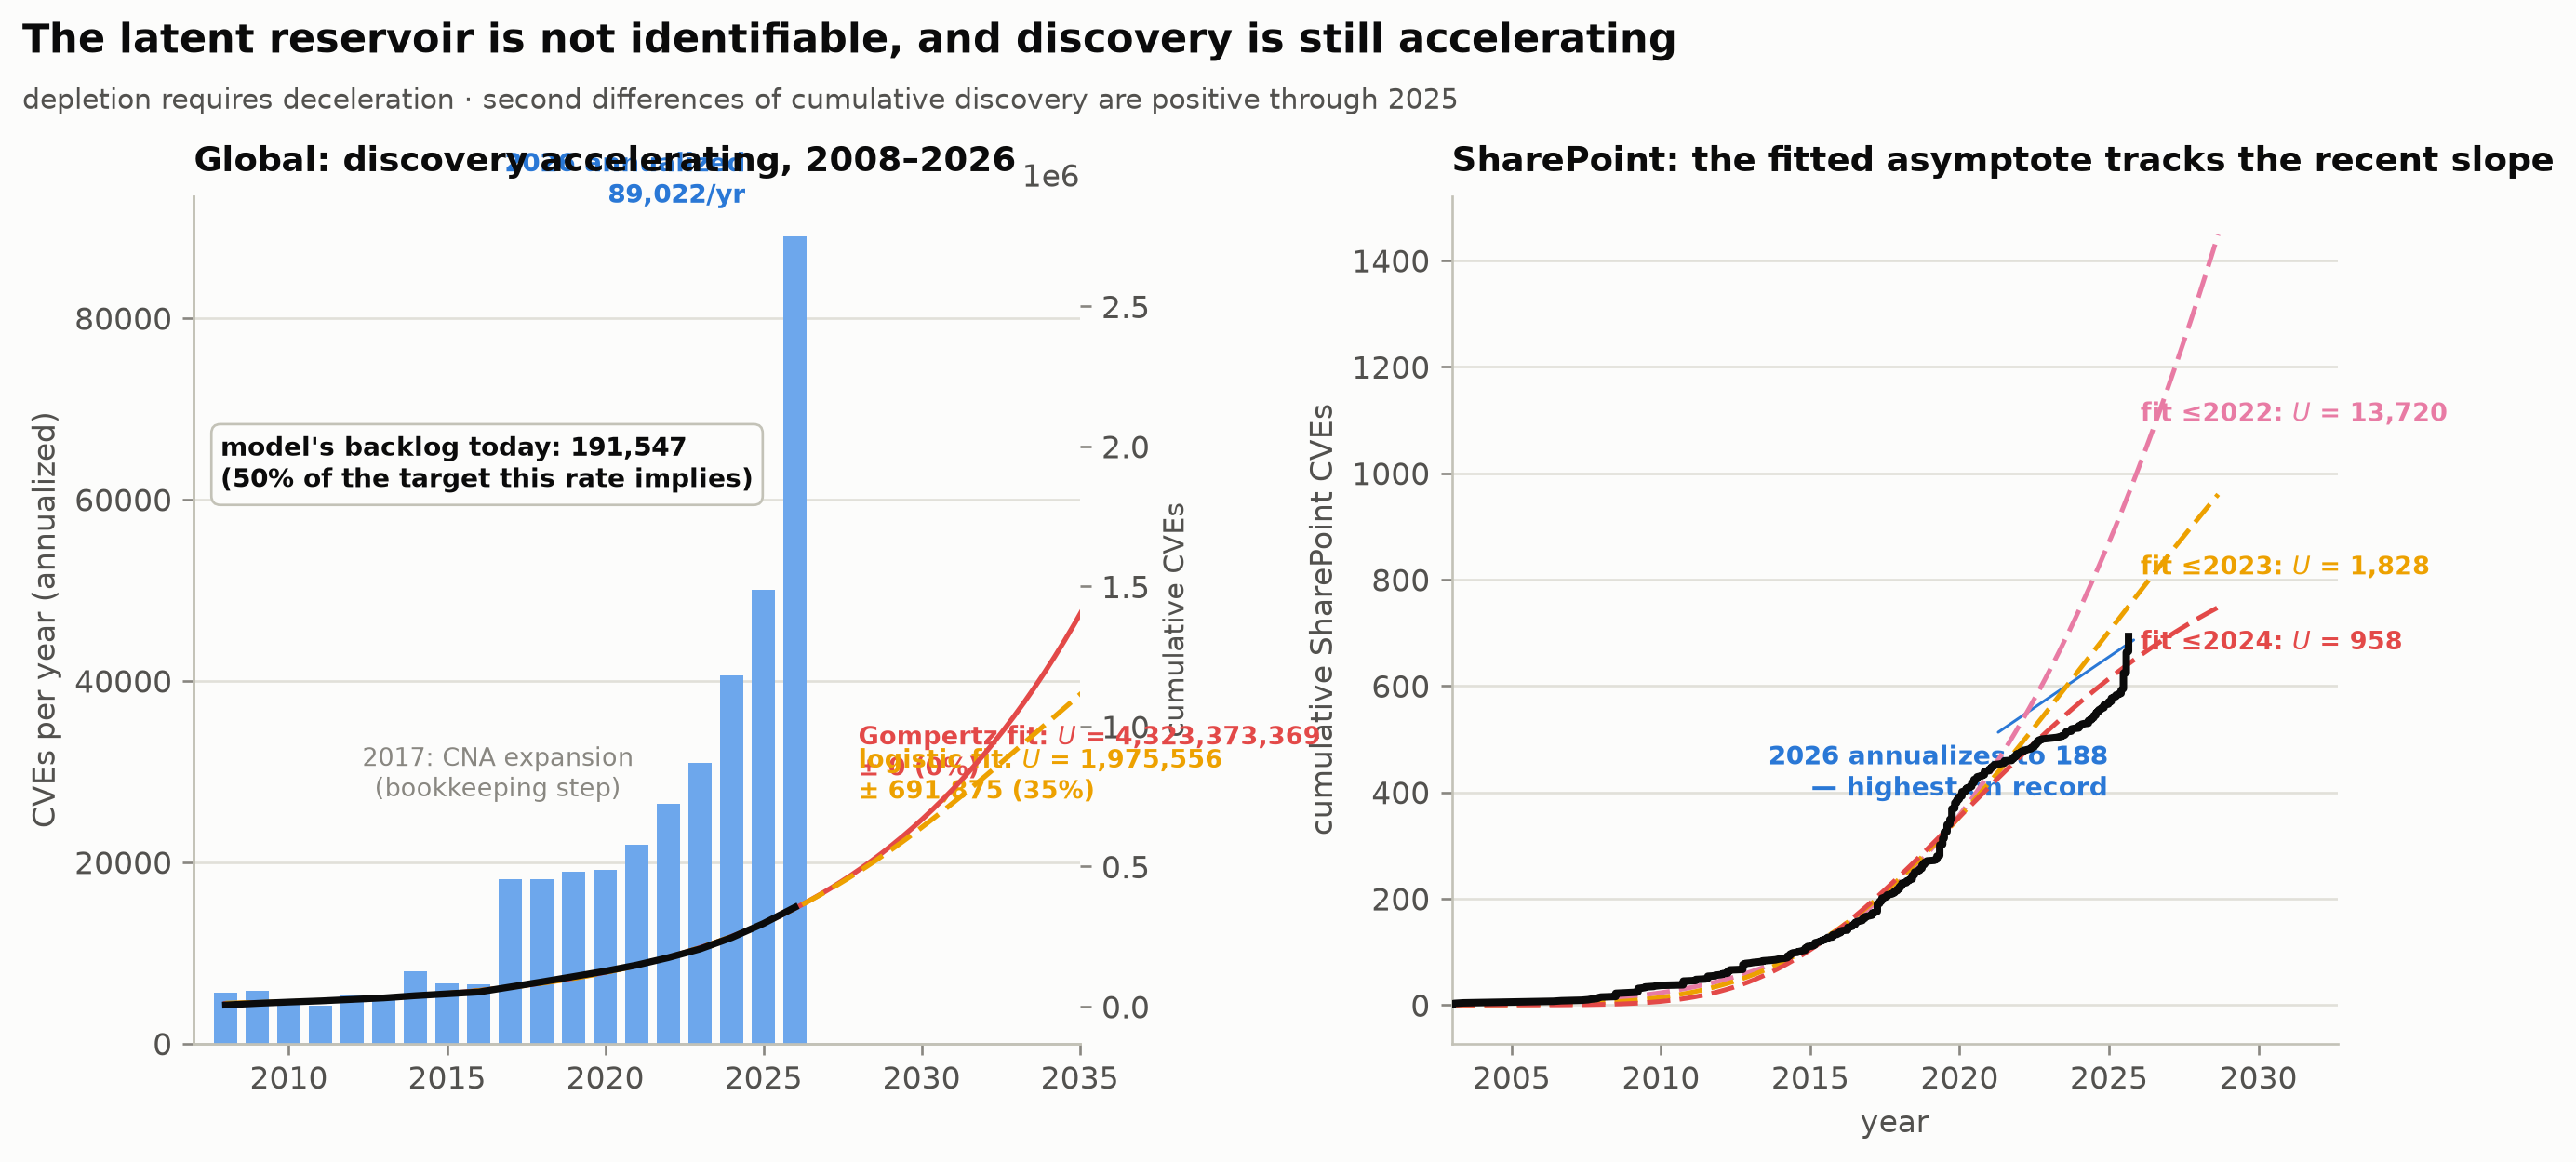

second differences of cumulative discovery (positive = accelerating): 2021:+2,728  2022:+4,481  2023:+4,518  2024:+9,755  2025:+9,268  2026:+8,279
SharePoint per year: {2019: 48, 2020: 121, 2021: 53, 2022: 29, 2023: 27, 2024: 24, 2025: 45, 2026: 123}


In [5]:
years = sorted(int(y) for y in HISTORY)
per_year = np.array([HISTORY[str(y)]["total"] for y in years], dtype=float)
days = np.array([HISTORY[str(y)]["days"] for y in years], dtype=float)
annualized = per_year / days * 365.25
cum = np.cumsum(per_year)
t = np.array(years, dtype=float) - years[0]

gompertz = lambda x, U, b, c: U * np.exp(-b * np.exp(-c * x))
logistic = lambda x, U, r, x0: U / (1 + np.exp(-r * (x - x0)))
fits = {}
for name, fn, p0 in (("Gompertz", gompertz, [1e6, 5, 0.1]), ("logistic", logistic, [1e6, 0.2, 25])):
    popt, pcov = curve_fit(fn, t, cum, p0=p0, bounds=([cum[-1], 1e-4, 1e-4], [1e10, 500, 200]),
                           maxfev=400000)
    fits[name] = (fn, popt, np.sqrt(np.diag(pcov))[0])
    print(f"global {name:<9} U = {popt[0]:>15,.0f} +/- {np.sqrt(np.diag(pcov))[0]:>15,.0f}  "
          f"({np.sqrt(np.diag(pcov))[0] / popt[0]:>5.0%} relative)")

sp_dates = sorted(dt.date.fromisoformat(v["cve"]["published"][:10]) for v in SHAREPOINT_CVES)
sp_t = np.array([(d - sp_dates[0]).days / 365.25 for d in sp_dates])
sp_cum = np.arange(1, len(sp_t) + 1, dtype=float)
sp_year = {}
for d in sp_dates:
    sp_year[d.year] = sp_year.get(d.year, 0) + 1

fig, (ax_g, ax_s) = plt.subplots(1, 2, figsize=(12.2, 5.2))
ax_g.bar(years, annualized, color=SEQ_BLUE[2], width=0.72, zorder=3, label="annualized rate")
ax_g.plot(years, annualized, color=SERIES[0], lw=0, zorder=4)
ax_gt = ax_g.twinx()
ax_gt.plot(years, cum, color=INK, lw=2.2, zorder=5)
for name, color, ls in (("Gompertz", SERIES[7], "-"), ("logistic", SERIES[3], (0, (5, 2)))):
    fn, popt, perr = fits[name]
    xs = np.linspace(0, t[-1] + 14, 200)
    ax_gt.plot(xs + years[0], fn(xs, *popt), color=color, lw=1.6, ls=ls, zorder=4)
    ax_gt.annotate(f"{name} fit: $U$ = {popt[0]:,.0f}\n± {perr:,.0f} ({perr / popt[0]:.0%})",
                   xy=(years[-1] + 2, fn(t[-1] + 6, *popt)), fontsize=8.2, color=color,
                   fontweight="bold", ha="left", va="center", annotation_clip=False)
ax_gt.set_ylabel("cumulative CVEs", color=SECONDARY, fontsize=9)
ax_gt.grid(False)
ax_g.set_ylabel("CVEs per year (annualized)")
ax_g.set_title(f"Global: discovery accelerating, {years[0]}–{years[-1]}")
ax_g.set_xlim(years[0] - 1, years[-1] + 9)
ax_g.annotate("2017: CNA expansion\n(bookkeeping step)", xy=(2017, annualized[years.index(2017)]),
              xytext=(-4, 24), textcoords="offset points", ha="center", va="bottom", fontsize=8,
              color=MUTED)
ax_g.annotate(f"{years[-1]} annualized\n{annualized[-1]:,.0f}/yr", xy=(years[-1], annualized[-1]),
              xytext=(-16, 8), textcoords="offset points", ha="right", va="bottom", fontsize=8.4,
              color=SERIES[0], fontweight="bold")

for cutoff, color in ((2022, SERIES[4]), (2023, SERIES[3]), (2024, SERIES[7])):
    mask = sp_t <= (dt.date(cutoff, 12, 31) - sp_dates[0]).days / 365.25
    popt, _ = curve_fit(gompertz, sp_t[mask], sp_cum[mask], p0=[600, 5, 0.2],
                        bounds=([mask.sum(), 0.01, 1e-3], [1e7, 200, 3]), maxfev=200000)
    xs = np.linspace(0, sp_t[-1] + 3, 200)
    ax_s.plot(xs + sp_dates[0].year, gompertz(xs, *popt), color=color, lw=1.5, ls=(0, (5, 2)),
              zorder=4)
    ax_s.annotate(f"fit ≤{cutoff}: $U$ = {popt[0]:,.0f}", xy=(sp_dates[0].year + sp_t[-1] + 0.4,
                  gompertz(sp_t[-1] + 1, *popt)), fontsize=8.2, color=color, fontweight="bold",
                  ha="left", va="center", annotation_clip=False)
ax_s.plot(sp_t + sp_dates[0].year, sp_cum, color=INK, lw=2.4, zorder=5)
ax_s.set_title("SharePoint: the fitted asymptote tracks the recent slope")
ax_s.set_ylabel("cumulative SharePoint CVEs")
ax_s.set_xlabel("year")
ax_s.set_xlim(sp_dates[0].year, sp_dates[0].year + sp_t[-1] + 7)
ax_s.annotate(f"{SNAPSHOT_DATE.year} annualizes to "
              f"{round(sp_year[SNAPSHOT_DATE.year] * 365.25 / SNAPSHOT_DOY)}\n— highest on record",
              xy=(SNAPSHOT_DATE.year, sp_cum[-1]), xytext=(-10, -34), textcoords="offset points", ha="right",
              va="top", fontsize=8.4, color=SERIES[0], fontweight="bold",
              arrowprops=dict(arrowstyle="-", color=SERIES[0], lw=0.9))

ax_g.annotate(f"model's backlog today: {TRANSIENT[GLOBAL.label]['state']['X']:,.0f}\n"
              f"({TRANSIENT[GLOBAL.label]['state']['X'] / GLOBAL.fixed_point()['X']:.0%} of the target "
              f"this rate implies)", xy=(0.03, 0.72), xycoords="axes fraction", ha="left", va="top",
              fontsize=8.4, color=INK, fontweight="bold",
              bbox=dict(boxstyle="round,pad=0.35", facecolor=SURFACE, edgecolor=BASELINE, lw=0.8))

headline(fig, "The latent reservoir is not identifiable, and discovery is still accelerating",
         "depletion requires deceleration · second differences of cumulative discovery are positive "
         "through 2025", y=0.995, y2=0.945)
fig.subplots_adjust(left=0.068, right=0.855, top=0.845, bottom=0.115, wspace=0.42)
plt.show()

d2 = np.diff(np.diff(cum))
print("second differences of cumulative discovery (positive = accelerating):",
      "  ".join(f"{years[i + 2]}:{d2[i]:+,.0f}" for i in range(len(d2))[-6:]))
print("SharePoint per year:", {y: sp_year[y] for y in sorted(sp_year) if y >= 2019})

## Visualization 4 — which parameters move the exploited population

Elasticities $\partial \ln E^* / \partial \ln p$, ±1% central differences, for both ecosystems, beside a
counterfactual in which every exploited vulnerability is eventually patched ($f$ = 1).

The ranking is not a property of the system alone — it is a property of the system at a given remediation
completeness, and the two columns are the same model at different values of it. At the measured 26%,
decommissioning dominates at **−0.98** and patch delay is negligible at **+0.01**: when three-quarters of
exploited flaws are never fully patched, the speed of the patching channel governs a small corner of the
problem. Set completeness to 100% and the ranking inverts — patch delay **+0.55**, adoption **−0.56**, runtime
defenses **−0.37**, decommissioning **−0.06** — and the equilibrium falls from 1,193 to 100.

The intermediate values are monotone: at a 50% ever-patched share the patch-delay elasticity is +0.037, at 75%
it is +0.110, at 95% it is +0.552. So a disagreement about whether patch timing or software retirement is the
more important control is, in this model, a disagreement about what fraction of exploited vulnerabilities an
organization actually finishes remediating.

Throughput ($C$) and discovery ($\gamma$) are unaffected by completeness, at +0.67 and +0.33, because they act
on the influx rather than on either compartment's drain.

The pale bars give the same elasticities for the count five years from today rather than at equilibrium.
They are uniformly smaller in magnitude, because a fraction of any lever's effect has not yet arrived — the
ordering, however, is preserved, so the ranking is a property of the structure rather than of the horizon.

**Parameter justification.** Both measured columns are evaluated at their own ecosystem's operating point. The
counterfactual changes only $f$, holding every other parameter at its measured value, so the contrast isolates
completeness rather than combining it with other differences.

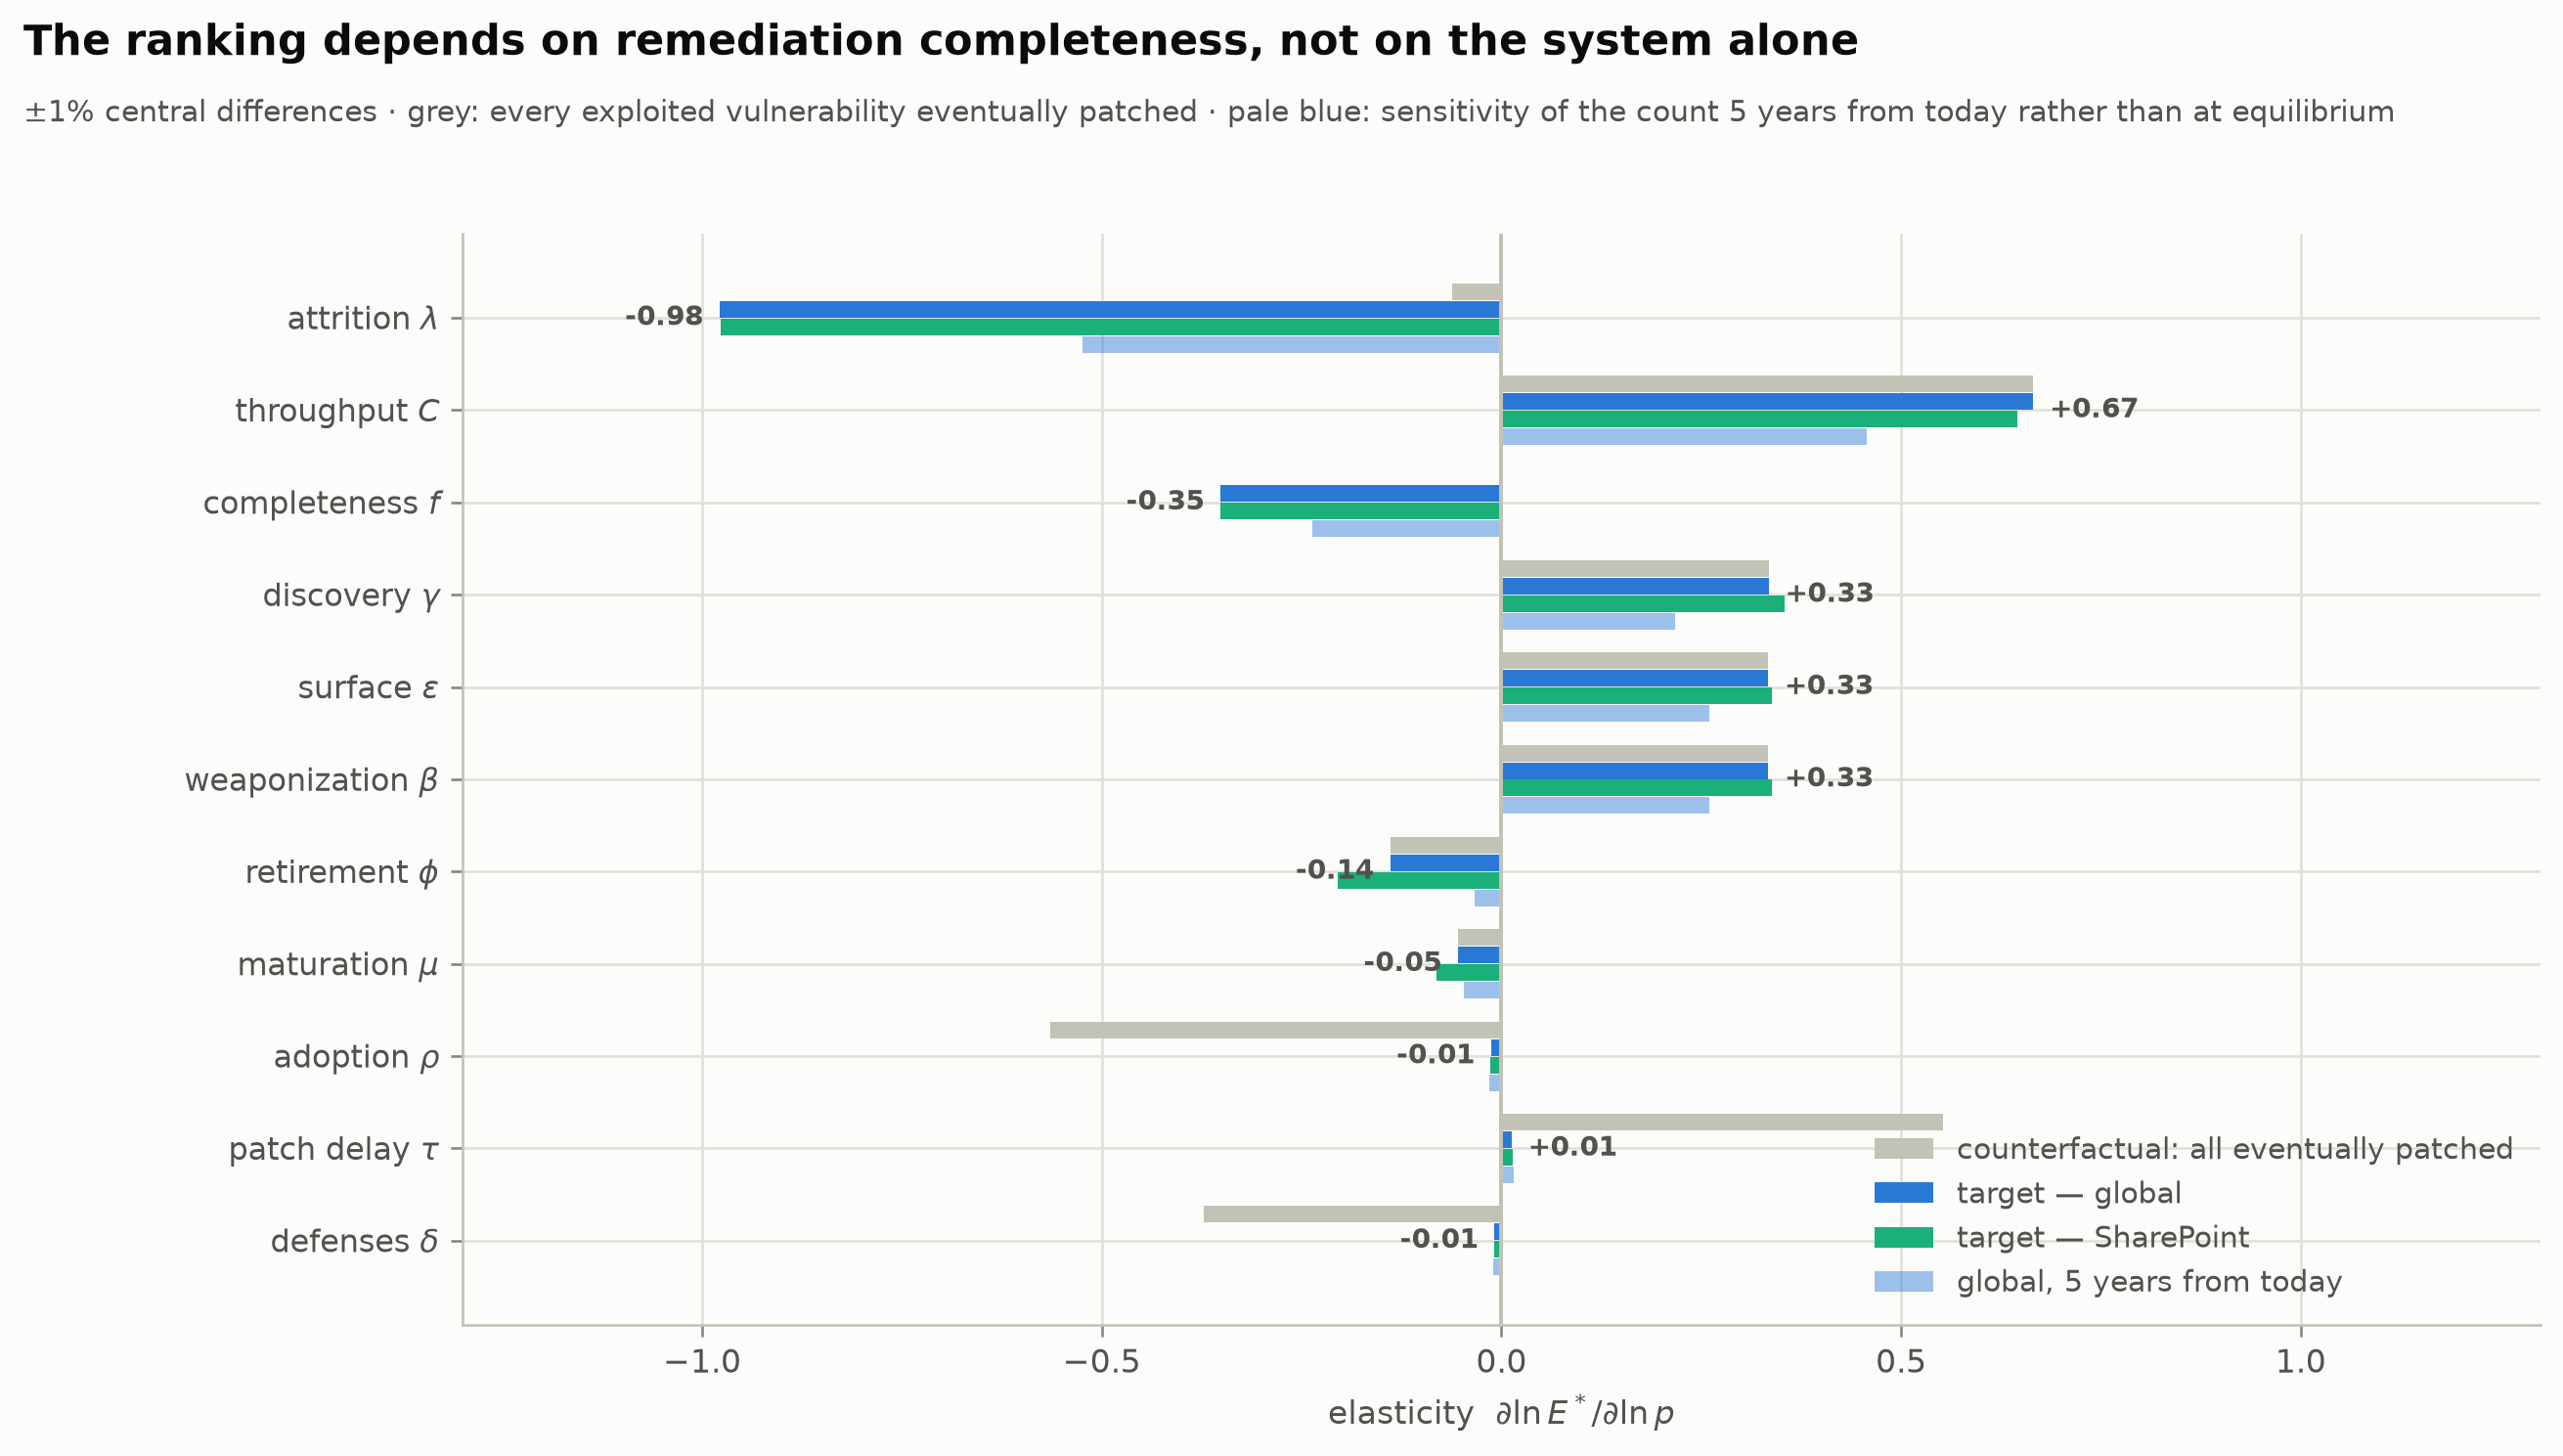

parameter                    global  SharePoint  if all patched
attrition $\lambda$           -0.98       -0.98           -0.06
throughput $C$                +0.67       +0.65           +0.67
completeness $f$              -0.35       -0.35             n/a
discovery $\gamma$            +0.33       +0.35           +0.33
surface $\varepsilon$         +0.33       +0.34           +0.33
weaponization $\beta$         +0.33       +0.34           +0.33
retirement $\phi$             -0.14       -0.20           -0.14
maturation $\mu$              -0.05       -0.08           -0.05
adoption $\rho$               -0.01       -0.01           -0.56
patch delay $\tau$            +0.01       +0.01           +0.55
defenses $\delta$             -0.01       -0.01           -0.37

E* at measured completeness 1,193; if all eventually patched 100
  realized  26%: E*   1,193   tau elasticity +0.013
  realized  50%: E*     806   tau elasticity +0.037
  realized  75%: E*     403   tau elasticity +0.110
  realized

In [6]:
def elasticity(eco, kind, name=None, h=0.01):
    base = eco.fixed_point()["E"]
    if kind == "mult":
        up = eco.fixed_point(**{name: 1 + h})["E"]
        dn = eco.fixed_point(**{name: 1 - h})["E"]
    else:
        v = getattr(eco, name)
        up = replace(eco, **{name: v * (1 + h)}).fixed_point()["E"]
        dn = replace(eco, **{name: v * (1 - h)}).fixed_point()["E"]
    return (up - dn) / (2 * h * base)


SPEC = [("attrition $\\lambda$", "field", "lam"),
        ("throughput $C$", "mult", "cmult"),
        ("discovery $\\gamma$", "mult", "gmult"),
        ("weaponization $\\beta$", "mult", "wmult"),
        ("completeness $f$", "field", "f_fix"),
        ("surface $\\varepsilon$", "mult", "eps"),
        ("retirement $\\phi$", "field", "phi"),
        ("adoption $\\rho$", "field", "rho"),
        ("patch delay $\\tau$", "field", "tau"),
        ("defenses $\\delta$", "field", "delta"),
        ("maturation $\\mu$", "field", "mu")]
# counterfactual: the same model with every exploited vulnerability eventually patched
FULLY_REMEDIATED = replace(GLOBAL, f_fix=1.0, label="all eventually patched")
el = {e.label: {lab: elasticity(e, kind, nm) for lab, kind, nm in SPEC}
      for e in ECOS + [FULLY_REMEDIATED]}
COUNTERFACTUAL = dict(el[FULLY_REMEDIATED.label])
# with f = 1 the residual compartment is empty, so perturbing the routing share is degenerate
COUNTERFACTUAL["completeness $f$"] = np.nan
order = sorted(SPEC, key=lambda s: abs(el[GLOBAL.label][s[0]]))
labels = [s[0] for s in order]
ypos = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(11.0, 6.2))
def transient_elasticity(eco, kind, name, h=0.01):
    """d ln E(HORIZON from today) / d ln p — the sensitivity of the near-term count."""
    def run(scale):
        if kind == "mult":
            return from_today(eco, HORIZON, **{{"cmult": scale, "wmult": scale,
                                                "eps": scale}}.get(name, {name: scale}))[2][-1]
        v = getattr(eco, name)
        return from_today(eco, HORIZON, **{name: v * scale})[2][-1]
    base = from_today(eco, HORIZON)[2][-1]
    return (run(1 + h) - run(1 - h)) / (2 * h * base)


TRANSIENT_EL = {}
for lab, kind, nm in SPEC:
    if kind == "mult" and nm == "gmult":
        f = lambda s: from_today(GLOBAL, HORIZON, gamma=GLOBAL.gamma * s)[2][-1]
    elif kind == "mult":
        f = lambda s, nm=nm: from_today(GLOBAL, HORIZON, **{nm.replace("mult", "mult"): s})[2][-1] \
            if nm in ("cmult", "wmult") else from_today(GLOBAL, HORIZON, wmult=s)[2][-1]
    else:
        f = lambda s, nm=nm: from_today(GLOBAL, HORIZON,
                                        **{nm: getattr(GLOBAL, nm) * s})[2][-1]
    b = from_today(GLOBAL, HORIZON)[2][-1]
    TRANSIENT_EL[lab] = (f(1.01) - f(0.99)) / (0.02 * b)

groups = [("counterfactual: all eventually patched", [COUNTERFACTUAL[l] for l in labels],
           BASELINE, 0.285),
          ("target — global", [el[GLOBAL.label][l] for l in labels], SERIES[0], 0.095),
          ("target — SharePoint", [el[SHAREPOINT.label][l] for l in labels], SERIES[2], -0.095),
          (f"global, {HORIZON:.0f} years from today",
           [TRANSIENT_EL[l] for l in labels], mpl.colors.to_rgba(SERIES[0], 0.45), -0.285)]
for name, vals, color, off in groups:
    ax.barh(ypos + off, np.nan_to_num(vals, nan=0.0), height=0.18, color=color, zorder=3,
            label=name)
for y, l in zip(ypos, labels):
    v = el[GLOBAL.label][l]
    ax.annotate(f"{v:+.2f}", xy=(v, y), xytext=(5 if v >= 0 else -5, 0),
                textcoords="offset points", ha="left" if v >= 0 else "right", va="center",
                fontsize=8.4, color=SECONDARY, fontweight="bold", zorder=5)
ax.axvline(0, color=BASELINE, lw=1.2, zorder=4)
ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=9.5)
ax.set_xlabel("elasticity  $\\partial \\ln E^* / \\partial \\ln p$")
ax.set_xlim(-1.3, 1.3)
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.legend(loc="lower right", fontsize=9, labelcolor=SECONDARY)

headline(fig, "The ranking depends on remediation completeness, not on the system alone",
         "±1% central differences · grey: every exploited vulnerability eventually patched · "
         f"pale blue: sensitivity of the count {HORIZON:.0f} years from today rather than at equilibrium",
         y=0.995, y2=0.948)
fig.subplots_adjust(left=0.175, right=0.98, top=0.85, bottom=0.10)
plt.show()

print(f"{'parameter':<26}{'global':>9}{'SharePoint':>12}{'if all patched':>16}")
for l in reversed(labels):
    cf = COUNTERFACTUAL[l]
    print(f"{l.replace(chr(92) * 2, chr(92)):<26}{el[GLOBAL.label][l]:>+9.2f}"
          f"{el[SHAREPOINT.label][l]:>+12.2f}"
          f"{('n/a' if cf != cf else f'{cf:+.2f}'):>16}")
print(f"\nE* at measured completeness {GLOBAL.fixed_point()['E']:,.0f}; "
      f"if all eventually patched {FULLY_REMEDIATED.fixed_point()['E']:,.0f}")
ps = GLOBAL.patch_rate / (GLOBAL.patch_rate + GLOBAL.lam)
for realized in (0.26, 0.5, 0.75, 0.95):
    ee = replace(GLOBAL, f_fix=min(1.0, realized / ps))
    print(f"  realized {realized:>4.0%}: E* {ee.fixed_point()['E']:>7,.0f}   "
          f"tau elasticity {elasticity(ee, 'field', 'tau'):+.3f}")

## Visualization 5 — defender completeness against attacker shocks

$E^*$ over remediation completeness $f$ at three decommissioning horizons, with the AI scenarios drawn as
horizontal reference levels, and a ranked comparison of what each lever delivers.

Raising the ever-patched share from today's 26% to 75% cuts global $E^*$ from 1,193 to **403**, a 66% reduction. That
exceeds the effect of any single attacker shock considered — 10× discovery is +43%, 3× throughput is +80% —
and is comparable to reversing both. Shortening the decommissioning horizon from 5.5 to 3 years does similar
work. Neither is fast: both act through multi-year stocks, quantified in Visualization 9.

This figure is also where the model is most sensitive to its weakest inputs, drawn so that is visible. $f$ =
0.26 and $1/\lambda$ = 5.5 years jointly set the level to within a factor of three. At a 50% ever-patched share, today's
$E^*$ is 806 rather than 1,193, and every scenario level shifts with it.

Dashed curves give the same sweep evaluated five years from today's state. They sit above the equilibrium
curves at high completeness, because improving completeness cannot retire a backlog that is already present —
the near-term floor is set by what has already accumulated.

**Parameter justification.** The horizontal axis is the *realized* ever-patched share, spanning 0.26
(Verizon 2026 DBIR median) to 0.95; no published estate reaches
the upper end. $1/\lambda$ spans 3–10 years, bracketing Synopsys OSSRA's 2.5-year mean OSS vulnerability age
and its finding that a quarter of codebases carry decade-old flaws. All other parameters remain at their
measured values, so both axes are perturbations about the marked operating point.

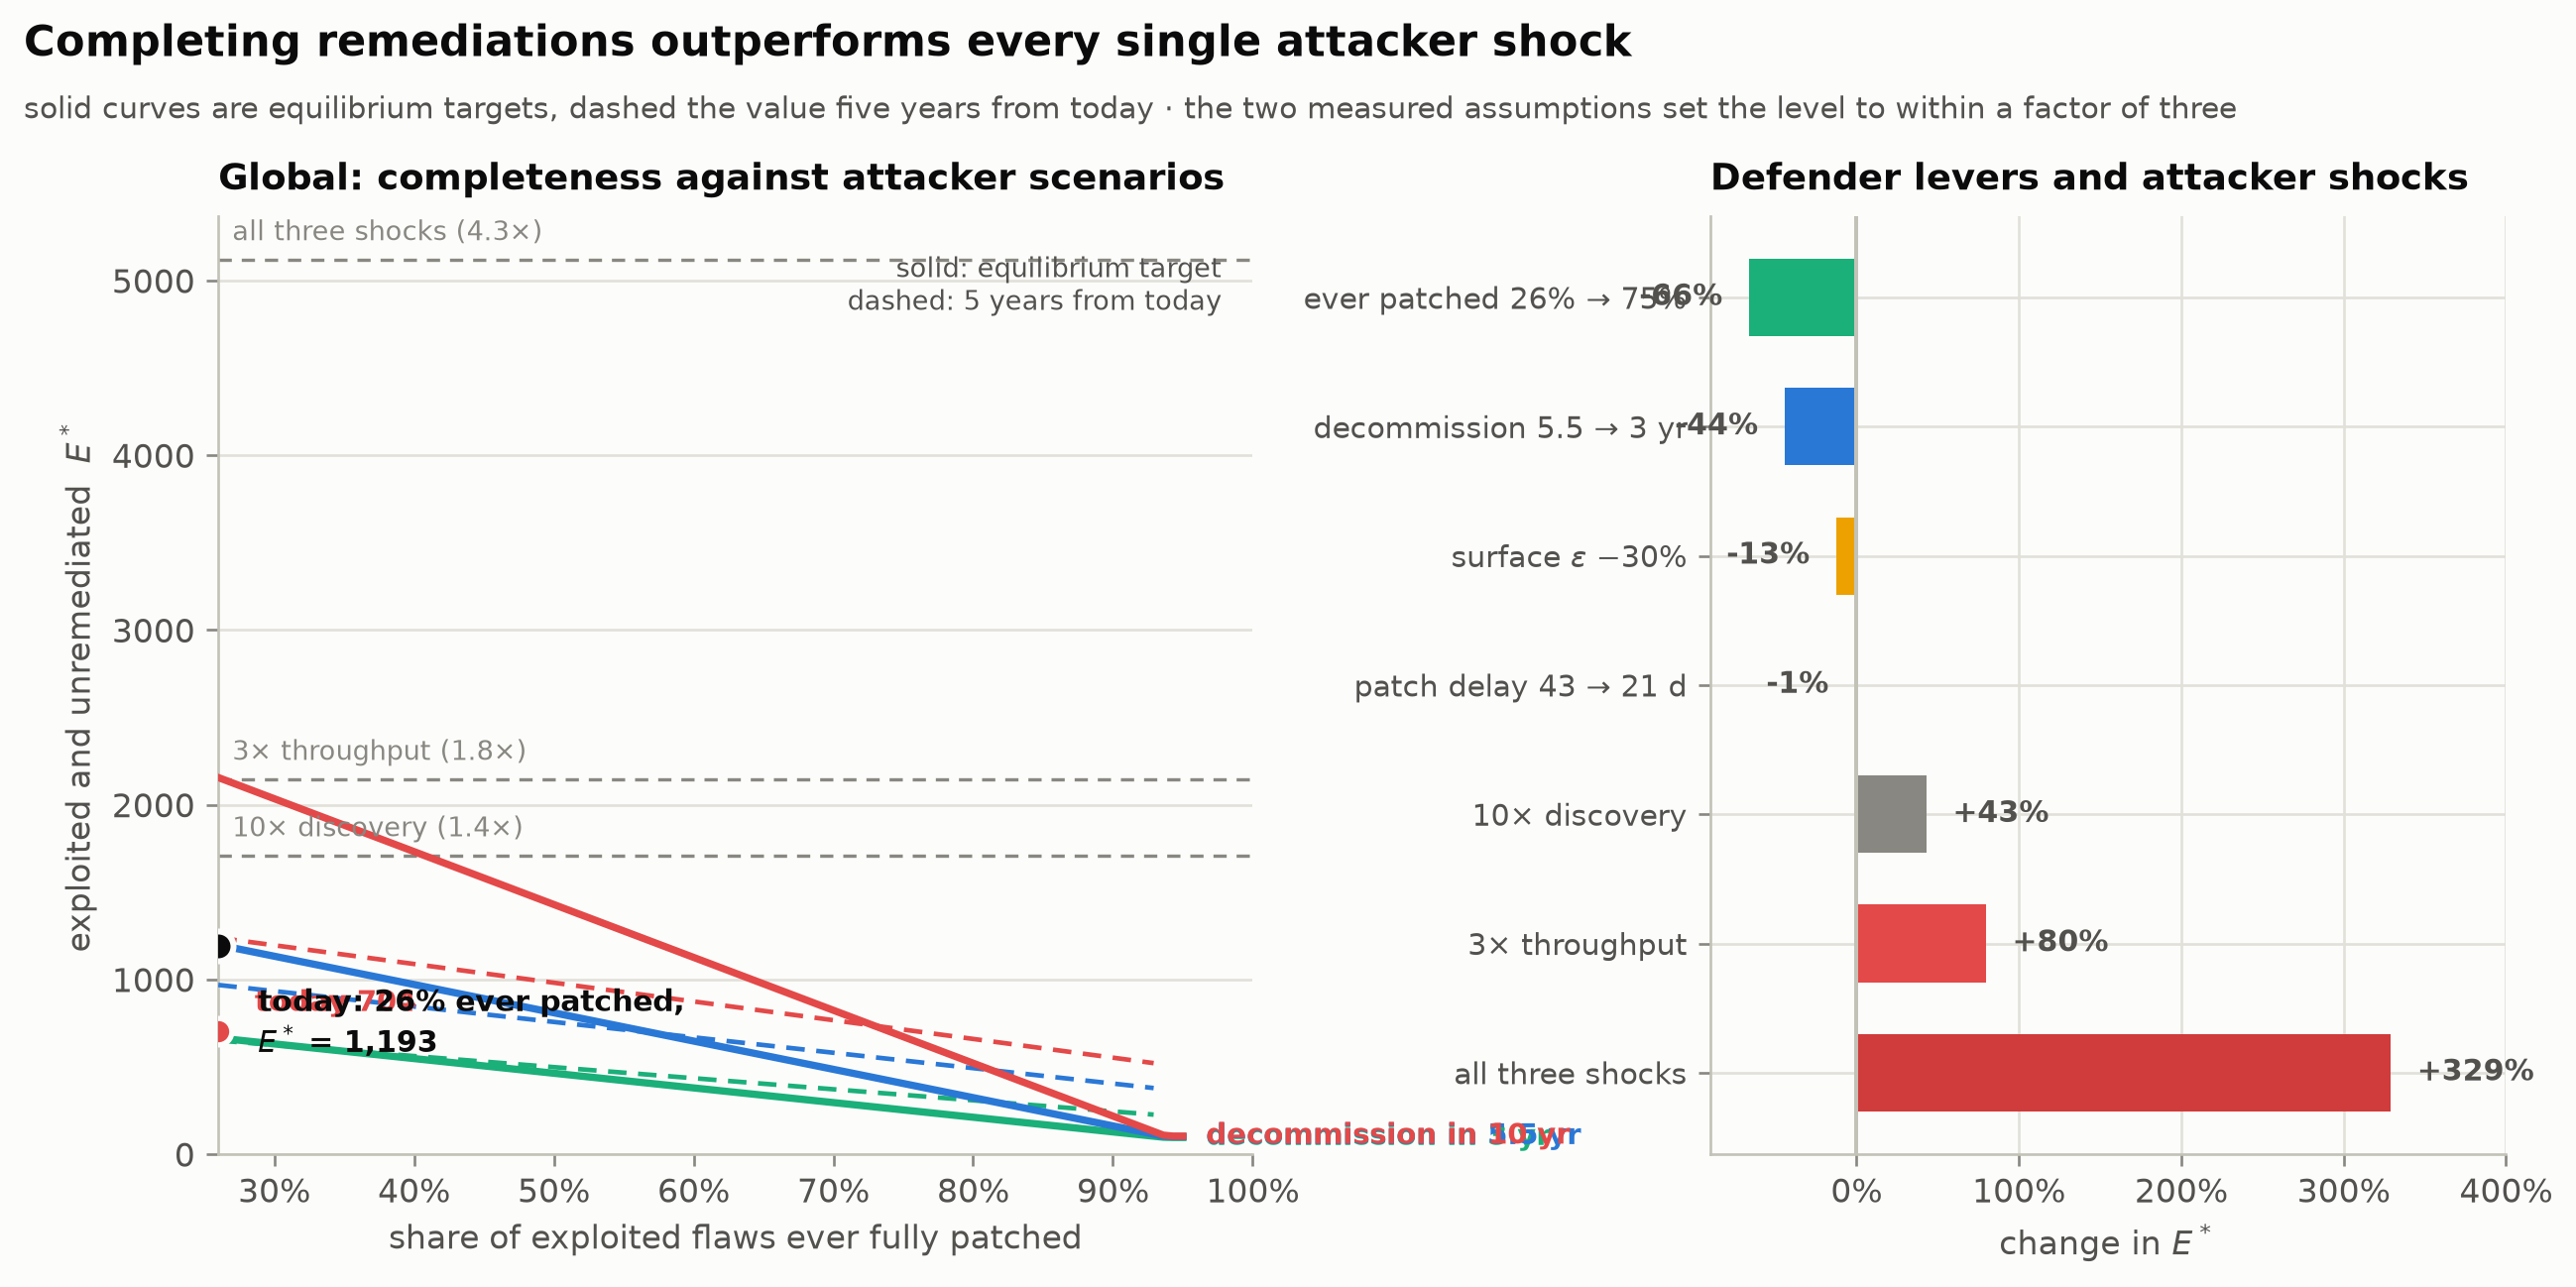

ever patched 26% → 75%           -66%   E*       403
decommission 5.5 → 3 yr          -44%   E*       665
surface $\varepsilon$ −30%       -13%   E*     1,044
patch delay 43 → 21 d             -1%   E*     1,183
10× discovery                    +43%   E*     1,706
3× throughput                    +80%   E*     2,144
all three shocks                +329%   E*     5,118


In [7]:
# x axis is the REALIZED ever-patched share; f = realized / (share of E_p exiting by
# patching), so the axis reads as the Verizon-style measurement rather than as f
PATCHED_SHARE = GLOBAL.patch_rate / (GLOBAL.patch_rate + GLOBAL.lam)
F_GRID = np.linspace(EVER_PATCHED, 0.95, 100)
base = GLOBAL.fixed_point()["E"]

fig, (ax_f, ax_r) = plt.subplots(1, 2, figsize=(12.2, 5.4), gridspec_kw={"width_ratios": [1.3, 1]})
SPARSE = F_GRID[::12]
for years, color in zip((3, 5.5, 10), (SERIES[2], SERIES[0], SERIES[7])):
    curve = [GLOBAL.fixed_point(f_fix=min(1.0, f / PATCHED_SHARE),
                            lam=1 / (years * 365))["E"] for f in F_GRID]
    ax_f.plot(F_GRID * 100, curve, color=color, lw=2.2, zorder=3)
    near = [from_today(GLOBAL, HORIZON, f_fix=min(1.0, f / PATCHED_SHARE),
                       lam=1 / (years * 365))[2][-1] for f in SPARSE]
    ax_f.plot(SPARSE * 100, near, color=color, lw=1.4, ls=(0, (4, 2.5)), zorder=3)
    ax_f.annotate(f"decommission in {years:g} yr", xy=(95, curve[-1]), xytext=(7, 0),
                  textcoords="offset points", ha="left", va="center", fontsize=8.6, color=color,
                  fontweight="bold", annotation_clip=False)
for mult, lab in ((GLOBAL.fixed_point(gmult=10)["E"] / base, "10× discovery"),
                  (GLOBAL.fixed_point(cmult=3)["E"] / base, "3× throughput"),
                  (GLOBAL.fixed_point(gmult=10, wmult=3, cmult=3)["E"] / base, "all three shocks")):
    ax_f.axhline(base * mult, color=MUTED, lw=1, ls=(0, (4, 3)), zorder=2)
    ax_f.annotate(f"{lab} ({mult:.1f}×)", xy=(27, base * mult), xytext=(0, 4),
                  textcoords="offset points", ha="left", va="bottom", fontsize=8.2, color=MUTED)
ax_f.plot(EVER_PATCHED * 100, base, "o", ms=9, color=INK, mec=SURFACE, mew=1.8, zorder=6)
today_E = TRANSIENT[GLOBAL.label]["state"]["E"]
ax_f.plot(EVER_PATCHED * 100, today_E, "o", ms=8, color=SERIES[7], mec=SURFACE, mew=1.6, zorder=6)
ax_f.annotate(f"today {today_E:,.0f}", xy=(EVER_PATCHED * 100, today_E), xytext=(11, 4),
              textcoords="offset points", ha="left", va="bottom", fontsize=8.6, color=SERIES[7],
              fontweight="bold", zorder=6)
ax_f.annotate("solid: equilibrium target\ndashed: 5 years from today", xy=(0.97, 0.96),
              xycoords="axes fraction", ha="right", va="top", fontsize=8.2, color=SECONDARY)
ax_f.annotate(f"today: {EVER_PATCHED:.0%} ever patched,\n$E^*$ = {base:,.0f}", xy=(EVER_PATCHED * 100, base),
              xytext=(12, -12), textcoords="offset points", ha="left", va="top", fontsize=9,
              color=INK, fontweight="bold", zorder=6)
ax_f.set_xlabel("share of exploited flaws ever fully patched")
ax_f.set_ylabel("exploited and unremediated  $E^*$")
ax_f.set_title("Global: completeness against attacker scenarios")
ax_f.set_xlim(EVER_PATCHED * 100, 100)
ax_f.set_ylim(0, None)
ax_f.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))

levers = [("ever patched 26% → 75%",
           GLOBAL.fixed_point(f_fix=0.75 / PATCHED_SHARE)["E"] / base - 1, SERIES[2]),
          ("decommission 5.5 → 3 yr", GLOBAL.fixed_point(lam=1 / (3 * 365))["E"] / base - 1, SERIES[0]),
          ("surface $\\varepsilon$ −30%", GLOBAL.fixed_point(eps=0.7)["E"] / base - 1, SERIES[3]),
          ("patch delay 43 → 21 d", GLOBAL.fixed_point(tau=21)["E"] / base - 1, SERIES[4]),
          ("10× discovery", GLOBAL.fixed_point(gmult=10)["E"] / base - 1, MUTED),
          ("3× throughput", GLOBAL.fixed_point(cmult=3)["E"] / base - 1, SERIES[7]),
          ("all three shocks", GLOBAL.fixed_point(gmult=10, wmult=3, cmult=3)["E"] / base - 1,
           "#d03b3b")]
ys = np.arange(len(levers))[::-1]
ax_r.barh(ys, [100 * l[1] for l in levers], color=[l[2] for l in levers], height=0.6, zorder=3)
for y, (lab, val, col) in zip(ys, levers):
    ax_r.annotate(f"{100 * val:+.0f}%", xy=(100 * val, y), xytext=(8 if val >= 0 else -8, 0),
                  textcoords="offset points", ha="left" if val >= 0 else "right", va="center",
                  fontsize=9, fontweight="bold", color=SECONDARY, zorder=4)
ax_r.axvline(0, color=BASELINE, lw=1.2, zorder=4)
ax_r.set_yticks(ys)
ax_r.set_yticklabels([l[0] for l in levers], fontsize=9)
ax_r.set_xlabel("change in $E^*$")
ax_r.set_title("Defender levers and attacker shocks")
ax_r.set_xlim(-90, 400)
ax_r.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))
ax_r.grid(axis="x")
ax_r.set_axisbelow(True)

headline(fig, "Completing remediations outperforms every single attacker shock",
         "solid curves are equilibrium targets, dashed the value five years from today · the two "
         "measured assumptions set the level to within a factor of three", y=0.995, y2=0.945)
fig.subplots_adjust(left=0.072, right=0.86, top=0.845, bottom=0.115, wspace=0.5)
plt.show()

for lab, val, _ in levers:
    print(f"{lab.replace(chr(92) * 2, chr(92)):<28}{100 * val:>+8.0f}%   E* {base * (1 + val):>9,.0f}")

## Visualization 6 — measured stocks and flows

The full structure with every rate measured, for both ecosystems: five stocks, with exploitation drawn
from the hidden pool as well as the disclosed ones, and the exploited population split by whether it is ever
fully remediated.

Three features carry most of the model's behaviour. **The exploitation branch is thin**: globally 212 CVEs a
day enter and 0.81 a day are converted, about 1 in 263 at equilibrium; for SharePoint the ratio is about 1 in
16, consistent with its 6.9× higher KEV rate. **Conversion is capped**: weaponizable supply reaches 2.41/day
against a throughput of 1.21/day, so only 33% of it is realized, and the unconverted remainder
stays in the pools — the node in the middle of the
diagram, and the reason discovery volume propagates weakly. **The exploited population is almost entirely the
residual compartment**: $E_r$ holds 1,165 of the global 1,193 and 14.9 of SharePoint's 15.3, because it drains only through decommissioning.

The hidden pool $H$ carries the pre-disclosure channel. At 42% of exploitation arriving before disclosure
(CrowdStrike 2026) and a mean time-to-exploit of −7 days (Mandiant M-Trends 2026), that channel is the
largest single one, so a structure in which exploitation follows disclosure would have the causal order wrong.

**Parameter justification.** Flows are the measured publication rate ($\gamma$ = 212/day global, 0.178/day
SharePoint over three years) and the measured KEV addition rate (0.81/day and 0.012/day). $\delta_d$ = 1/45
day⁻¹ is assumed from the 90-day coordinated-disclosure norm with many vendor-found bugs faster. $\mu$ = 1/30
day⁻¹ is one patch cycle. $\phi$ = 1/1825 and 1/3650 day⁻¹ are 5- and 10-year support horizons, checked
against corpus size (385,394 predicted vs 383,528 observed; 609 vs 693).

global ecosystem       supply   2.414/d  realized  0.8062/d ( 33%)  1 in    263   E  1,193.2  Er share 98%   balance in-out +0.00e+00
Microsoft SharePoint   supply   0.033/d  realized  0.0113/d ( 34%)  1 in     16   E     15.3  Er share 97%   balance in-out +0.00e+00


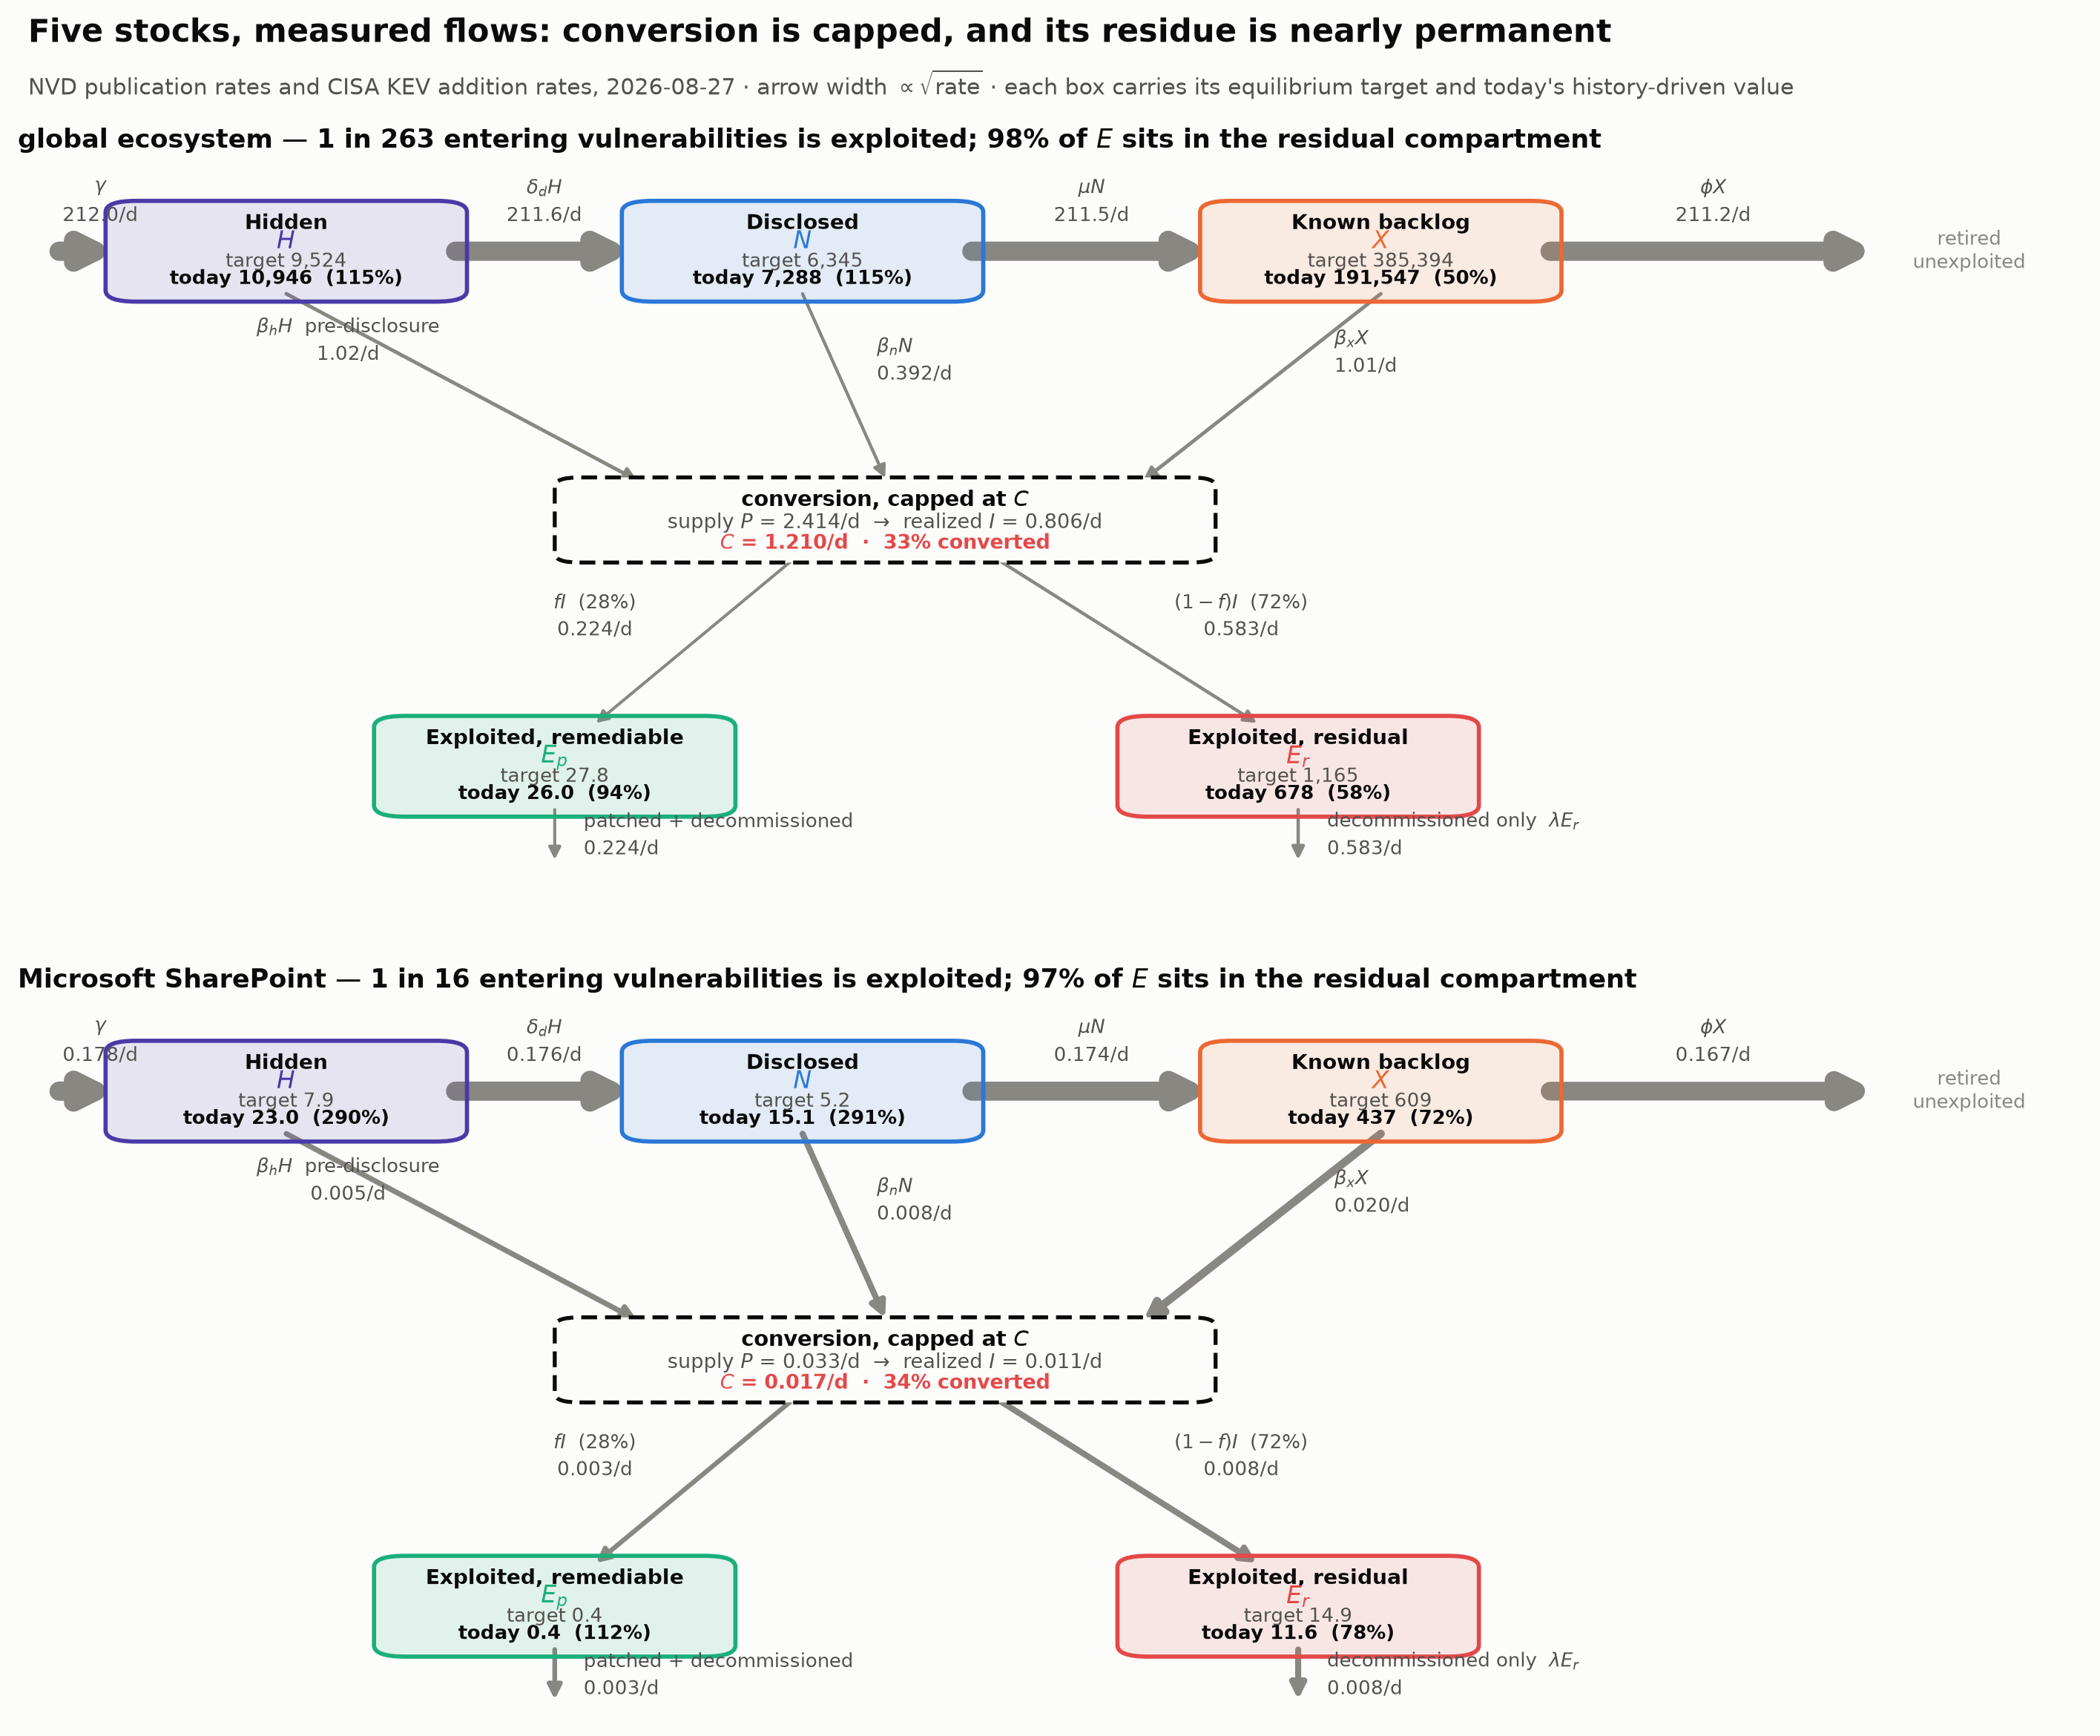

In [8]:
from matplotlib.patches import FancyBboxPatch


def stock(ax, xy, title, sym, val, color, today=None, w=0.165, h=0.125):
    """Box labelled with the equilibrium target and, where given, today's driven value."""
    x, y = xy
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                boxstyle="round,pad=0.005,rounding_size=0.015", linewidth=1.7,
                                edgecolor=color, facecolor=mpl.colors.to_rgba(color, 0.12), zorder=3))
    fmt = lambda v: f"{v:,.1f}" if v < 100 else f"{v:,.0f}"
    ax.text(x, y + 0.037, title, ha="center", va="center", fontsize=8.4, fontweight="bold",
            color=INK, zorder=4)
    ax.text(x, y + 0.012, sym, ha="center", va="center", fontsize=10, color=color, zorder=4)
    ax.text(x, y - 0.014, f"target {fmt(val)}", ha="center", va="center", fontsize=7.8,
            color=SECONDARY, zorder=4)
    if today is not None:
        ax.text(x, y - 0.037, f"today {fmt(today)}  ({today / val:.0%})", ha="center", va="center",
                fontsize=7.8, color=INK, fontweight="bold", zorder=4)


def flow(ax, a, b, rate, lab, ref, off=(0, 0), ha="center", va="bottom", color=MUTED, fs=7.8):
    lw = 1.0 + 6.8 * (max(rate, 0) / ref) ** 0.5
    ax.annotate("", xy=b, xytext=a, arrowprops=dict(arrowstyle="-|>", lw=lw, color=color,
                mutation_scale=8 + 1.8 * lw, shrinkA=0, shrinkB=0), zorder=2)
    fmt = f"{rate:,.3f}" if rate < 1 else (f"{rate:,.2f}" if rate < 100 else f"{rate:,.1f}")
    ax.text((a[0] + b[0]) / 2 + off[0], (a[1] + b[1]) / 2 + off[1], f"{lab}\n{fmt}/d", ha=ha,
            va=va, fontsize=fs, color=SECONDARY, linespacing=1.35, zorder=5)


fig, axes = plt.subplots(2, 1, figsize=(11.6, 9.6))
for ax, e in zip(axes, ECOS):
    fp = e.fixed_point()
    b_h, b_n, b_x = e.hazards
    supply = b_h * fp["H"] + b_n * fp["N"] + b_x * fp["X"]
    realized = fp["influx"]
    ref = e.gamma
    ax.set_xlim(0, 1); ax.set_ylim(0.02, 0.99); ax.axis("off")
    H, N, X = (0.13, 0.86), (0.38, 0.86), (0.66, 0.86)
    JUNC, EP, ER = (0.42, 0.50), (0.26, 0.17), (0.62, 0.17)
    td = TRANSIENT[e.label]["state"]
    stock(ax, H, "Hidden", "$H$", fp["H"], SERIES[6], td["H"])
    stock(ax, N, "Disclosed", "$N$", fp["N"], SERIES[0], td["N"])
    stock(ax, X, "Known backlog", "$X$", fp["X"], SERIES[1], td["X"])
    stock(ax, EP, "Exploited, remediable", "$E_p$", fp["Ep"], SERIES[2], td["Ep"])
    stock(ax, ER, "Exploited, residual", "$E_r$", fp["Er"], SERIES[7], td["Er"])

    # the conversion step: supply arrives, throughput caps what is realized
    ax.add_patch(FancyBboxPatch((JUNC[0] - 0.155, JUNC[1] - 0.052), 0.31, 0.104,
                                boxstyle="round,pad=0.005,rounding_size=0.012", linewidth=1.6,
                                edgecolor=INK, facecolor=SURFACE, linestyle=(0, (4, 2)), zorder=3))
    ax.text(JUNC[0], JUNC[1] + 0.026, "conversion, capped at $C$", ha="center", va="center",
            fontsize=8.6, fontweight="bold", color=INK, zorder=4)
    ax.text(JUNC[0], JUNC[1] - 0.004,
            f"supply $P$ = {supply:,.3f}/d  →  realized $I$ = {realized:,.3f}/d", ha="center",
            va="center", fontsize=8.2, color=SECONDARY, zorder=4)
    ax.text(JUNC[0], JUNC[1] - 0.032, f"$C$ = {e.C:,.3f}/d  ·  {realized / supply:.0%} converted",
            ha="center", va="center", fontsize=8.0, color=SERIES[7], fontweight="bold", zorder=4)

    flow(ax, (0.020, 0.86), (0.048, 0.86), e.gamma, r"$\gamma$", ref, (0.006, 0.032))
    flow(ax, (0.212, 0.86), (0.298, 0.86), e.disclose * fp["H"], r"$\delta_d H$", ref, (0, 0.032))
    flow(ax, (0.462, 0.86), (0.578, 0.86), e.mu * fp["N"], r"$\mu N$", ref, (0, 0.032))
    flow(ax, (0.742, 0.86), (0.90, 0.86), e.phi * fp["X"], r"$\phi X$", ref, (0, 0.032))
    ax.text(0.945, 0.86, "retired\nunexploited", ha="center", va="center", fontsize=7.8, color=MUTED)

    flow(ax, (0.13, 0.803), (0.30, 0.553), b_h * fp["H"], r"$\beta_h H$  pre-disclosure", ref,
         (-0.055, 0.028), ha="center")
    flow(ax, (0.38, 0.803), (0.42, 0.556), b_n * fp["N"], r"$\beta_n N$", ref, (0.016, 0.0),
         ha="left")
    flow(ax, (0.66, 0.803), (0.545, 0.553), b_x * fp["X"], r"$\beta_x X$", ref, (0.035, 0.012),
         ha="left")
    flow(ax, (0.375, 0.446), (0.28, 0.228), e.f_fix * realized, f"${{f}}I$  ({e.f_fix:.0%})", ref,
         (-0.048, 0.0), ha="center")
    flow(ax, (0.475, 0.446), (0.60, 0.228), (1 - e.f_fix) * realized,
         f"$(1-f)I$  ({1 - e.f_fix:.0%})", ref, (0.055, 0.0), ha="center")
    flow(ax, (0.26, 0.112), (0.26, 0.045), (e.patch_rate + e.lam) * fp["Ep"],
         r"patched + decommissioned", ref, (0.014, 0), ha="left", va="center")
    flow(ax, (0.62, 0.112), (0.62, 0.045), e.lam * fp["Er"], r"decommissioned only  $\lambda E_r$",
         ref, (0.014, 0), ha="left", va="center")
    ax.set_title(f"{e.label} — 1 in {e.gamma / realized:,.0f} entering vulnerabilities is exploited; "
                 f"{fp['Er'] / fp['E']:.0%} of $E$ sits in the residual compartment",
                 fontsize=10.5, pad=2)
    print(f"{e.label:<22} supply {supply:>7.3f}/d  realized {realized:>7.4f}/d "
          f"({realized / supply:>4.0%})  1 in {e.gamma / realized:>6,.0f}   "
          f"E {fp['E']:>8,.1f}  Er share {fp['Er'] / fp['E']:.0%}   "
          f"balance in-out {realized - (e.patch_rate + e.lam) * fp['Ep'] - e.lam * fp['Er']:+.2e}")

headline(fig, "Five stocks, measured flows: conversion is capped, and its residue is nearly permanent",
         f"NVD publication rates and CISA KEV addition rates, {SNAPSHOT_DATE} · arrow width "
         "$\\propto \\sqrt{\\mathrm{rate}}$ · each box carries its equilibrium target and today's "
         "history-driven value",
         y=0.995, y2=0.965)
fig.subplots_adjust(left=0.0, right=1.0, top=0.915, bottom=0.0, hspace=0.16)
plt.show()

## Visualization 7 — four futures for discovery, one of them mechanistic

Discovery trajectories can be posited exogenously or derived. With the reservoir $U$ in the structure, one of
them follows from the mechanism: if discovery is $\gamma = \psi U$ and automation raises efficiency $\psi$,
the surge must decay as $U$ depletes, at a rate set by replenishment from new code.

The four trajectories are: the surge fades exogenously; it becomes the baseline; it compounds at the measured
+56%/yr; and it compounds through a 10× efficiency jump against a finite reservoir. The last decays back
toward the replenishment rate on a timescale of about $U_0 / (10\gamma)$ — about sixteen months at this $U_0$ — without any assumption about attacker or defender behaviour.

Trajectories start from today's history-driven state rather than from equilibrium, and the black dashed line
marks the equilibrium today's discovery rate already implies. Two movements are therefore superimposed: the
slow climb toward that target, which happens under every scenario, and the scenario's own effect. The fading
surge still rises, because the backlog is filling regardless. The reservoir scenario is nearly
indistinguishable from the exogenous-fade case in its effect on exploitation, which is the point — under
capacity limitation, the difference between discovery futures barely propagates.

**Parameter justification.** The 1.56× step and +56%/yr growth rate are the same measured figure (NVD: 330/day
most recent quarter against 212/day trailing year) read as a level and as a rate. The reservoir scenario uses
$U_0$ = 1.0M remaining — a round figure held below the 1.6M the logistic fit implies once the 355k already
discovered is subtracted, and a lower bound in any case since the Gompertz fit is unidentified, $\psi$ pinned so $\psi U_0$ equals today's discovery rate, replenishment
$\sigma S$ set equal to today's discovery rate (the value implied by 19 years without deceleration), and a 10×
efficiency jump. The 10× cap on the compounding scenario is arbitrary and marked as such.

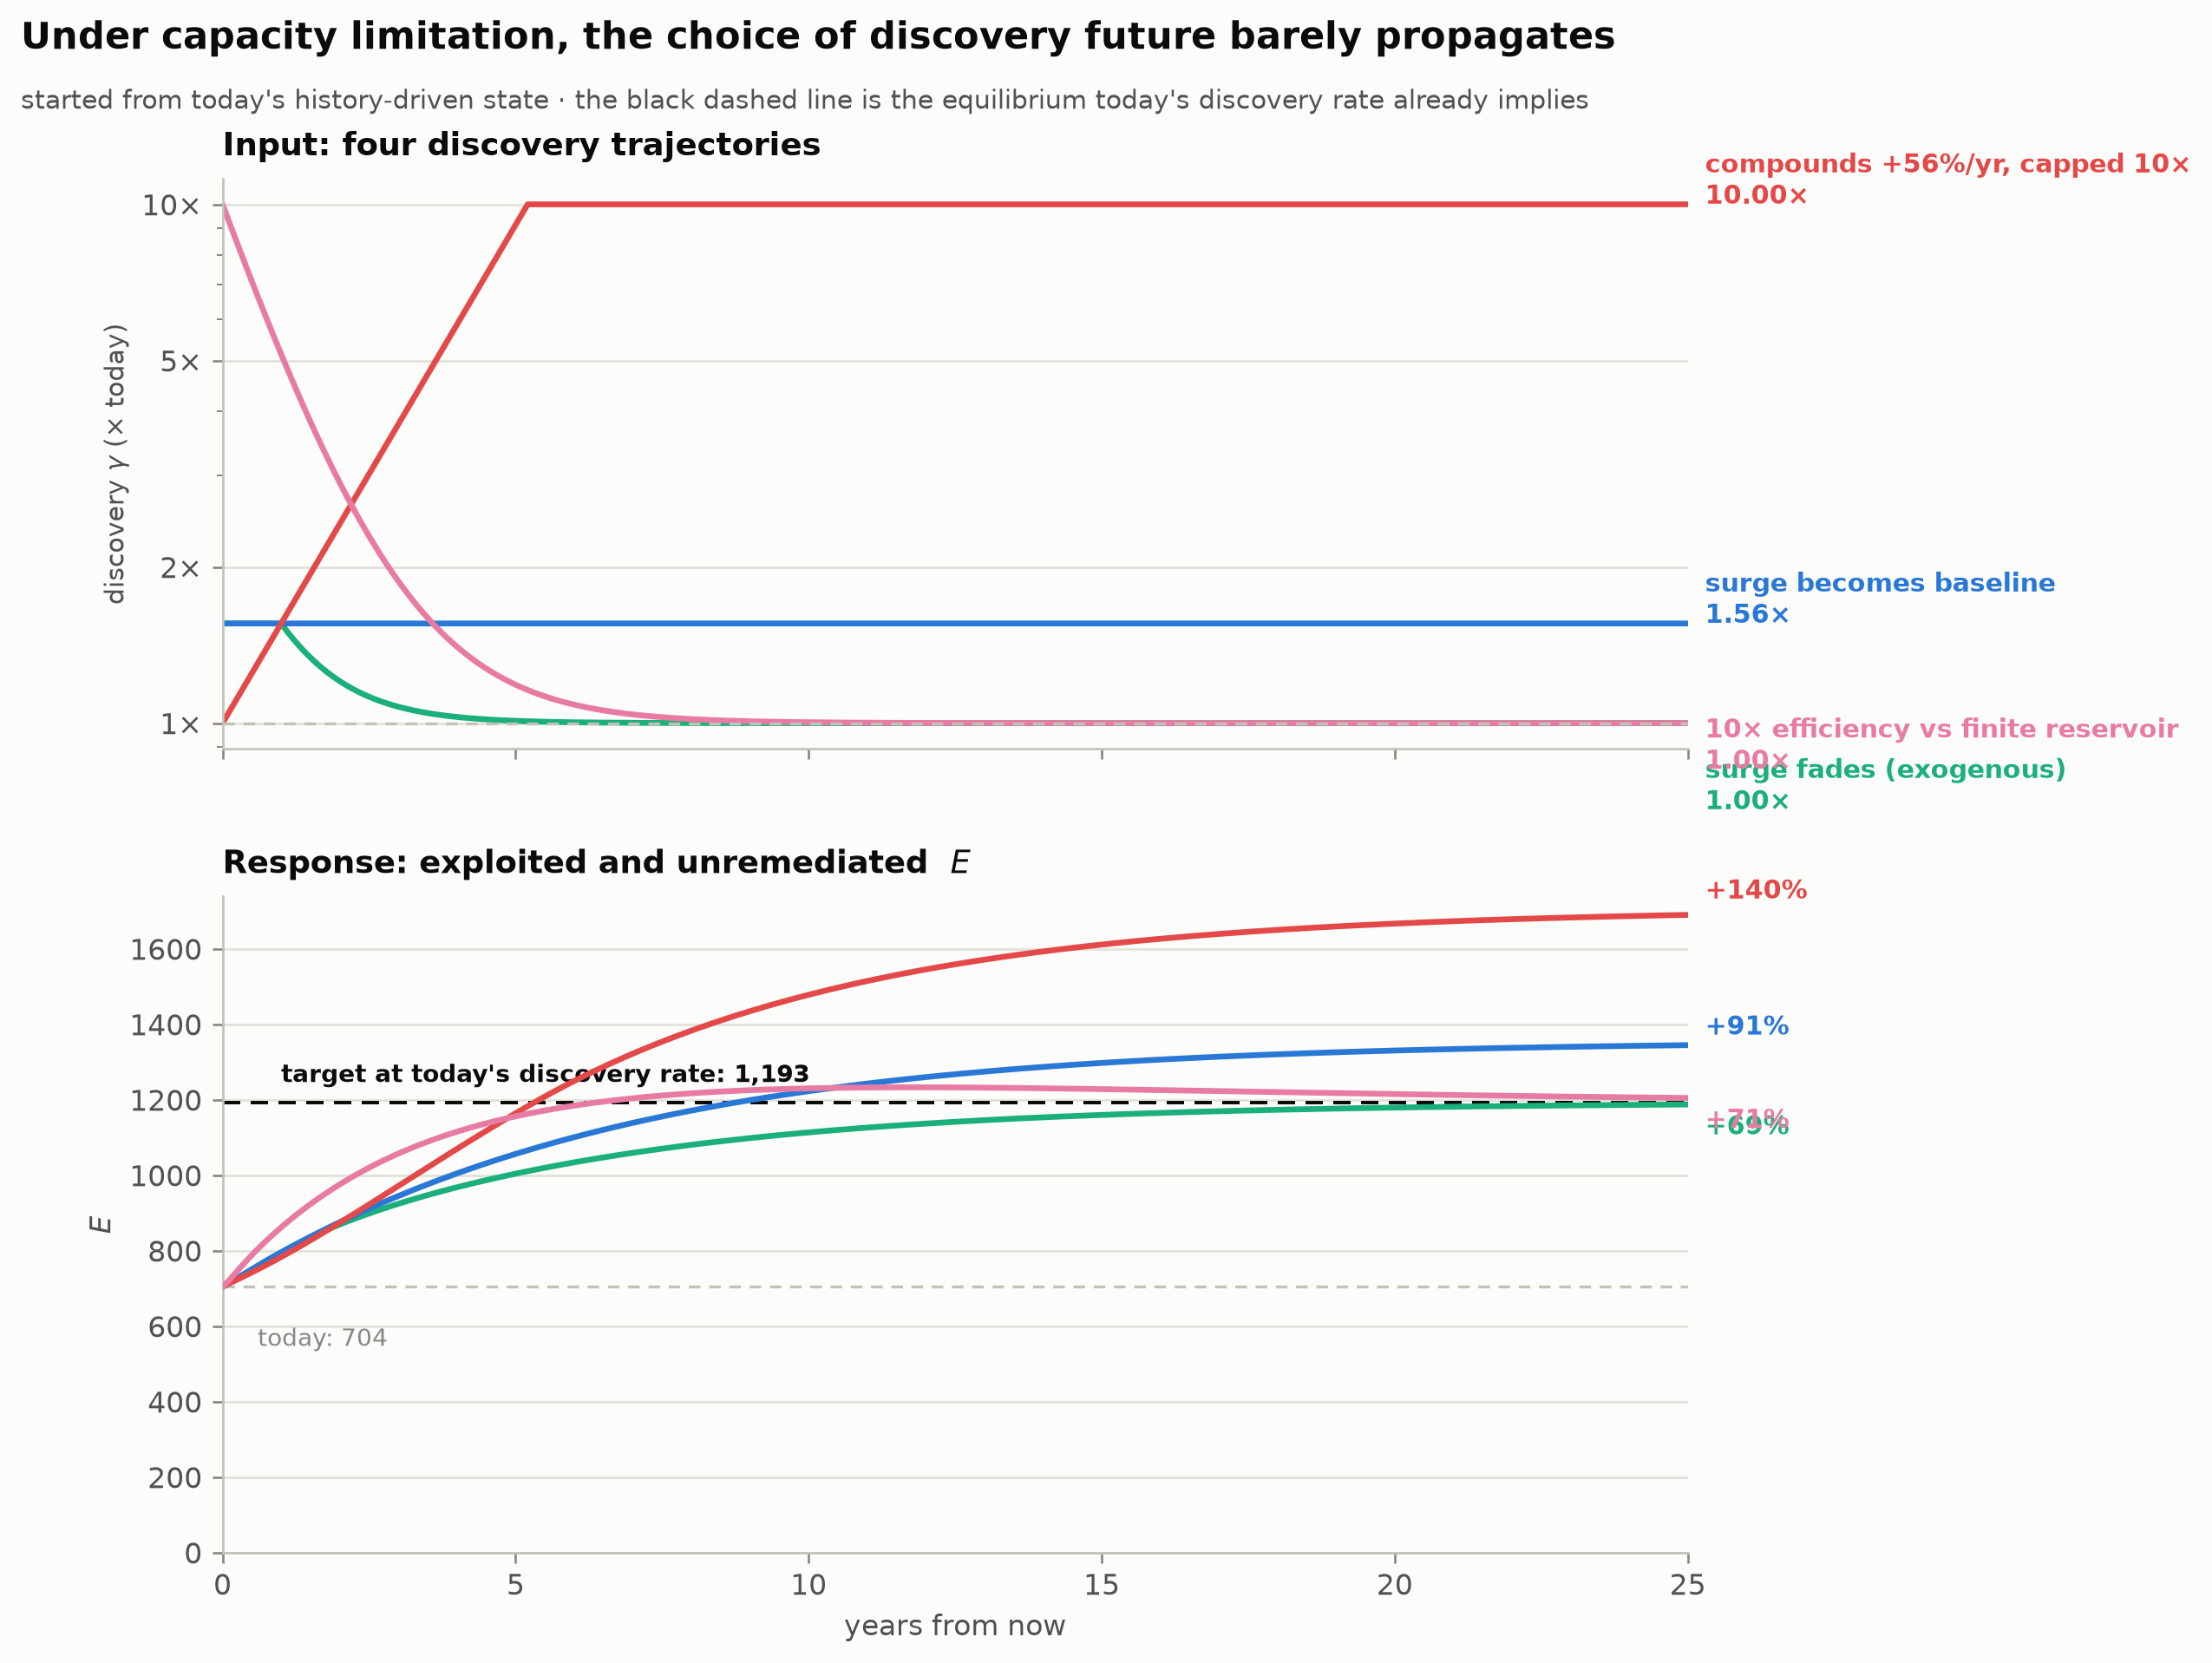

surge fades (exogenous)                gamma_end  1.00x   E     704 ->   1,187 (  +69%)   peak   1,187
surge becomes baseline                 gamma_end  1.56x   E     704 ->   1,345 (  +91%)   peak   1,345
compounds +56%/yr, capped 10×          gamma_end 10.00x   E     704 ->   1,690 ( +140%)   peak   1,690
10× efficiency vs finite reservoir     gamma_end  1.00x   E     704 ->   1,205 (  +71%)   peak   1,233


In [9]:
YEAR = DAYS_PER_YEAR
SURGE = MEAS["cve_per_day_91"] / MEAS["cve_per_day_364"]
T_SC = 25 * YEAR
U0, PSI_MULT = 1.0e6, 10.0          # remaining reservoir (lower bound) and AI efficiency jump
psi = GLOBAL.gamma / U0             # pinned so psi*U0 = today's discovery
sigma_S = GLOBAL.gamma              # replenishment implied by no observed deceleration


def reservoir_gamma():
    """gamma(t) from dU/dt = sigma_S - psi'U with psi' = 10x psi, tabulated then interpolated."""
    ts = np.linspace(0, T_SC, 4000)
    U = np.empty_like(ts)
    U[0] = U0
    for i in range(1, len(ts)):
        dt_ = ts[i] - ts[i - 1]
        U[i] = U[i - 1] + dt_ * (sigma_S - PSI_MULT * psi * U[i - 1])
    g = PSI_MULT * psi * U
    return lambda t: float(np.interp(t, ts, g))


SCENARIOS = [("surge fades (exogenous)", SERIES[2],
              lambda t: GLOBAL.gamma * (1 + (SURGE - 1) * (1.0 if t < YEAR else
                                                           np.exp(-(t - YEAR) / YEAR)))),
             ("surge becomes baseline", SERIES[0], lambda t: GLOBAL.gamma * SURGE),
             (f"compounds +{(SURGE - 1) * 100:.0f}%/yr, capped 10×", SERIES[7],
              lambda t: GLOBAL.gamma * min(10.0, SURGE ** (t / YEAR))),
             ("10× efficiency vs finite reservoir", SERIES[4], reservoir_gamma())]

start = TRANSIENT[GLOBAL.label]["state"]          # today, not the equilibrium
target = GLOBAL.fixed_point()
y0 = [start[k] for k in ("H", "N", "X", "Ep", "Er")]
runs = []
for name, color, gfn in SCENARIOS:
    t, traj = GLOBAL.integrate(T_SC, y0=y0, n=6000, gamma_fn=gfn)
    runs.append({"name": name, "color": color, "gfn": gfn, "t": t, "traj": traj,
                 "E": traj["Ep"] + traj["Er"]})

fig, (ax_in, ax_e) = plt.subplots(2, 1, figsize=(10.2, 8.0), sharex=True,
                                  gridspec_kw={"height_ratios": [1, 1.15]})
for r, dy in zip(runs, (-22, 8, 8, -8)):
    ax_in.plot(r["t"] / YEAR, [r["gfn"](x) / GLOBAL.gamma for x in r["t"]], color=r["color"], lw=2)
    label_end(ax_in, r["t"][-1] / YEAR, r["gfn"](r["t"][-1]) / GLOBAL.gamma,
              f"{r['name']}\n{r['gfn'](r['t'][-1]) / GLOBAL.gamma:.2f}×", r["color"], dy=dy)
ax_in.axhline(1.0, color=BASELINE, lw=1, ls=(0, (4, 3)))
ax_in.set_yscale("log")
ax_in.set_yticks([1, 2, 5, 10])
ax_in.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:g}×"))
ax_in.set_ylabel("discovery $\\gamma$ (× today)", fontsize=9)
ax_in.set_title("Input: four discovery trajectories")

ax_e.axhline(start["E"], color=BASELINE, lw=1, ls=(0, (4, 3)))
ax_e.axhline(target["E"], color=INK, lw=1.2, ls=(0, (5, 3)), zorder=2)
ax_e.annotate(f"target at today's discovery rate: {target['E']:,.0f}", xy=(1.0, target["E"]),
              xytext=(0, 5), textcoords="offset points", ha="left", va="bottom", fontsize=8.4,
              color=INK, fontweight="bold")
for r, dy in zip(runs, (-8, 6, 8, -8)):
    ax_e.plot(r["t"] / YEAR, r["E"], color=r["color"], lw=2, zorder=3)
    label_end(ax_e, r["t"][-1] / YEAR, r["E"][-1],
              f"{r['E'][-1] / start['E'] - 1:+.0%}", r["color"], dy=dy)
ax_e.set_title("Response: exploited and unremediated  $E$")
ax_e.set_xlabel("years from now")
ax_e.set_ylabel("$E$")
ax_e.set_xlim(0, T_SC / YEAR)
ax_e.set_ylim(0, None)
ax_e.annotate(f"today: {start['E']:,.0f}", xy=(0.6, start["E"]), xytext=(0, -14),
              textcoords="offset points", ha="left", va="top", fontsize=8.5, color=MUTED)

headline(fig, "Under capacity limitation, the choice of discovery future barely propagates",
         "started from today's history-driven state · the black dashed line is the equilibrium "
         "today's discovery rate already implies", y=0.995, y2=0.958)
fig.subplots_adjust(left=0.10, right=0.79, top=0.90, bottom=0.075, hspace=0.24)
plt.show()

for r in runs:
    mult = r["gfn"](r["t"][-1]) / GLOBAL.gamma
    print(f"{r['name']:<38} gamma_end {mult:5.2f}x   E {r['E'][0]:7,.0f} -> {r['E'][-1]:7,.0f} "
          f"({r['E'][-1] / r['E'][0] - 1:+6.0%})   peak {r['E'].max():7,.0f}")

## Visualization 8 — where the system is, against where it is heading

Each stock along the **measured** publication history from 2008 to now, continued at today's discovery rate to
show the approach to equilibrium. The vertical line marks the snapshot; the dashed line is each stock's target.

The two clocks are visible directly. $H$ and $N$ have residence times of 45 and 30 days, so they track the
rising inflow and stand slightly *above* their target — the target is computed at a trailing-year rate while
the current quarter is running hotter. $X$ and $E_r$ have residence times of 1,822 and 2,000 days and cannot
keep pace: today they sit at **50%** and **58%** of target globally. The exploited population as a whole is at
**59%** of its target, and would need roughly another decade at an unchanged discovery rate to arrive.

That is the qualification on every equilibrium number in this notebook: they are targets, not present states.
Where a figure reports an equilibrium, the transient value is shown beside it, and the two differ most for
exactly the quantities that matter most — the backlog and the exploited residue.

Analytically the displacement is $\mathrm{exit\ rate}/(\mathrm{exit\ rate} + r)$ for an inflow growing at
$r$. At the measured +32%/yr, a 30-day state sits at 97% of target and a 2,000-day state at 36%, which is what
the integration shows.

**Parameter justification.** Publication history is measured per year (NVD windows for global; publication
dates of the 693 CVEs for SharePoint), interpolated linearly between annual rates, and seeded in 2008 from the
equilibrium implied by that year's rate. The continuation holds $\gamma$ at the trailing-year value, which is
the same value used for every equilibrium in the notebook, so the gap shown is exactly the gap those
equilibria imply.

global ecosystem      H   today     10,945.7  target      9,523.9   115%  (already above target)
global ecosystem      N   today      7,288.4  target      6,345.3   115%  (already above target)
global ecosystem      X   today    191,546.6  target    385,393.5    50%  90% of target in 8 yr
global ecosystem      Er  today        678.5  target      1,165.5    58%  90% of target in 9 yr
Microsoft SharePoint  H   today         23.0  target          7.9   290%  (already above target)
Microsoft SharePoint  N   today         15.1  target          5.2   291%  (already above target)
Microsoft SharePoint  X   today        436.7  target        608.7    72%  90% of target in 9 yr
Microsoft SharePoint  Er  today         11.6  target         14.9    78%  90% of target in 5 yr


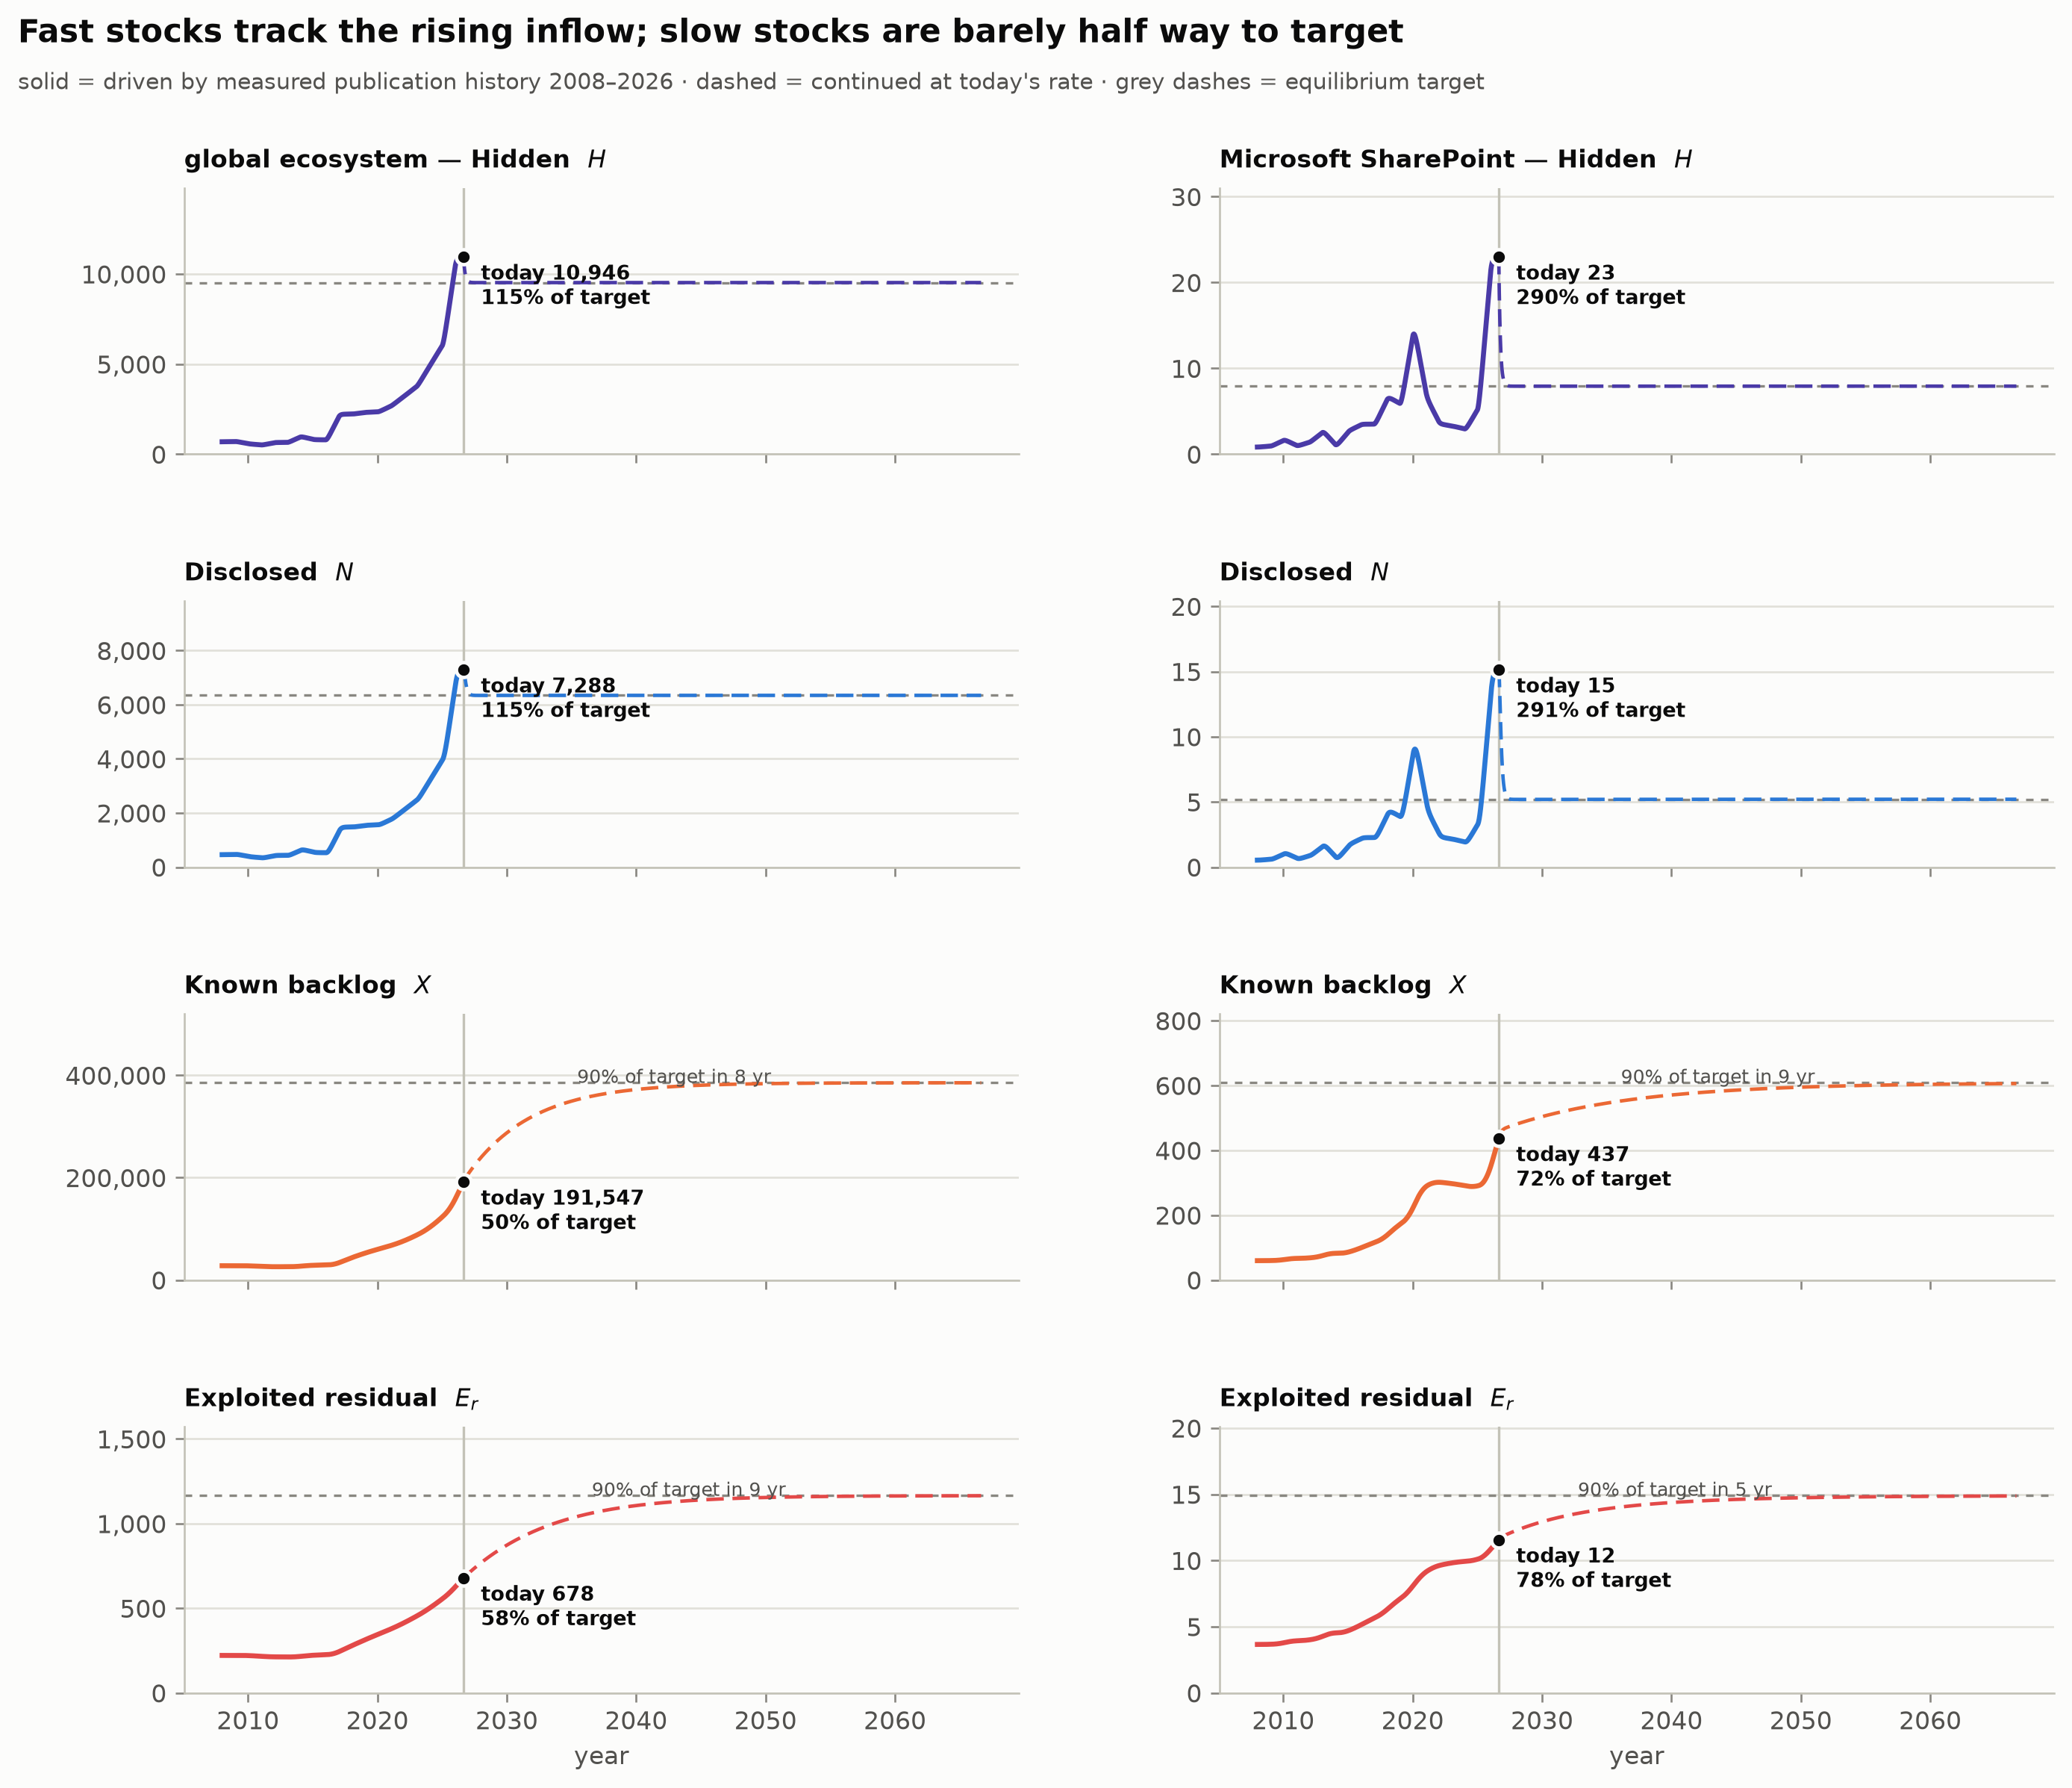

In [10]:
PANELS = [("H", "Hidden  $H$", SERIES[6]), ("N", "Disclosed  $N$", SERIES[0]),
          ("X", "Known backlog  $X$", SERIES[1]), ("Er", "Exploited residual  $E_r$", SERIES[7])]
CONTINUE_YEARS = 40

fig, axes = plt.subplots(4, 2, figsize=(11.6, 10.0), sharex=True)
for col, e in enumerate(ECOS):
    hist = TRANSIENT[e.label]
    fp = e.fixed_point()
    t2, traj2 = e.integrate(CONTINUE_YEARS * DAYS_PER_YEAR,
                            y0=[hist["state"][k] for k in ("H", "N", "X", "Ep", "Er")], n=3000)
    yr_hist = hist["year"]
    yr_cont = SNAPSHOT_YEAR + t2 / DAYS_PER_YEAR
    for row, (key, title, color) in enumerate(PANELS):
        ax = axes[row][col]
        ax.plot(yr_hist, hist["traj"][key], color=color, lw=2, zorder=4)
        ax.plot(yr_cont, traj2[key], color=color, lw=1.4, ls=(0, (5, 2.5)), zorder=3)
        ax.axhline(fp[key], color=MUTED, lw=1, ls=(0, (3, 3)), zorder=2)
        ax.axvline(SNAPSHOT_YEAR, color=BASELINE, lw=1, zorder=2)
        now = hist["state"][key]
        ax.plot(SNAPSHOT_YEAR, now, "o", ms=6, color=INK, mec=SURFACE, mew=1.4, zorder=6)
        ax.annotate(f"today {now:,.0f}\n{now / fp[key]:.0%} of target", xy=(SNAPSHOT_YEAR, now),
                    xytext=(7, -2), textcoords="offset points", ha="left", va="top", fontsize=8,
                    color=INK, fontweight="bold", zorder=6)
        i90 = int(np.argmax(traj2[key] >= 0.9 * fp[key])) if traj2[key][-1] >= 0.9 * fp[key] else -1
        if i90 > 0:
            ax.annotate(f"90% of target in {yr_cont[i90] - SNAPSHOT_YEAR:.0f} yr",
                        xy=(yr_cont[i90], traj2[key][i90]), xytext=(4, 6),
                        textcoords="offset points", ha="left", va="bottom", fontsize=7.6,
                        color=SECONDARY, zorder=6)
        ax.set_ylim(0, max(fp[key], traj2[key].max()) * 1.35)
        ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
        ax.set_title(f"{e.label} — {title}" if row == 0 else title, fontsize=10)
        if row == 3:
            ax.set_xlabel("year")
        print(f"{e.label:<22}{key:<3} today {now:>12,.1f}  target {fp[key]:>12,.1f}  "
              f"{now / fp[key]:>5.0%}" + (f"  90% of target in {yr_cont[i90] - SNAPSHOT_YEAR:.0f} yr"
                                          if i90 > 0 else "  (already above target)"))

headline(fig, "Fast stocks track the rising inflow; slow stocks are barely half way to target",
         "solid = driven by measured publication history 2008–2026 · dashed = continued at today's rate · "
         "grey dashes = equilibrium target", y=0.995, y2=0.968)
fig.subplots_adjust(left=0.085, right=0.985, top=0.90, bottom=0.06, wspace=0.24, hspace=0.55)
plt.show()

## Visualization 9 — five interventions at equal effort

Each control receives the same 30% relative improvement in one parameter, applied to an ecosystem at its
measured equilibrium, with effect plotted against time-to-90%.

The ranking is led by completeness and decommissioning, while patch delay produces almost nothing — a 30% cut in $\tau$ moves $E^*$ by 0.4%, against 10.5% for a 30% improvement in the
ever-patched share. Surface reduction retains a moderate effect because it reduces weaponizable supply, but that
effect is damped by the throughput cap: removing supply that attackers were not converting has no consequence.

Time constants differ by two orders of magnitude, and the ordering by speed is nearly the reverse of the
ordering by effect. Controls acting on the exploited compartment directly ($\tau$, $\rho$, $\delta$) act within
months; controls acting through stocks ($f$ via the residual compartment, $\lambda$, $\phi$) take years to
decades.

**Parameter justification.** "Equal effort" is a 30% relative change in a single parameter — a normalization,
not a cost model. Both ecosystems start at their measured fixed points, so responses are attributable to the
change alone. The 30-year horizon is set by the slowest response present.

global ecosystem      ever-patched share +30%      target -10.5%   at 5 yr from today  -7.1%   90% of the change at  13.8 yr
global ecosystem      decommission $\lambda$ +30%  target -22.6%   at 5 yr from today -14.1%   90% of the change at  15.6 yr
global ecosystem      surface $\varepsilon$ −30%   target -12.5%   at 5 yr from today  -9.7%   90% of the change at  11.9 yr
global ecosystem      patch delay $\tau$ −30%      target  -0.4%   at 5 yr from today  -0.5%   90% of the change at   0.9 yr
global ecosystem      retirement $\phi$ +30%       target  -3.4%   at 5 yr from today  -0.9%   90% of the change at  21.8 yr
Microsoft SharePoint  ever-patched share +30%      target -10.5%   at 5 yr from today  -6.9%   90% of the change at  13.0 yr


Microsoft SharePoint  decommission $\lambda$ +30%  target -22.5%   at 5 yr from today -15.7%   90% of the change at  12.6 yr
Microsoft SharePoint  surface $\varepsilon$ −30%   target -12.6%   at 5 yr from today  -9.3%   90% of the change at  10.5 yr
Microsoft SharePoint  patch delay $\tau$ −30%      target  -0.5%   at 5 yr from today  -0.5%   90% of the change at   0.5 yr
Microsoft SharePoint  retirement $\phi$ +30%       target  -5.2%   at 5 yr from today  -1.0%   90% of the change at  28.7 yr


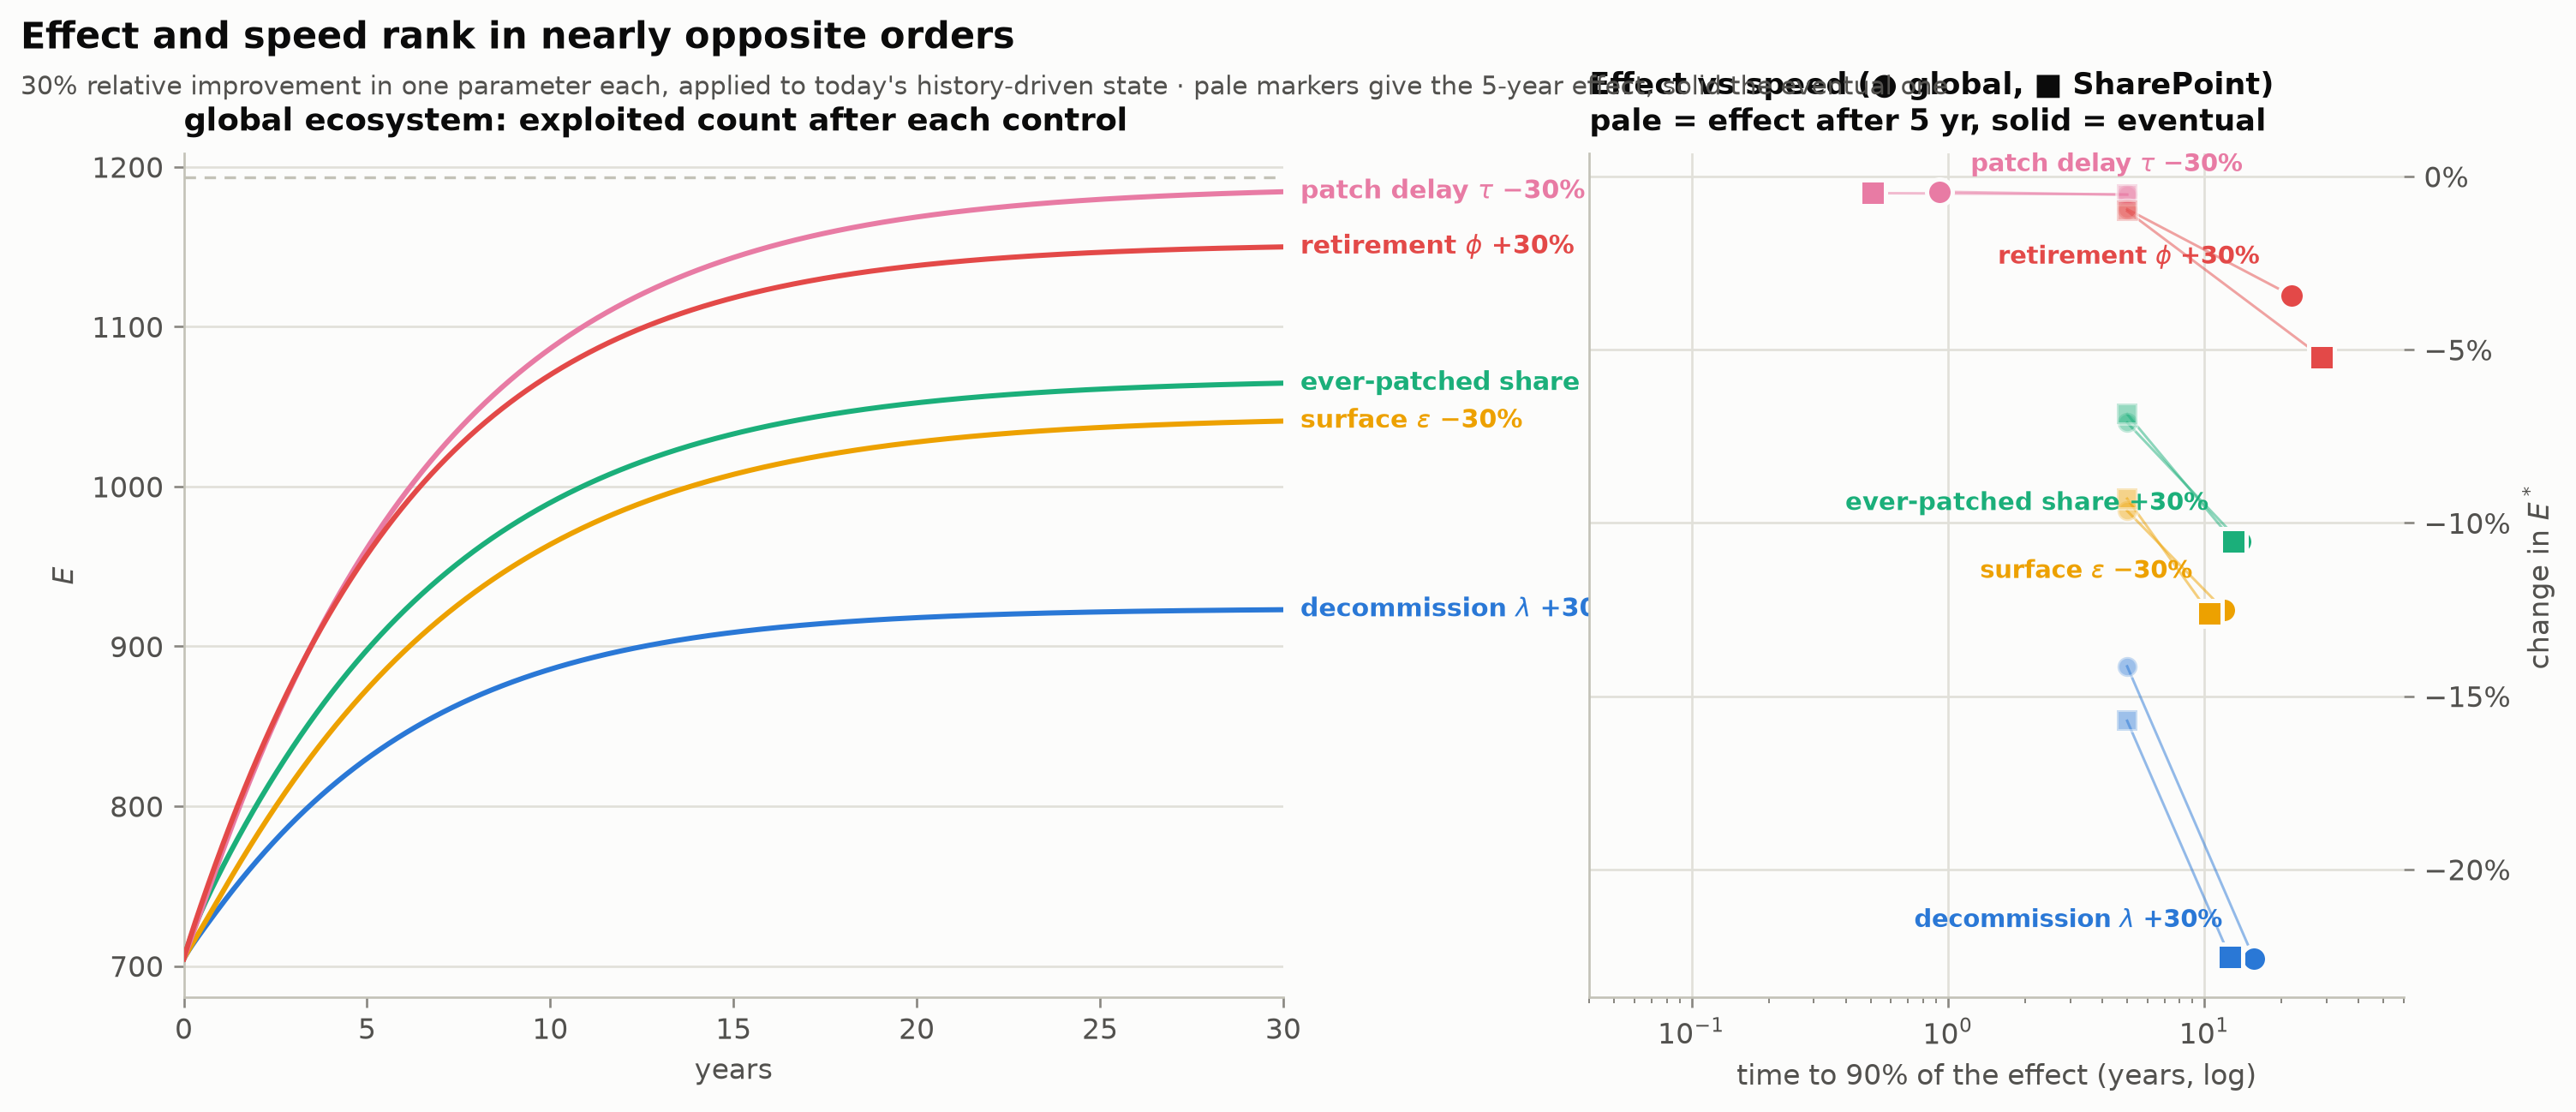

In [11]:
T_POL = 30 * DAYS_PER_YEAR
POLICIES = [("ever-patched share +30%", dict(f_fix=None), SERIES[2]),
            ("decommission $\\lambda$ +30%", dict(lam=None), SERIES[0]),
            ("surface $\\varepsilon$ −30%", dict(eps=0.7), SERIES[3]),
            ("patch delay $\\tau$ −30%", dict(tau=TAU_DAYS * 0.7), SERIES[4]),
            ("retirement $\\phi$ +30%", dict(phi=None), SERIES[7])]

fig, (ax_t, ax_s) = plt.subplots(1, 2, figsize=(12.6, 5.4), gridspec_kw={"width_ratios": [1.35, 1]})
results = {}
for e in ECOS:
    st = e.fixed_point()
    today = TRANSIENT[e.label]["state"]
    y0 = [today[k] for k in ("H", "N", "X", "Ep", "Er")]      # start from where the system is
    rows = []
    for name, kw, color in POLICIES:
        kw = dict(kw)
        if "f_fix" in kw:
            kw["f_fix"] = min(1.0, e.f_fix * 1.3)
        if "lam" in kw:
            kw["lam"] = e.lam * 1.3
        if "phi" in kw:
            kw["phi"] = e.phi * 1.3
        target = e.fixed_point(**kw)["E"]
        # integrate the perturbed system by editing the ecosystem where the change is a field
        ee = e
        if "tau" in kw:
            ee = replace(e, tau=kw["tau"])
        if "f_fix" in kw:
            ee = replace(e, f_fix=kw["f_fix"])
        if kw.get("lam"):
            ee = replace(e, lam=kw["lam"])
        if kw.get("phi"):
            ee = replace(e, phi=kw["phi"])
        wm = kw.get("eps", 1.0)
        t, traj = ee.integrate(T_POL, y0=y0, n=5000, wmult=wm)
        E = traj["Ep"] + traj["Er"]
        base_t, base_traj = e.integrate(T_POL, y0=y0, n=5000)      # do-nothing from today
        base_E = base_traj["Ep"] + base_traj["Er"]
        i5 = int(np.argmin(np.abs(t - HORIZON * DAYS_PER_YEAR)))
        gain = st["E"] - target
        t90 = t[int(np.argmax(np.abs(E - base_E) >= 0.9 * abs(gain)))] if abs(gain) > 1e-9 else np.nan
        rows.append({"name": name, "color": color, "t": t, "E": E, "final": target,
                     "d": target / st["E"] - 1, "d5": E[i5] / base_E[i5] - 1, "t90": t90})
        print(f"{e.label:<22}{name.replace(chr(92) * 2, chr(92)):<28} target "
              f"{target / st['E'] - 1:>+6.1%}   at {HORIZON:.0f} yr from today "
              f"{rows[-1]['d5']:>+6.1%}   90% of the change at {t90 / DAYS_PER_YEAR:>5.1f} yr")
    results[e.label] = rows

for r in results[GLOBAL.label]:
    ax_t.plot(r["t"] / DAYS_PER_YEAR, r["E"], color=r["color"], lw=1.8, zorder=3)
    label_end(ax_t, r["t"][-1] / DAYS_PER_YEAR, r["E"][-1], r["name"], r["color"])
ax_t.axhline(GLOBAL.fixed_point()["E"], color=BASELINE, lw=1, ls=(0, (4, 3)))
ax_t.set_title(f"{GLOBAL.label}: exploited count after each control")
ax_t.set_xlabel("years")
ax_t.set_ylabel("$E$")
ax_t.set_xlim(0, T_POL / DAYS_PER_YEAR)

for marker, e in zip(("o", "s"), ECOS):
    for r in results[e.label]:
        ax_s.plot(max(r["t90"] / DAYS_PER_YEAR, 0.05), 100 * r["d"], marker, ms=9, color=r["color"],
                  mec=SURFACE, mew=1.5, zorder=4)
        ax_s.plot(HORIZON, 100 * r["d5"], marker, ms=7, color=r["color"], mec=SURFACE, mew=1.2,
                  alpha=0.45, zorder=4)
        ax_s.plot([HORIZON, max(r["t90"] / DAYS_PER_YEAR, 0.05)], [100 * r["d5"], 100 * r["d"]],
                  color=r["color"], lw=0.9, alpha=0.5, zorder=3)
        if e is GLOBAL:
            slow = r["t90"] / DAYS_PER_YEAR > 3
            ax_s.annotate(r["name"], xy=(max(r["t90"] / DAYS_PER_YEAR, 0.05), 100 * r["d"]),
                          xytext=(-11, 9) if slow else (11, 5), textcoords="offset points",
                          ha="right" if slow else "left", va="bottom", fontsize=8.6,
                          color=r["color"], fontweight="bold", zorder=5)
ax_s.set_xscale("log")
ax_s.set_xlim(0.04, 60)
ax_s.set_title(f"Effect vs speed (● global, ■ SharePoint)\n"
               f"pale = effect after {HORIZON:.0f} yr, solid = eventual", fontsize=10.5)
ax_s.set_xlabel("time to 90% of the effect (years, log)")
ax_s.set_ylabel("change in $E^*$")
ax_s.yaxis.set_label_position("right")
ax_s.yaxis.tick_right()
ax_s.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))
ax_s.grid(True, axis="both")
ax_s.set_axisbelow(True)

headline(fig, "Effect and speed rank in nearly opposite orders",
         "30% relative improvement in one parameter each, applied to today's history-driven state · "
         f"pale markers give the {HORIZON:.0f}-year effect, solid the eventual one", y=0.995, y2=0.952)
fig.subplots_adjust(left=0.068, right=0.925, top=0.875, bottom=0.115, wspace=0.32)
plt.show()

## Visualization 10 — the patch-delay / attack-surface plane

The two parameters a security programme most directly controls, swept together, with realized exploitation
contoured. This is the plane most remediation policy is written in, and the result is largely negative.

Both levers move realized exploitation weakly. Patch delay barely appears: its contours are almost vertical
lines, because $\tau$ acts on the 26% remediable compartment only. Surface reduction has more purchase but is
damped by the throughput cap — removing supply attackers were not converting changes nothing. Neither lever,
across its full plausible range, moves realized exploitation by as much as a 3× change in throughput.

**Parameter justification.** $\tau$ spans 0–180 days: zero is instantaneous patch start, 180 days is roughly
8.6× CISA's 21-day median deadline and above Veracode's 252-day average fix time only for the worst quartile.
$\varepsilon$ spans 0.05–1.0 as a multiplier on the measured reachability share (0.75 global, 0.759
SharePoint), marked. All else at measured values.

global ecosystem       tau-eps plane spans 0.133x to 1.017x   3x throughput 1.80x
Microsoft SharePoint   tau-eps plane spans 0.134x to 1.019x   3x throughput 1.74x


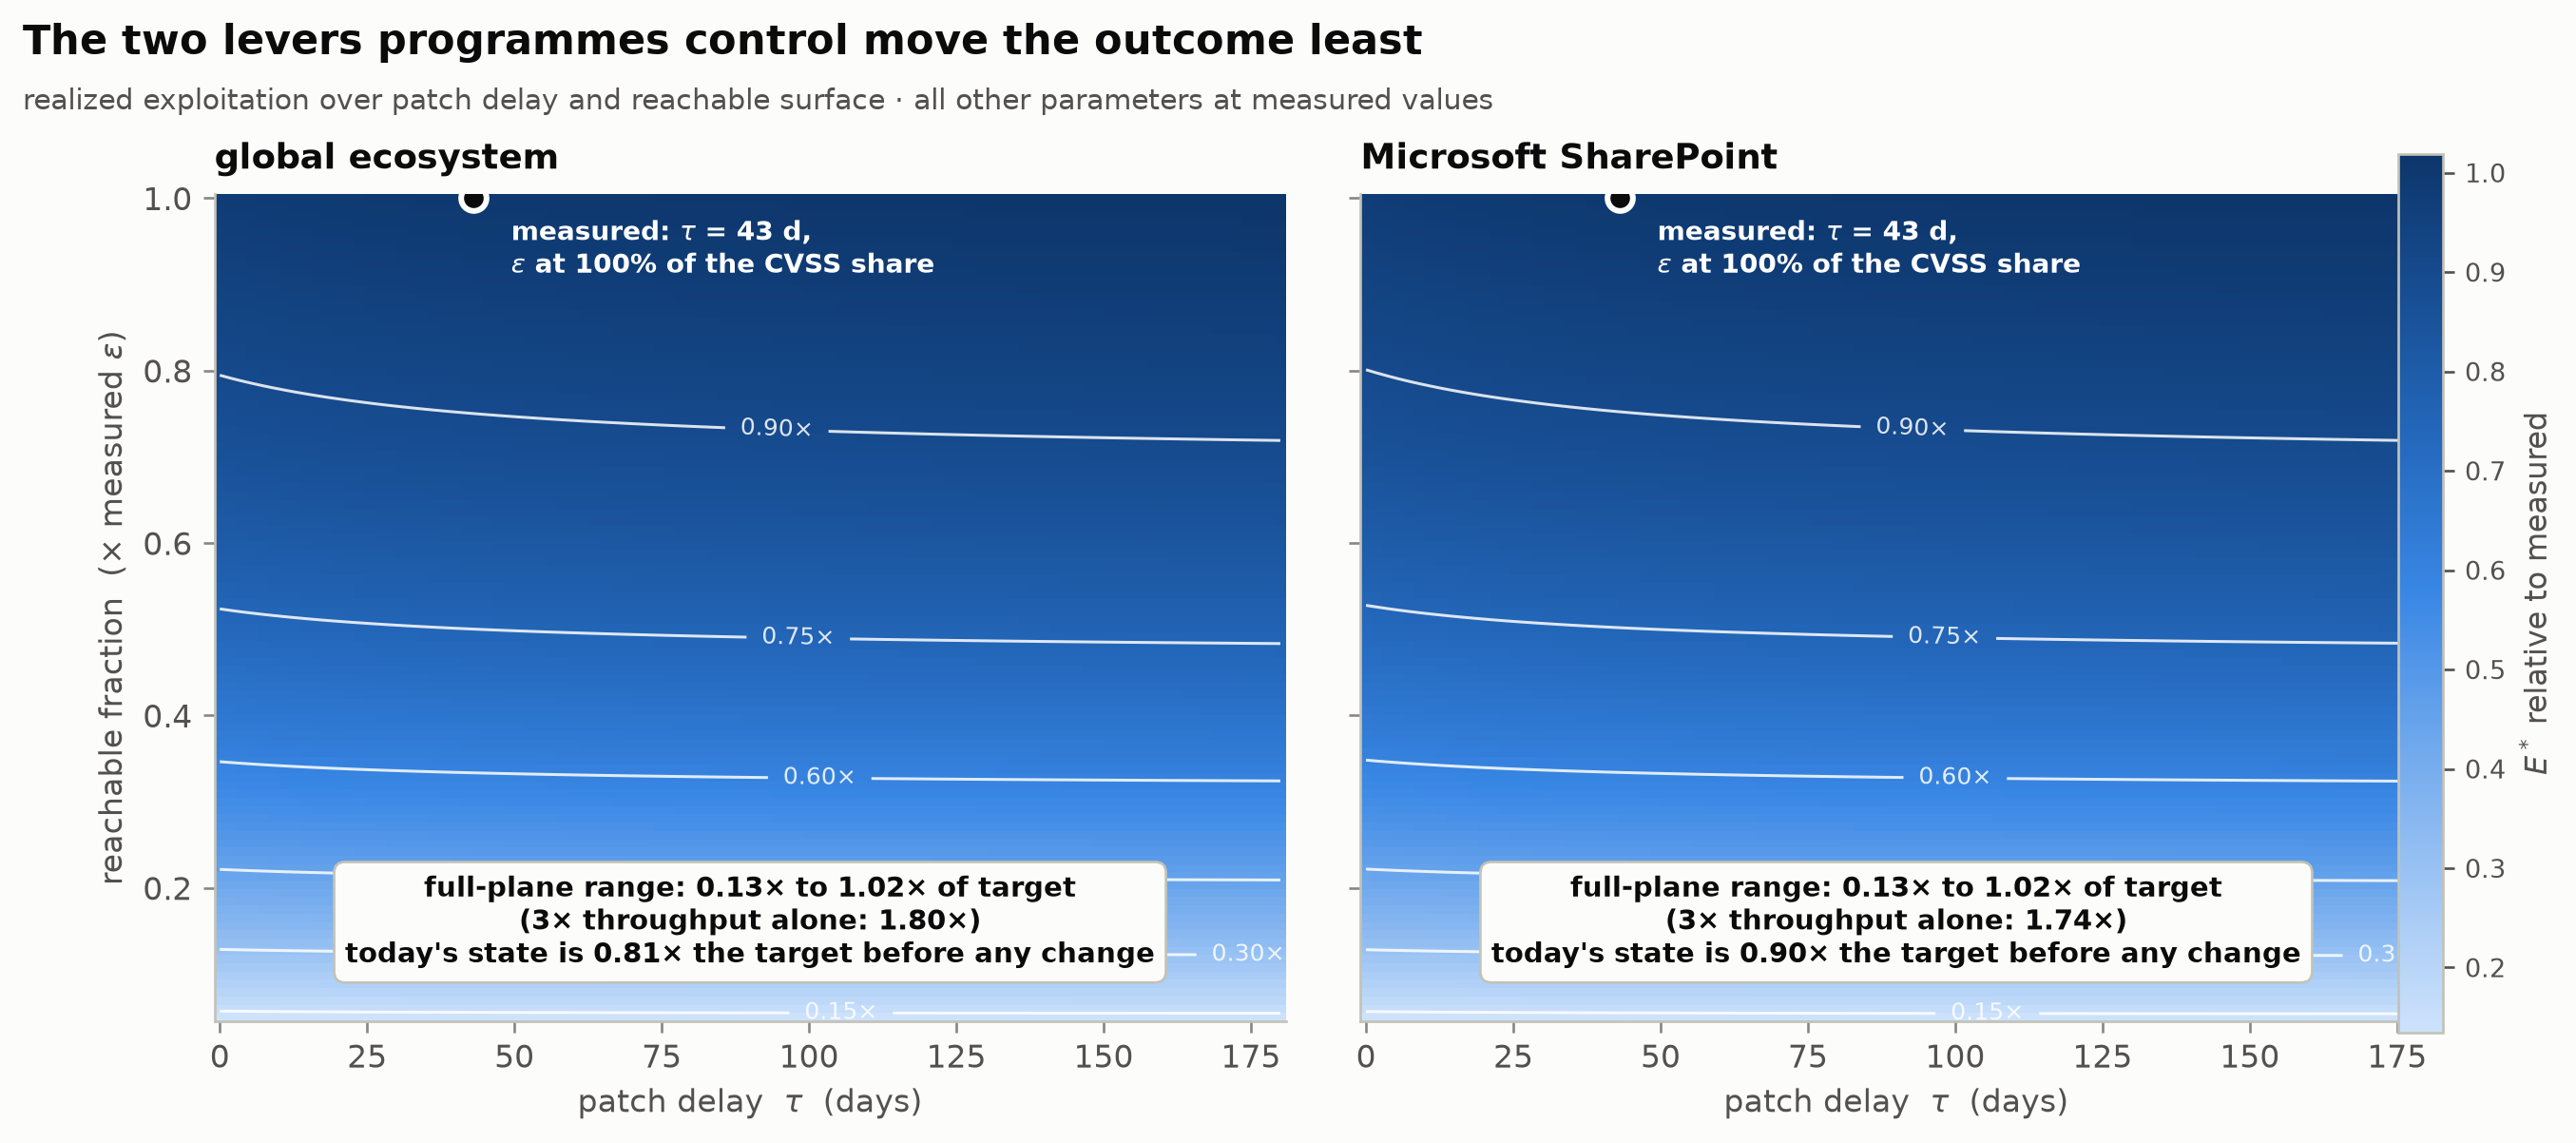

In [12]:
TAU_G, EPS_G = np.linspace(0.0, 180.0, 100), np.linspace(0.05, 1.0, 100)
TT, EE = np.meshgrid(TAU_G, EPS_G)
cmap = mpl.colors.LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0), sharey=True)
for ax, e in zip(axes, ECOS):
    base = e.fixed_point()["E"]
    field = np.vectorize(lambda ta, ep: e.fixed_point(tau=ta, eps=ep)["E"])(TT, EE) / base
    mesh = ax.pcolormesh(TT, EE, field, cmap=cmap, shading="auto",
                         norm=mpl.colors.Normalize(vmin=field.min(), vmax=field.max()))
    cs = ax.contour(TT, EE, field, levels=6, colors="white", linewidths=0.9, alpha=0.85)
    ax.clabel(cs, fmt=lambda v: f"{v:.2f}×", fontsize=7.5, colors="white")
    ax.plot(e.tau, 1.0, "o", ms=8, color=INK, mec="white", mew=1.8, zorder=5)
    ax.annotate(f"measured: $\\tau$ = {e.tau:.0f} d,\n$\\varepsilon$ at 100% of the "
                f"CVSS share", xy=(e.tau, 1.0), xytext=(12, -6), textcoords="offset points",
                ha="left", va="top", fontsize=8.4, color="white", fontweight="bold", zorder=6)
    near = from_today(e, HORIZON)[2][-1]
    ax.annotate(f"full-plane range: {field.min():.2f}× to {field.max():.2f}× of target\n"
                f"(3× throughput alone: {e.fixed_point(cmult=3)['E'] / base:.2f}×)\n"
                f"today's state is {near / base:.2f}× the target before any change",
                xy=(0.5, 0.06), xycoords="axes fraction", ha="center", va="bottom", fontsize=8.6,
                color=INK, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.4", facecolor=SURFACE, edgecolor=BASELINE, lw=0.8),
                zorder=6)
    ax.set_title(e.label)
    ax.set_xlabel("patch delay  $\\tau$  (days)")
    ax.grid(False)
    print(f"{e.label:<22} tau-eps plane spans {field.min():.3f}x to {field.max():.3f}x   "
          f"3x throughput {e.fixed_point(cmult=3)['E'] / base:.2f}x")
axes[0].set_ylabel("reachable fraction  (× measured $\\varepsilon$)")
cbar = fig.colorbar(mesh, ax=axes, fraction=0.035, pad=0.015)
cbar.set_label("$E^*$ relative to measured", fontsize=9.5, color=SECONDARY)
cbar.ax.tick_params(labelsize=8, colors=SECONDARY)
cbar.outline.set_edgecolor(BASELINE)

headline(fig, "The two levers programmes control move the outcome least",
         "realized exploitation over patch delay and reachable surface · all other parameters at "
         "measured values", y=0.995, y2=0.945)
fig.subplots_adjust(left=0.075, right=0.885, top=0.845, bottom=0.12, wspace=0.07)
plt.show()

## Visualization 11 — phase portrait

$H$, $N$ and $E_p$ relax on 45-, 30- and ~124-day timescales against ~1,820 days for $X$ and 2,000 for
$E_r$, so the slow dynamics reduce to the $(X, E_r)$ plane with the fast states on their manifolds.

The geometry is simple. The $\dot X = 0$ nullcline is **vertical**: the backlog's inflow $\mu N$ does not
depend on $X$ once $N$ is on its manifold, so $X$ has a single target independent of exploitation. The $\dot E_r = 0$ nullcline rises with $X$ and **flattens**, because realized exploitation
saturates at $C$. They cross once, and the crossing is stable: the system is linear apart from a
monotone saturating conversion term, so nothing in the structure can produce a second equilibrium.

The flattening is the throughput cap made visible. Past the knee, adding backlog moves the exploited residue
hardly at all.

**Parameter justification.** Axes span 0–2× the equilibrium $X$ and 0–2× the equilibrium $E_r$ for each
ecosystem, so both panels show the same relative neighbourhood of their own fixed points. The reduction's
error is bounded by the timescale ratio (≥14:1 between $E_p$ and $E_r$ here, wider for $H$ and $N$).

global ecosystem       X-nullcline at      385,394 (equilibrium      385,394)   Er*   1,165.5


Microsoft SharePoint   X-nullcline at          609 (equilibrium          609)   Er*      14.9


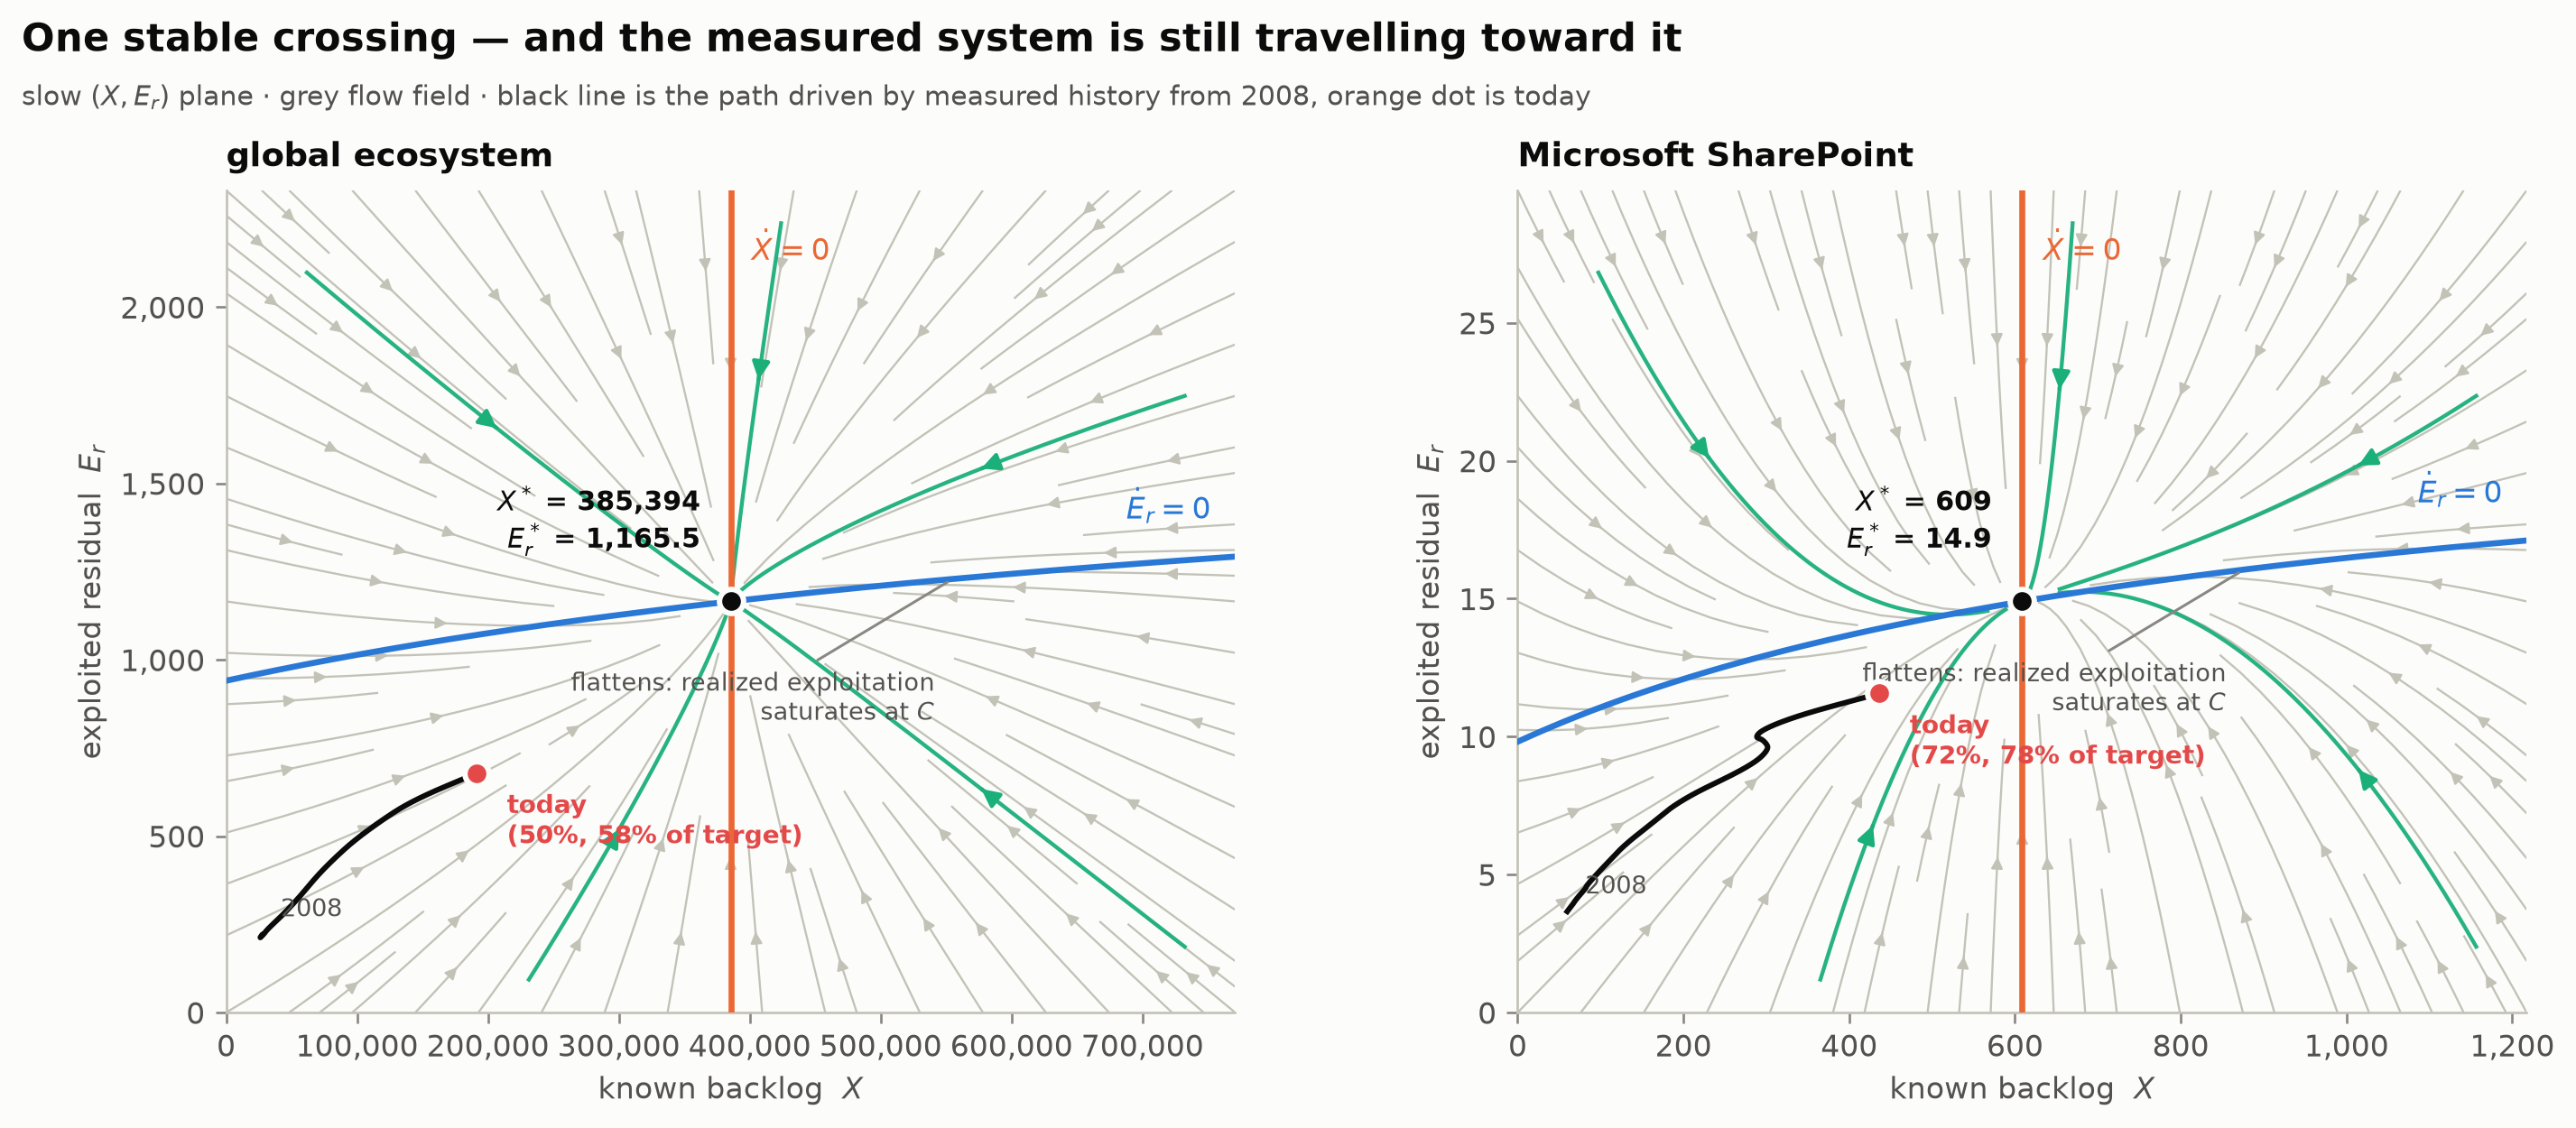

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.2))
for ax, e in zip(axes, ECOS):
    fp = e.fixed_point()
    b_h, b_n, b_x = e.hazards
    H_m, N_m = fp["H"], fp["N"]                     # fast states on their manifolds
    x_max, e_max = 2.0 * fp["X"], 2.0 * fp["Er"]

    def field2(X, Er):
        P = b_h * H_m + b_n * N_m + b_x * X          # gross opportunity rate
        I = e.C * P / (e.C + P)                      # realized, capped
        conv = I / P                                 # only the converted share leaves the pool
        return e.mu * N_m - e.phi * X - conv * b_x * X, (1 - e.f_fix) * I - e.lam * Er

    gx, ge = np.meshgrid(np.linspace(1e-6, x_max, 24), np.linspace(1e-6, e_max, 24))
    u, v = field2(gx, ge)
    ax.streamplot(gx, ge, u, v, color=BASELINE, linewidth=0.7, density=1.1, arrowsize=0.8, zorder=1)

    # conv depends on X, so the X-nullcline is a root rather than a closed form
    x_null = brentq(lambda X: field2(X, 0.0)[0], 1e-6, 50 * fp["X"], xtol=1e-9)
    ax.axvline(x_null, color=SERIES[1], lw=2, zorder=4)
    ax.annotate(r"$\dot X = 0$", xy=(x_null, e_max * 0.93), xytext=(7, 0),
                textcoords="offset points", ha="left", va="center", fontsize=10, color=SERIES[1],
                fontweight="bold", zorder=6)
    xs = np.linspace(0, x_max, 400)
    P = b_h * H_m + b_n * N_m + b_x * xs
    er_null = (1 - e.f_fix) * (e.C * P / (e.C + P)) / e.lam
    ax.plot(xs, er_null, color=SERIES[0], lw=2, zorder=4)
    ax.annotate(r"$\dot E_r = 0$", xy=(xs[-1], er_null[-1]), xytext=(-8, 10),
                textcoords="offset points", ha="right", va="bottom", fontsize=10, color=SERIES[0],
                fontweight="bold", zorder=6)
    ax.annotate("flattens: realized exploitation\nsaturates at $C$", xy=(x_max * 0.72,
                np.interp(x_max * 0.72, xs, er_null)), xytext=(-6, -30),
                textcoords="offset points", ha="right", va="top", fontsize=8.2, color=SECONDARY,
                arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.9), zorder=6)

    for fx, fy in ((0.08, 0.9), (0.55, 0.96), (0.95, 0.75), (0.95, 0.08), (0.3, 0.04)):
        y0 = [H_m, N_m, fx * x_max, fp["Ep"], fy * e_max]
        t, tr = e.integrate(9000.0, y0=y0, n=2500)
        ax.plot(tr["X"], tr["Er"], color=SERIES[2], lw=1.3, alpha=0.95, zorder=3)
        j = 300        # mid-path, where the direction of motion is unambiguous
        ax.annotate("", xy=(tr["X"][j + 1], tr["Er"][j + 1]), xytext=(tr["X"][j], tr["Er"][j]),
                    arrowprops=dict(arrowstyle="-|>", color=SERIES[2], lw=1.3, mutation_scale=12),
                    zorder=3)
    hist = TRANSIENT[e.label]
    ax.plot(hist["traj"]["X"], hist["traj"]["Er"], color=INK, lw=1.8, zorder=6)
    ax.plot(hist["state"]["X"], hist["state"]["Er"], "o", ms=8, color=SERIES[7], mec=SURFACE,
            mew=1.8, zorder=7)
    ax.annotate(f"today\n({hist['state']['X'] / fp['X']:.0%}, {hist['state']['Er'] / fp['Er']:.0%} "
                f"of target)", xy=(hist["state"]["X"], hist["state"]["Er"]), xytext=(10, -6),
                textcoords="offset points", ha="left", va="top", fontsize=8.4, color=SERIES[7],
                fontweight="bold", zorder=7)
    ax.annotate("2008", xy=(hist["traj"]["X"][0], hist["traj"]["Er"][0]), xytext=(6, 6),
                textcoords="offset points", fontsize=8, color=SECONDARY, zorder=7)
    ax.plot(fp["X"], fp["Er"], "o", ms=8, color=INK, mec=SURFACE, mew=1.8, zorder=7)
    ax.annotate(f"$X^*$ = {fp['X']:,.0f}\n$E_r^*$ = {fp['Er']:,.1f}", xy=(fp["X"], fp["Er"]),
                xytext=(-10, 14), textcoords="offset points", ha="right", va="bottom", fontsize=9,
                color=INK, fontweight="bold", zorder=7)
    ax.set_title(e.label)
    ax.set_xlabel("known backlog  $X$")
    ax.set_ylabel("exploited residual  $E_r$")
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, e_max)
    ax.grid(False)
    ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
    print(f"{e.label:<22} X-nullcline at {x_null:>12,.0f} (equilibrium {fp['X']:>12,.0f})   "
          f"Er* {fp['Er']:>9,.1f}")

headline(fig, "One stable crossing — and the measured system is still travelling toward it",
         "slow $(X, E_r)$ plane · grey flow field · black line is the path driven by measured history "
         "from 2008, orange dot is today", y=0.995, y2=0.945)
fig.subplots_adjust(left=0.085, right=0.985, top=0.845, bottom=0.115, wspace=0.28)
plt.show()

## Visualization 12 — the fast manifold in 3-D, rotated

The reduction used in Visualization 11 asserted that $H$, $N$ and $E_p$ are fast enough to eliminate. This
shows it: trajectories of the full system in $(N, X, E_r)$, with the camera sweeping 360 viewpoints of azimuth
about the vertical axis, written to `ODEtoVuln_daily_phase3d.mp4`.

Every orbit collapses onto the translucent sheet within weeks and then travels along it to the fixed point.
The sheet is the $\dot N = 0$ surface with $H$ at its own fixed point, $N = \delta_d H^* / (\mu + \text{conv}\,
\beta_n)$. It is a plane independent of both $X$ and $E_r$, because the disclosed pool's balance references
neither. (Away from $H^*$ the surface tilts with $H$; the figure holds $H$ on its manifold so the $N$ collapse
is isolated.) That independence is what licenses the
reduction, and it is why the phase portrait's $\dot X = 0$ nullcline is a vertical line rather than a curve.

The black line is the path driven by measured publication history from 2008, with today marked. It confirms
the separation empirically: $N$ stays within −8.8% to +1.9% of the nullcline relation across the whole period,
while $X$ and $E_r$ remain far from the fixed point — 52% and 61% of target. Being *on* the nullcline is a
statement about $N$ tracking $H$ with a 30-day lag, not about the system having arrived anywhere.

**Parameter justification.** Global measured parameters. Initial conditions are spread across the box in all
three plotted coordinates, with $H$ and $E_p$ started on their own manifolds so the figure isolates the $N$
collapse. 360 frames at 30 fps.

wrote ODEtoVuln_daily_phase3d.mp4 — 360 frames, 12.0 s, 4.55 MB
plane drawn at N = 6,345.3 (this is dN/dt = 0, not N = 0); equilibrium N* = 6,345.3
today: N 7,288 (115% of target), X 191,547 (50%), Er 678.5 (58%)


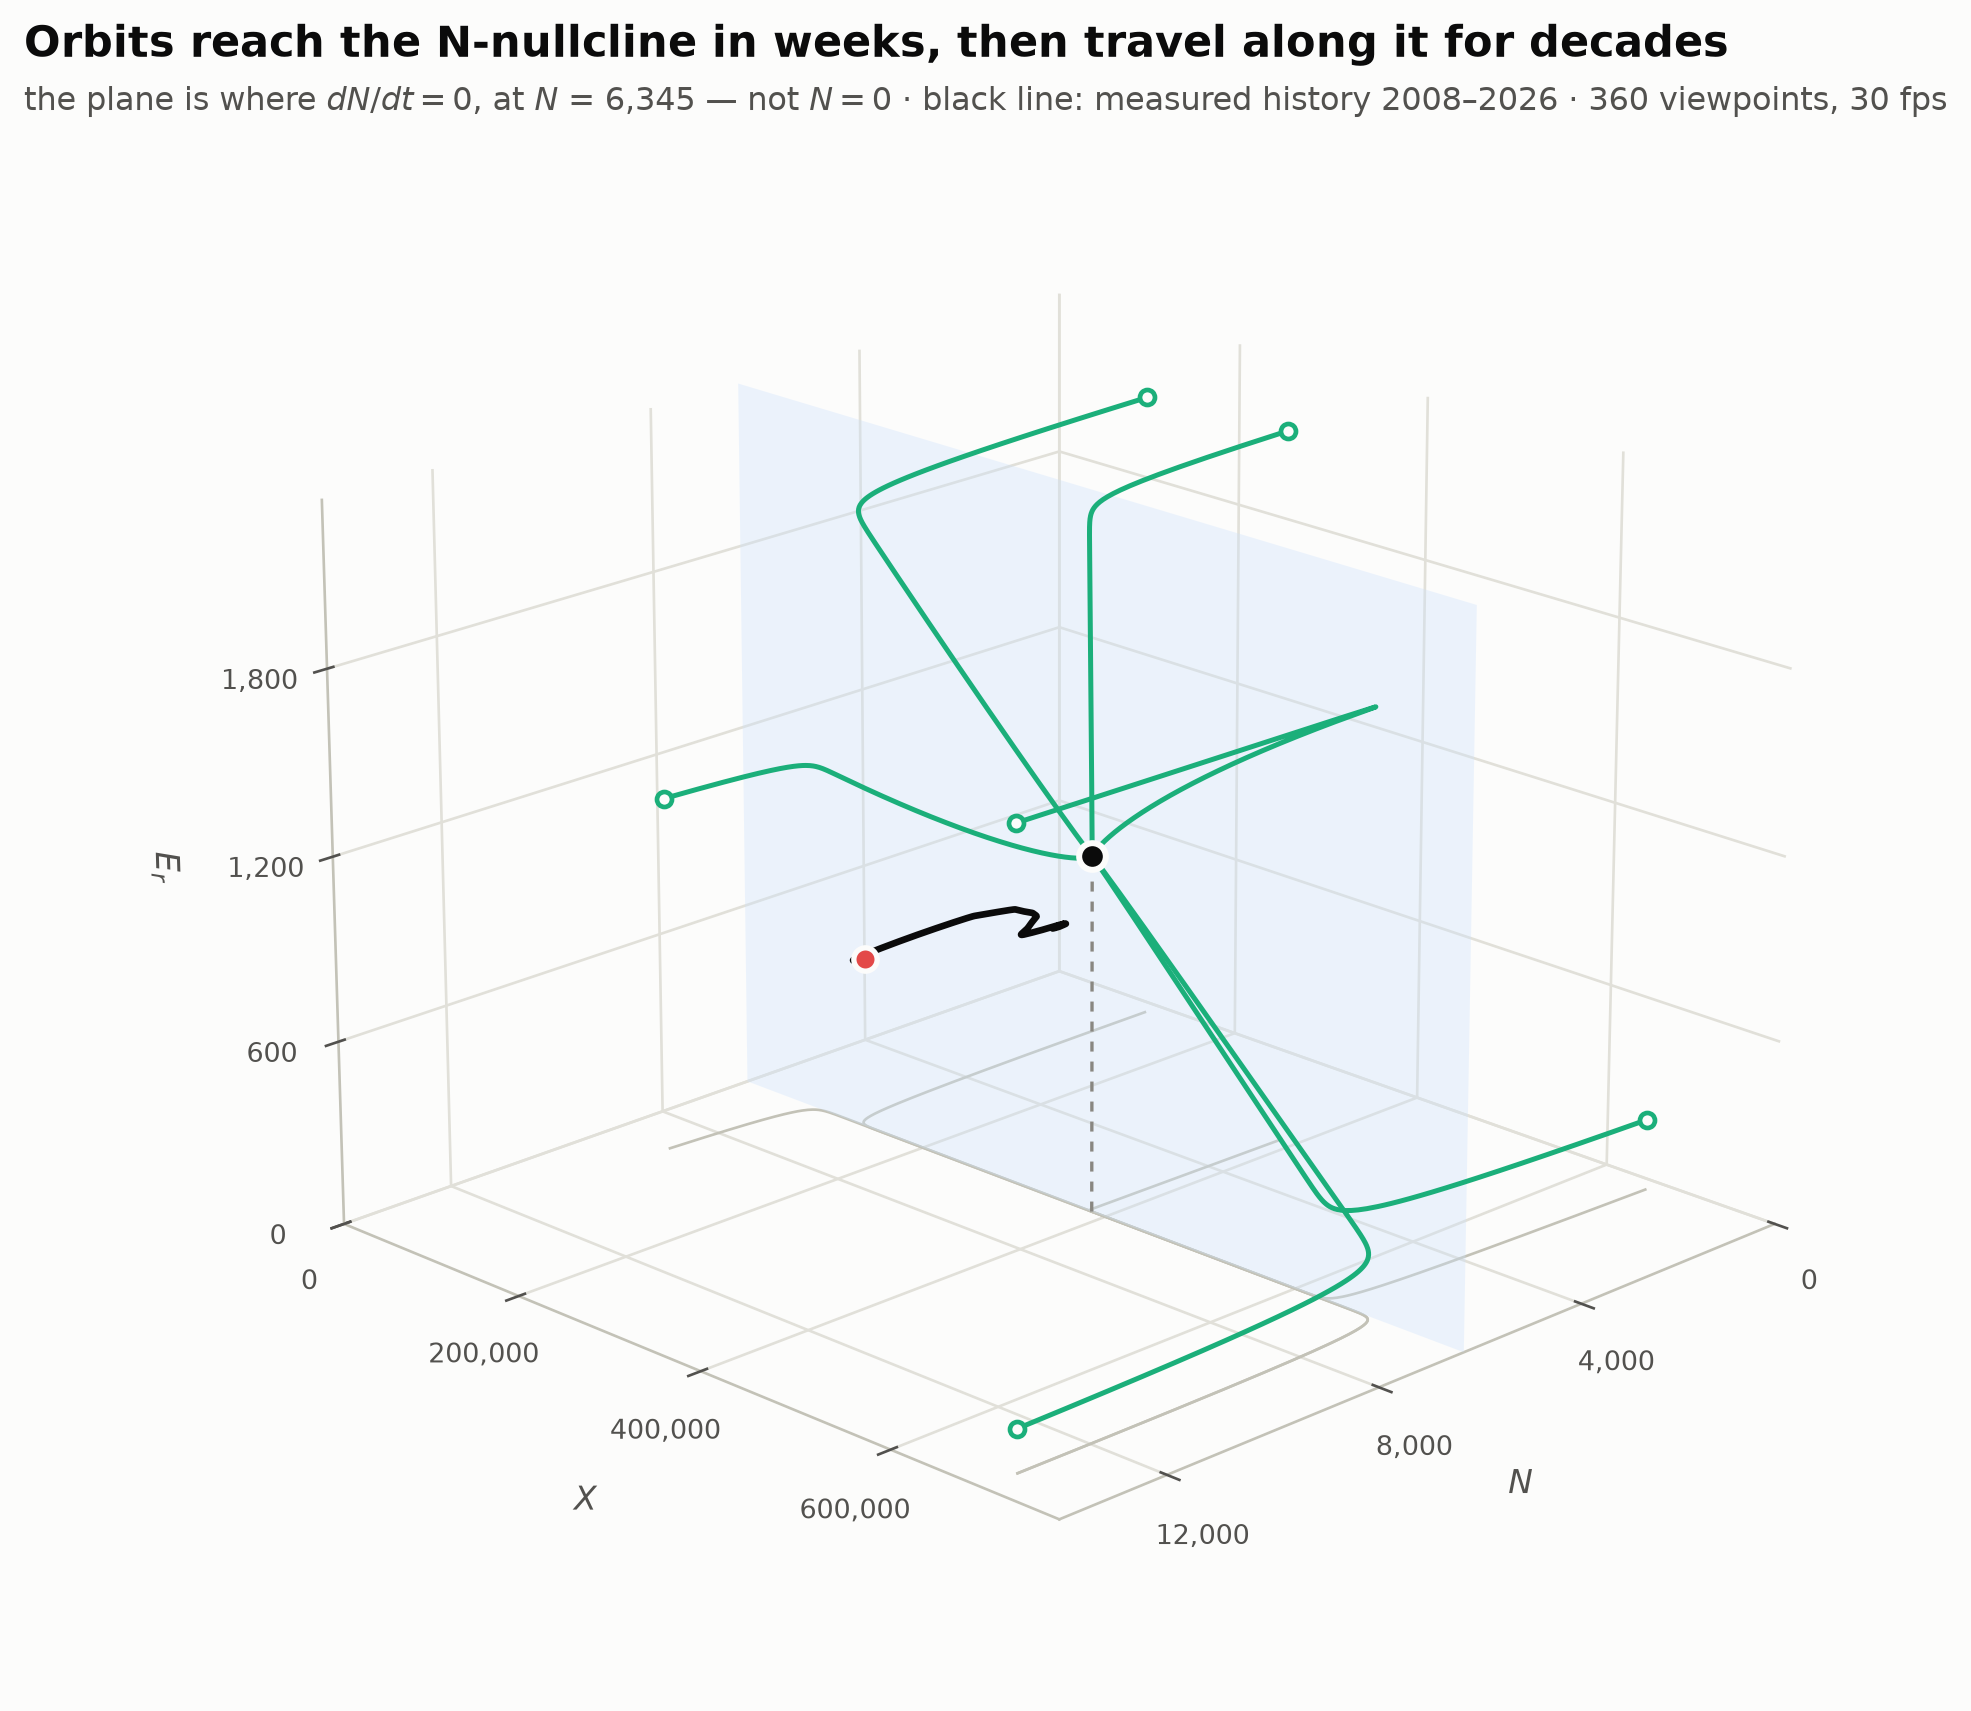

In [14]:
from matplotlib.animation import FFMpegWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from IPython.display import Video

OUT = Path("ODEtoVuln_daily_phase3d.mp4")
N_FRAMES, FPS, ELEV = 360, 30, 20
e = GLOBAL
fp = e.fixed_point()
b_h, b_n, b_x = e.hazards
N_manifold = fp["N"]          # d_d H*/(mu + conv*b_n): the manifold with H at its own
                              # fixed point, which is where the surface is flat in (N,X,Er)
BOX = {"N": 2.2 * fp["N"], "X": 2.0 * fp["X"], "Er": 2.0 * fp["Er"]}

fig3 = plt.figure(figsize=(8.8, 7.0))
ax3 = fig3.add_subplot(111, projection="3d")
gx, ge = np.meshgrid(np.linspace(0, BOX["X"], 2), np.linspace(0, BOX["Er"], 2))
ax3.plot_surface(np.full_like(gx, N_manifold), gx, ge, color=SEQ_BLUE[0], alpha=0.35,
                 linewidth=0, shade=False, zorder=1)

for fn, fx, fe in ((0.05, 0.15, 0.9), (2.1, 0.9, 0.85), (2.1, 0.9, 0.06),
                   (0.05, 0.85, 0.1), (1.4, 0.08, 0.5), (0.4, 0.5, 1.0)):
    y0 = [fp["H"], fn * fp["N"], fx * BOX["X"], fp["Ep"], fe * BOX["Er"]]
    t, tr = e.integrate(12000.0, y0=y0, n=3000)
    ax3.plot(tr["N"], tr["X"], np.zeros_like(tr["Er"]), color=BASELINE, lw=0.8, zorder=2)
    ax3.plot(tr["N"], tr["X"], tr["Er"], color=SERIES[2], lw=1.5, zorder=3)
    ax3.plot([y0[1]], [y0[2]], [y0[4]], "o", ms=4.5, mfc=SURFACE, mec=SERIES[2], mew=1.4, zorder=4)
hist = TRANSIENT[e.label]
ax3.plot(hist["traj"]["N"], hist["traj"]["X"], hist["traj"]["Er"], color=INK, lw=2.0, zorder=5)
ax3.plot([hist["state"]["N"]], [hist["state"]["X"]], [hist["state"]["Er"]], "o", ms=7,
         color=SERIES[7], mec=SURFACE, mew=1.6, zorder=6)
ax3.plot([fp["N"]], [fp["X"]], [fp["Er"]], "o", ms=8, color=INK, mec=SURFACE, mew=1.8, zorder=5)
ax3.plot([fp["N"]] * 2, [fp["X"]] * 2, [0, fp["Er"]], color=MUTED, lw=1, ls=(0, (3, 3)), zorder=4)

ax3.set_xlabel("$N$", labelpad=8)
ax3.set_ylabel("$X$", labelpad=12)
ax3.set_zlabel("$E_r$", labelpad=8)
ax3.set_xlim(0, BOX["N"])
ax3.set_ylim(0, BOX["X"])
ax3.set_zlim(0, BOX["Er"])
for axis in (ax3.xaxis, ax3.yaxis, ax3.zaxis):
    axis.set_major_locator(mpl.ticker.MaxNLocator(4))
    axis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
    axis.set_pane_color((0.988, 0.988, 0.984, 1.0))
    axis._axinfo["grid"]["color"] = GRID
ax3.tick_params(colors=SECONDARY, labelsize=8)
fig3.text(0.02, 0.975, "Orbits reach the N-nullcline in weeks, then travel along it for decades",
          ha="left", va="top", fontsize=13, fontweight="bold", color=INK)
fig3.text(0.02, 0.938, f"the plane is where $dN/dt = 0$, at $N$ = {N_manifold:,.0f} — not $N = 0$ · "
          f"black line: measured history 2008–2026 · {N_FRAMES} viewpoints, {FPS} fps",
          ha="left", va="top", fontsize=9.5, color=SECONDARY)
ax3.set_position([0.0, -0.015, 1.0, 0.95])

writer = FFMpegWriter(fps=FPS, bitrate=3200, codec="libx264",
                      metadata={"title": "ODEtoVuln daily 3-D phase portrait"})
with writer.saving(fig3, str(OUT), dpi=110):
    for az in range(N_FRAMES):
        ax3.view_init(elev=ELEV, azim=az)
        writer.grab_frame()
print(f"wrote {OUT} — {N_FRAMES} frames, {N_FRAMES / FPS:.1f} s, {OUT.stat().st_size / 1e6:.2f} MB")
print(f"plane drawn at N = {N_manifold:,.1f} (this is dN/dt = 0, not N = 0); "
      f"equilibrium N* = {fp['N']:,.1f}")
print(f"today: N {hist['state']['N']:,.0f} ({hist['state']['N'] / fp['N']:.0%} of target), "
      f"X {hist['state']['X']:,.0f} ({hist['state']['X'] / fp['X']:.0%}), "
      f"Er {hist['state']['Er']:,.1f} ({hist['state']['Er'] / fp['Er']:.0%})")

ax3.view_init(elev=ELEV, azim=45)
plt.show()
display(Video(str(OUT), width=780, html_attributes="controls loop"))